# 6. Black Litterman with Learned Confidence

In this project we will 

- clean the ETF data and understand the market instruments. 
- build a strategic benchmark and the covariance estimates needed for portfolio risk.
- introduce the Black-Litterman prior and define views.
- build the view matrix, learn confidence from realized historical payoffs, and finally convert the posterior expected returns into portfolio weights.
- repeat the same idea on sector ETFs through the library implementation.

## 1) mathematic background: Bayes Rule

Black-Litterman is easier to understand if we start with this topic. Imagine we have an initial belief about something uncertain. Then we observe new evidence. We should not throw away the initial belief completely, and we should not ignore the evidence either. We should update the belief.

That is the whole Bayesian idea. The prior is what we believed before the new information. The likelihood describes how compatible the new information is with possible states of the world. The posterior is what we believe after combining both.

$$
P(A\mid B)=\frac{P(B\mid A)P(A)}{P(B)}
$$

Here $P(A)$ is the prior belief, $P(B\mid A)$ is the likelihood of observing the evidence if $A$ were true, and $P(A\mid B)$ is the posterior belief after seeing the evidence.

Here, the uncertain object is not a class label or a coin probability. It is the vector of **expected returns**. Expected returns are hard to estimate, so we do not want to trust raw historical averages too much. We can first define a **benchmark** that gives us a conservative starting point. Then we use some **views** about the financial markets and economic situations that will have effect on expected returns. views give us new information. Then there is **confidence** for each view which decides how much the views should move us away from the benchmark.

$$
\mathrm{posterior\ belief}\propto\mathrm{prior\ belief}\times\mathrm{new\ evidence}
$$

So the process is:
- start with a reasonable neutral belief 
- listen to evidence 
- update in proportion to confidence.

Since this notebook is a portfolio optimization related topic, i highly recommend reading notebook [2. Portfolio optimization with Mean-Variance models] first for better understanding of project.


[2. Portfolio optimization with Mean-Variance models]: https://ramtin-asadi.github.io/Quantitative-Finance-Lab/notebooks/02_portfolio_optimization_MV_models.html

### Imports and pltting style

In [ ]:
from pathlib import Path
import warnings
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp

from cycler import cycler
from IPython.display import display

from quantfinlab.portfolio import (
    prices_to_returns, make_rebalance_dates,
    estimate_covariance, make_psd, equal_weight)

from quantfinlab.portfolio.walkforward import run_walkforward_grid
from quantfinlab.risk import (
    corr_matrix, rolling_volatility,
    drawdown_summary_table,
    stress_table, var_es_table,
    var_backtest_table, best_var_methods, rolling_var)

from quantfinlab.plotting import (
    plot_corr_heatmap, plot_strategy_nav,
    plot_strategy_drawdowns, plot_stress_bar)

from quantfinlab.backtest.portfolio import run_many_weights_backtests

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)

colors = ["#069AF3", "#FE420F", "#00008B", "#008080", "#CC79A7",
          "#DC143C", "#9614fa", "#0072B2", "#7BC8F6", "#04D8B2", "#800080", "#FF8072"]
if cycler is not None:
    plt.rcParams["axes.prop_cycle"] = cycler(color=colors)
plt.rcParams.update({
    "figure.figsize": (7, 3.5),
    "figure.dpi": 140,
    "savefig.dpi": 250,
    "axes.grid": True,
    "grid.alpha": 0.20,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 8})


## 2) Data

For this project, we could've used the same nasdaq data from notebook 2, but that wouldn't be the best choice for Black-Litterman and the economic interpretation and building views wouldn't be as good. So we use a dataset of famous ETFs (investement funds that are tradable like exchanges) which is collected from yahoo-finance API. A script for reproducing the dataset will be available soon. The dataset contains history of these ETFs from the start of 2010, but we use the data from the start of 2013 cause we don't want to deal with missing prices of one of the ETFs.


In [ ]:
data_path = Path("../data/ETF_data.csv")
if not data_path.exists():
    data_path = Path("data/ETF_data.csv")
raw = pd.read_csv(data_path)
raw["date"] = pd.to_datetime(raw["date"], errors="coerce")
raw = raw.dropna(subset=["date"]).sort_values("date")
raw = raw.drop_duplicates(subset=["date"], keep="last")
raw = raw.set_index("date")

close_cols = [col for col in raw.columns if str(col).endswith("__close")]
volume_cols = [col for col in raw.columns if str(col).endswith("__volume")]
dividend_cols = [col for col in raw.columns if str(col).endswith("__dividends")]
split_cols = [col for col in raw.columns if str(col).endswith("__stock_splits")]

close_all = raw[close_cols].copy()
close_all.columns = [col.rsplit("__", 1)[0] for col in close_cols]
close_all = close_all.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
close_all = close_all.dropna(axis=1, how="all").reindex(columns=sorted(close_all.columns))

volume_all = raw[volume_cols].copy()
volume_all.columns = [col.rsplit("__", 1)[0] for col in volume_cols]
volume_all = volume_all.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
volume_all = volume_all.dropna(axis=1, how="all").reindex(columns=sorted(volume_all.columns))

dividends_all = raw[dividend_cols].copy()
dividends_all.columns = [col.rsplit("__", 1)[0] for col in dividend_cols]
dividends_all = dividends_all.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
dividends_all = dividends_all.reindex(columns=sorted(dividends_all.columns))

splits_all = raw[split_cols].copy()
splits_all.columns = [col.rsplit("__", 1)[0] for col in split_cols]
splits_all = splits_all.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
splits_all = splits_all.reindex(columns=sorted(splits_all.columns))

action_parts = []
if not dividends_all.empty:
    dividends_part = dividends_all.copy()
    dividends_part.columns = pd.MultiIndex.from_product([dividends_part.columns, ["dividends"]])
    action_parts.append(dividends_part)
if not splits_all.empty:
    splits_part = splits_all.copy()
    splits_part.columns = pd.MultiIndex.from_product([splits_part.columns, ["stock_splits"]])
    action_parts.append(splits_part)
actions_all = pd.concat(action_parts, axis=1).sort_index(axis=1) if action_parts else pd.DataFrame(index=raw.index)

print("close panel:", close_all.shape, close_all.index.min().date(), "to", close_all.index.max().date())
print("volume panel:", volume_all.shape)


data file: ..\data\ETF_data.csv
close panel: (4107, 56) 2010-01-04 to 2026-05-01
auto_adjust=True in the data script, so close is the adjusted price input used below
volume panel: (4107, 56)


The loaded data has $4107$ trading days and $56$ adjusted close columns before we select the project's ETFs. We are not going to use all $56$ ETFs and most of them are for later projects and secondary data for this project like sector ETFs.

### 2.1 Choosing the ETFs

We now choose the ETFs we are going to analyze for this notebook. The tradable assets are:

| Ticker | Role | What it represents |
|---|---|---|
| SPY | U.S. equity core | Large-cap US equities, commonly used as the broad US stock-market proxy. |
| QQQ | U.S. growth leadership | Nasdaq-100 exposure, usually more growth and technology heavy than SPY. |
| IWM | U.S. small caps | Russell 2000 small-cap US equities, more cyclical and domestically sensitive. |
| EFA | Developed international equity | Developed international equities outside North America. |
| EEM | Emerging markets equity | Higher-risk Emerging-market equities, usually more sensitive to global growth, dollar strength, and commodity cycles. |
| TLT | Long duration Treasuries | Long-duration US Treasuries, very sensitive to changes in long-term interest rates. |
| IEF | Intermediate Treasuries | Intermediate Treasury exposure, less duration risk than TLT. |
| SHY | Short Treasuries | Short-duration Treasury exposure and a defensive cash-like sleeve. Usually low volatility and low return. |
| AGG | Core bonds | Broad US aggregate bond exposure, a core bond allocation. |
| LQD | Investment-grade credit | corporate bonds, combining rate exposure and credit exposure. |
| HYG | High-yield credit | High-yield corporate bonds, more equity like and more sensitive to credit conditions. |
| GLD | Gold | Gold exposure, often treated as a real asset or crisis/inflation hedge. |
| VNQ | Real estate | US real estate investment trusts, rate-sensitive and equity-sensitive. |
| DBC | Commodities | Broad commodities futures exposure, often connected to inflation and global real activity. |
| UUP | Dollar signal only | US dollar exposure, used as an information variable rather than a tradable portfolio asset here. |

### 2.2 behaviour of these ETFs

**SPY, QQQ, and IWM** are all **equity** ETFs, but they do not behave the same. SPY is the broad large cap core. QQQ is more growth and technology heavy, so it usually benefits when investors reward long duration growth cash flows, innovations, and cap leadership. IWM is small cap exposure, so it tends to be more sensitive to growth and financing conditions

**EFA and EEM** give **international** exposure. EFA is developed market equity, while EEM is emerging market equity. Emerging markets are often more sensitive to dollar strength, global liquidity and commodity cycles. That is why UUP is useful as a signal asset. If the dollar is strengthening aggressively, emerging markets can face pressure even if they look attractive based on their local currency.

The **bond** ETFs: **SHY** is short Treasury exposure, **IEF** is intermediate Treasury exposure, and **TLT** is long Treasury exposure. As we can remembe from the notebook 1 and fixed income risk measures implementation, The longer the duration, the more sensitive the ETF is to interest rate changes. If rates rise sharply, long duration bonds can suffer large falls in their value. If rates fall during a growth scare, duration can help stabilize the portfolio.

**Credit** ETFs sit between bonds and equities. **LQD** is investment grade credit, while **HYG** is high yield credit. HYG is especially important because it can behave like a risky asset. In calm markets, high yield can earn carry. In stress markets, it can sell off with equities because credit spreads widen.

**GLD, VNQ, and DBC** have real asset and inflation sensitive exposures. **Gold** can behave as a diversifier when confidence in financial assets weakens and the situation is uncertain, although it is not a perfect hedge. **VNQ** is real estate and is sensitive to both growth and rates. **DBC** is broad commodities and can perform well during inflationary commodity cycles, but it can also be very painful in long disinflationary periods.

This financial interpretation matters because the later views are not arbitrary and we use these relations to build economically reasonable views.


In [ ]:
start_date = "2013-01-01"

assets = [
    "SPY", "QQQ", "IWM", "EFA", "EEM", 
    "TLT", "IEF", "SHY",
    "AGG", "LQD", "HYG",
    "GLD", "VNQ", "DBC"]
signal_only_assets = ["UUP"] if "UUP" in close_all.columns else []

sleeve_map = {
    "SPY": "US equity", "QQQ": "US equity", "IWM": "US equity",
    "EFA": "International equity", "EEM": "International equity",
    "TLT": "Duration bonds", "IEF": "Duration bonds", "SHY": "Short bonds",
    "AGG": "Core bonds", "LQD": "Credit", "HYG": "Credit",
    "GLD": "Real assets", "VNQ": "Real assets", "DBC": "Commodities",
    "UUP": "Dollar"}


def missing_after_first_valid(series):
    first = series.first_valid_index()
    if first is None:
        return np.nan
    return float(series.loc[first:].isna().mean())


close_after_start = close_all.loc[pd.Timestamp(start_date):].copy()
missing_assets = [ticker for ticker in assets if ticker not in close_after_start.columns]
if missing_assets:
    raise ValueError(f"missing required tradable adjusted close columns: {missing_assets}")

filter_rows = []
for ticker in assets + signal_only_assets:
    px = close_after_start[ticker]
    valid = px.dropna()
    filter_rows.append({
        "ticker": ticker, "observations": len(valid),
        "first_date": valid.index.min() if len(valid) else pd.NaT,
        "last_date": valid.index.max() if len(valid) else pd.NaT,
        "missing_pct_after_first_valid": missing_after_first_valid(px),
        "tradable": ticker in assets,
    })
display(pd.DataFrame(filter_rows).round(4))

first_all_valid = close_after_start[assets].dropna(how="any").index.min()
if pd.isna(first_all_valid):
    raise ValueError("no date where all tradable ETF close columns are available")

close = close_after_start.loc[first_all_valid:, assets].ffill(limit=3).dropna(how="any")
returns = prices_to_returns(close, kind="simple").replace([np.inf, -np.inf], np.nan).dropna(how="all")
remaining_return_gaps = int(returns.isna().sum().sum())
if remaining_return_gaps:
    print(f"filling {remaining_return_gaps} isolated post-inception return gaps with 0.0 after adjusted-price cleaning")
returns = returns.fillna(0.0)
close = close.reindex(returns.index).ffill(limit=3)

signal_tickers = list(dict.fromkeys(assets + signal_only_assets))
signal_close = close_after_start.loc[first_all_valid:, signal_tickers].ffill(limit=3).reindex(returns.index).ffill(limit=3)
signal_returns = signal_close.pct_change(fill_method=None).replace([np.inf, -np.inf], np.nan).reindex(returns.index).fillna(0.0)

print("assets:", assets)
print("signal assets:", list(signal_returns.columns))
print("return panel:", returns.shape, returns.index.min().date(), "to", returns.index.max().date())


,ticker,observations,first_date,last_date,missing_pct_after_first_valid,tradable
0,SPY,3353,2013-01-02,2026-05-01,0.0,True
1,QQQ,3353,2013-01-02,2026-05-01,0.0,True
2,IWM,3353,2013-01-02,2026-05-01,0.0,True
3,EFA,3353,2013-01-02,2026-05-01,0.0,True
4,EEM,3353,2013-01-02,2026-05-01,0.0,True
5,TLT,3353,2013-01-02,2026-05-01,0.0,True
6,IEF,3353,2013-01-02,2026-05-01,0.0,True
7,SHY,3353,2013-01-02,2026-05-01,0.0,True
8,AGG,3353,2013-01-02,2026-05-01,0.0,True
9,LQD,3353,2013-01-02,2026-05-01,0.0,True


assets: ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM', 'TLT', 'IEF', 'SHY', 'AGG', 'LQD', 'HYG', 'GLD', 'VNQ', 'DBC']
signal assets: ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM', 'TLT', 'IEF', 'SHY', 'AGG', 'LQD', 'HYG', 'GLD', 'VNQ', 'DBC', 'UUP']
return panel: (3352, 14) 2013-01-03 to 2026-05-01


In [5]:
rebal_freq = "ME"
cov_lookback = 756
mu_lookback = 252

rebalance_dates = make_rebalance_dates(returns.index, freq=rebal_freq, min_history_days=max(cov_lookback, mu_lookback, 756))
print("rebalance dates:", len(rebalance_dates))
print("first:", rebalance_dates[0].date(), "last:", rebalance_dates[-1].date())


rebalance dates: 125
first: 2016-01-29 last: 2026-05-01


We made monthly rebalance dates and we can see that even though our data starts from 2013, we need a lookback window for estimating covariance and mean, so the first rebalance date happens at the first month of 2016. 

In [ ]:
annualization = 252

rows = []
for ticker in assets:
    px = close[ticker].dropna()
    ret = returns[ticker].dropna()
    years = max(len(ret) / annualization, 1e-9)
    nav = (1.0 + ret).cumprod()
    rows.append({
        "ticker": ticker,
        "sleeve": sleeve_map.get(ticker, "Other"),
        "first_date": px.index.min(),
        "last_date": px.index.max(),
        "observations": int(px.shape[0]),
        "ann_return": float(nav.iloc[-1] ** (1.0 / years) - 1.0) if len(nav) else np.nan,
        "ann_vol": float(ret.std() * math.sqrt(annualization)) if len(ret) else np.nan,
        "max_drawdown": float((nav / nav.cummax() - 1.0).min())})
    
table = pd.DataFrame(rows).sort_values("ticker")
display(table.round({"ann_return": 4, "ann_vol": 4, "max_drawdown": 4}))


,ticker,sleeve,first_date,last_date,observations,ann_return,ann_vol,max_drawdown
8,AGG,Core bonds,2013-01-03,2026-05-01,3352,0.0178,0.0496,-0.1843
13,DBC,Commodities,2013-01-03,2026-05-01,3352,0.0203,0.1702,-0.6220
4,EEM,International equity,2013-01-03,2026-05-01,3352,0.0492,0.2015,-0.3982
3,EFA,International equity,2013-01-03,2026-05-01,3352,0.0746,0.1670,-0.3419
11,GLD,Real assets,2013-01-03,2026-05-01,3352,0.0743,0.1630,-0.3860
10,HYG,Credit,2013-01-03,2026-05-01,3352,0.0414,0.0790,-0.2203
6,IEF,Duration bonds,2013-01-03,2026-05-01,3352,0.0120,0.0645,-0.2408
2,IWM,US equity,2013-01-03,2026-05-01,3352,0.1061,0.2154,-0.4113
9,LQD,Credit,2013-01-03,2026-05-01,3352,0.0256,0.0798,-0.2510
1,QQQ,US equity,2013-01-03,2026-05-01,3352,0.1992,0.2078,-0.3512


### 2.3 Performance of ETFs

As we can see, **QQQ** has been the strongest asset in the sample, with an annualized return close to 20% and volatility around 21%. **SPY** also performs strongly, with lower return and lower volatility than QQQ. **IWM** has a positive return but much higher drawdown, which is typical of small cap exposure especially in our sample where large cap growth leadership has been very strong.

The international equity ETFs are weaker. **EFA and EEM** both have large drawdowns and volatility, but their returns are much lower than U.S. equities. This already tells us that a simple global equity diversification story is not enough. International exposure may still be useful, but an efficient model should not blindly assume that all equities and markets deserve the same allocation.

The bond ETFs show very different behavior. **SHY** has very low volatility around $1.4\%$ and a much smaller drawdown around $-5.7\%$, but the return is also low. **TLT** is the opposite of what someone might expect from “bonds”. It has a very large drawdown around $-48.5\%$ in this sample because as we said earlier, long duration bonds are sensitive to interest rate changes. TLT fell hard by the post-2021 rate shock.

**DBC** has a very large drawdown around $-62.2\%$, which can be from the long weak cycles. **GLD and VNQ** sit somewhere between diversifiers and risk assets. They have meaningful volatility and large drawdowns, but they also bring different economic exposure.

An efficient active model like Black-Litterman should know when to lean into growth, when to prefer real assets, when to reduce long duration, and when to stay close to the benchmark so it can control risk and gain the high return based on the state and information given to it each time it's rabalancing.



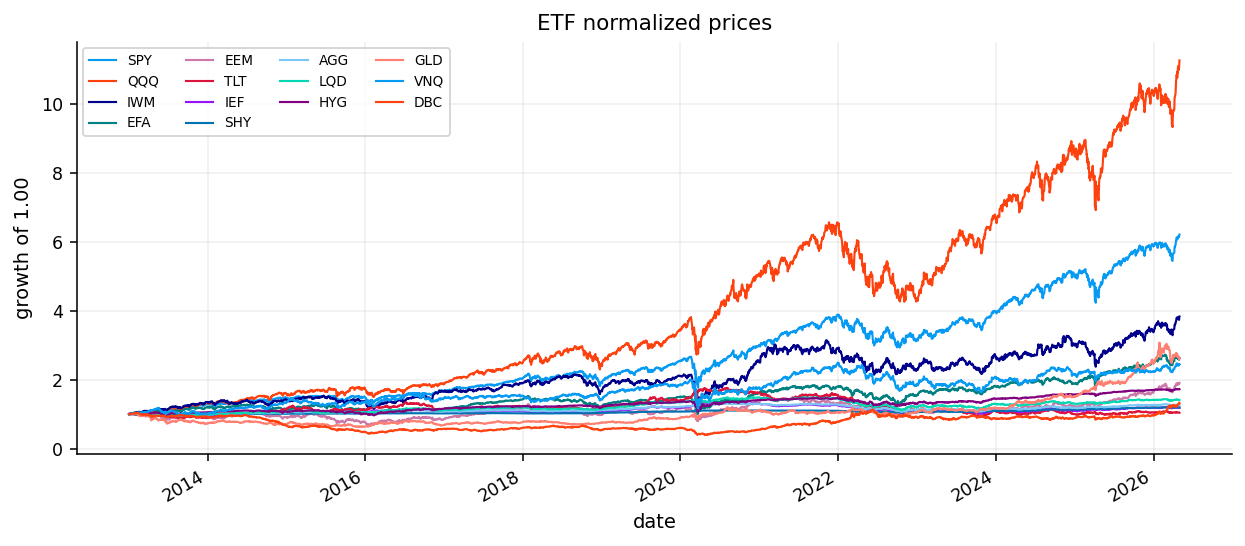

In [7]:
normalized_prices = close / close.ffill().bfill().iloc[0]
ax = normalized_prices.plot(figsize=(9, 4), lw=1.1)
ax.set_title("ETF normalized prices")
ax.set_ylabel("growth of 1.00")
ax.set_xlabel("date")
ax.legend(ncol=4, fontsize=7)
plt.tight_layout()
plt.show()


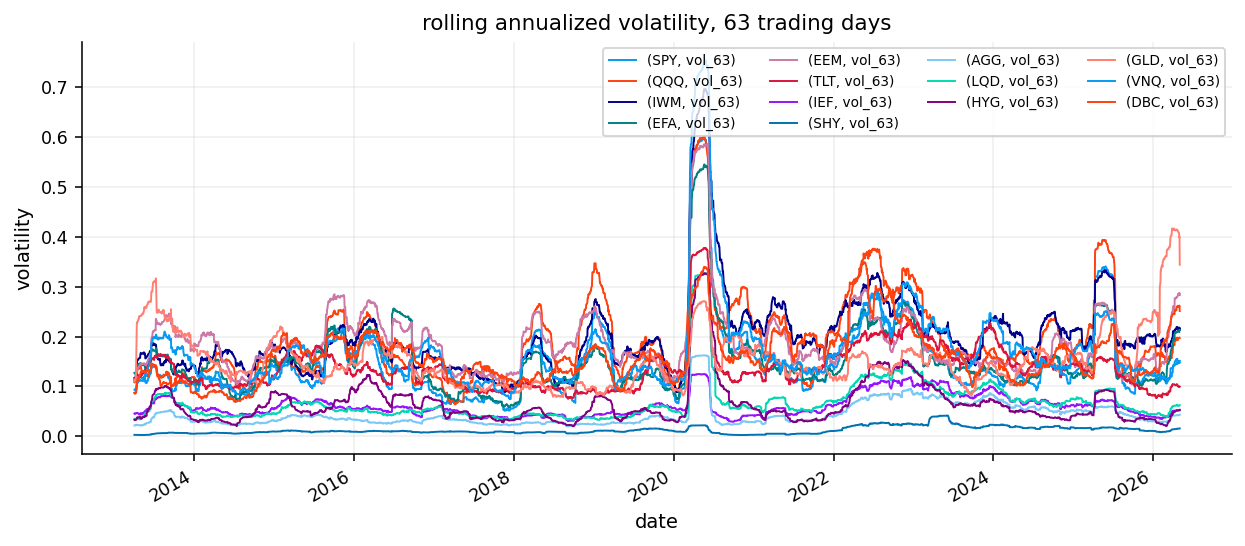

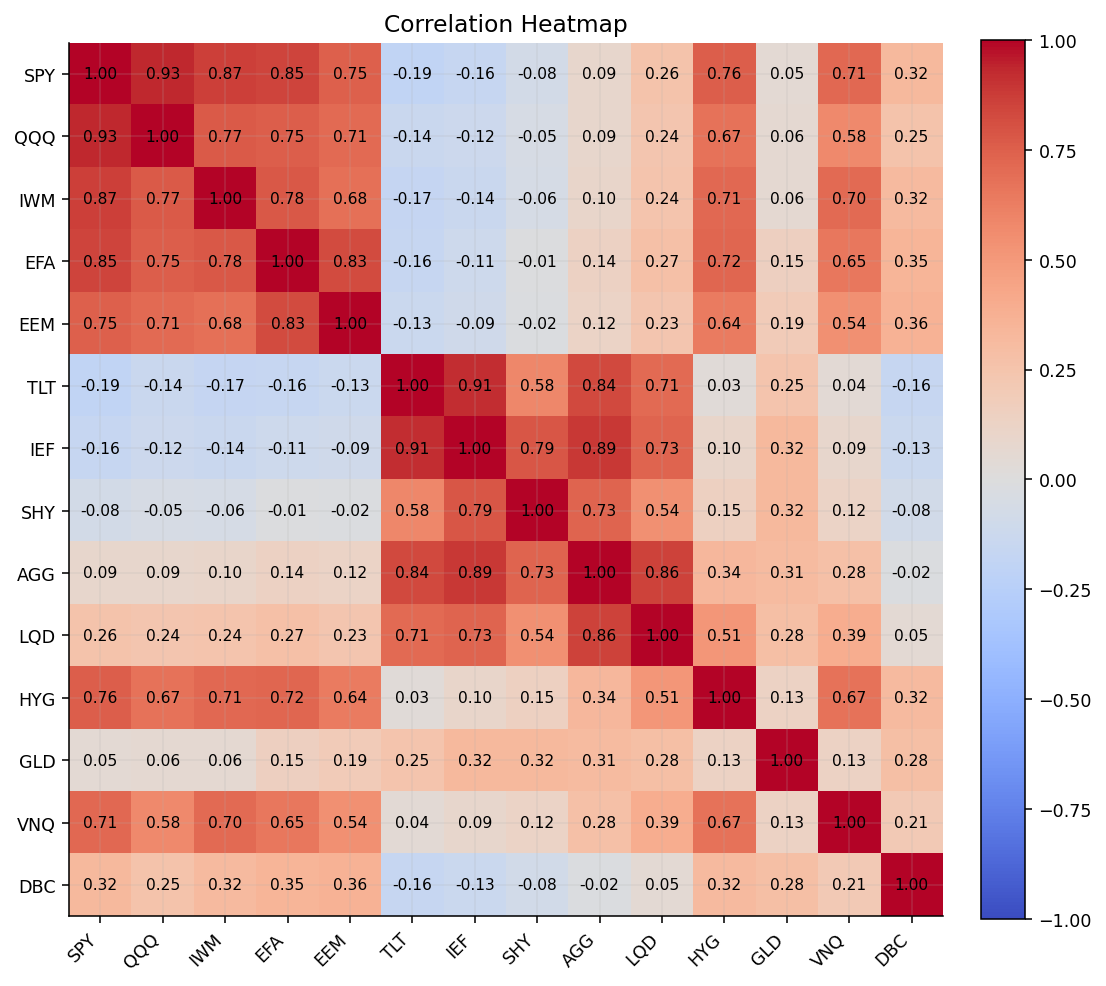

In [8]:
rolling_vol = rolling_volatility(returns, windows=(63,), annualization=annualization)
ax = rolling_vol.plot(figsize=(9, 4), lw=1.0)
ax.set_title("rolling annualized volatility, 63 trading days")
ax.set_ylabel("volatility")
ax.set_xlabel("date")
ax.legend(ncol=4, fontsize=7, loc="best")
plt.tight_layout()
plt.show()

corr = corr_matrix(returns)
fig, ax = plt.subplots(figsize=(8, 8))
ax = plot_corr_heatmap(ax, corr)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.show()


As we can see, volatility jumps during crisis periods, especially around the COVID shock. Equity and real asset ETFs show much larger volatility spikes than short duration bonds. SHY remains the lowest volatility instrument throughout the sample.

U.S. equity ETFs are highly correlated with each other. SPY and QQQ move very closely, and IWM also has strong equity market correlation. Developed and emerging market equity ETFs also connect strongly to the US equity. This means that simply owning SPY, QQQ, IWM, EFA, and EEM is not as diversified as the number of tickers suggests.

The bond holding ETFs are different. TLT, IEF, SHY, AGG, and LQD have their own internal structure. TLT and IEF are strongly related because both are Treasury duration exposures. TLT has negative correlation with SPY around $-0.19$, which shows why long Treasuries historically helped in some equity selloffs. But the correlation is not fixed forever. In inflation shocks, stocks and bonds can fall together.

AGG and LQD are also connected to the broader bond and credit market. HYG behaves more like risky credit and often correlates more with equities than with pure Treasuries.

Gold and commodities contain a different kind of exposure. GLD has weaker relationships with most assets, which can make it a good diversifier. DBC has a different inflation and commodity cycle profile, so it can help when inflation sensitive assets are leading, but it can also be very difficult to hold during long weak commodity regimes.

If the optimizer only sees a covariance matrix and expected returns, it may concentrate in a few assets. The human portfolio manager might add economic sanity to the model instead of just relying on estimation. This is why Black-Litterman can be great for combining economic ideas and views into a portfolio optimization model.

## 3) Building the strategic benchmark and Prior

If we remember the bayes rule from earlier, we want to update our belief when new information arrives. We first need an intial belief or a starting point that is going to change with with the new information.

### 3.1 Benchmark portfolio

We First define a neutral portfolio. This is not supposed to be the smartest portfolio in the notebook. It is the anchor. In Black-Litterman, the benchmark exists because it represents the **starting belief about how capital should be allocated** before any active views are added.

The benchmark we use is a portfolio with pre-defined fixed weights and the weights are based on what we think can be reasonable for these ETFs based on their performance, behaviour and what they hold. It gives meaningful weight to US equities, international equities, bonds, credit, gold, real estate, and commodities. It is also constrained by asset caps and constraints. These caps protect the optimization from unrealistic concentration.

For example, even if QQQ has a strong historical return, we probably do not want a mult asset benchmark to become almost entirely QQQ. Likewise, even if short Treasuries have low volatility, a diversified benchmark should not become a pure cash substitute.

We don't want the optimizer to do whatever it wants. We want it to stay inside a realistic multi asset allocation structure. That's why we use bounds and caps for weights on each asset.

Since we already know from notebook 2, A benchmark weight vector looks like this:

$$
w_b=\begin{bmatrix}w_{b,\mathrm{SPY}} & w_{b,\mathrm{QQQ}} & \cdots & w_{b,\mathrm{DBC}}\end{bmatrix}^{\top}
$$

with the full investment condition

$$
\sum_{i=1}^{N}w_{b,i}=1
$$

And the benchmark is long-only, so all weights are nonnegative:

$$
w_{b,i}\geq 0
$$


In [ ]:
w_min = 0.0
w_max = 0.40

fixed_benchmark_weights = {
    "SPY": 0.22, "QQQ": 0.08, "IWM": 0.04, "EFA": 0.09, "EEM": 0.05,
    "TLT": 0.08, "IEF": 0.08, "SHY": 0.05, "AGG": 0.10, "LQD": 0.05,
    "HYG": 0.04, "GLD": 0.05, "VNQ": 0.04, "DBC": 0.02}

asset_cap_map = {
    "SPY": 0.35, "QQQ": 0.25, "IWM": 0.15, "EFA": 0.20, "EEM": 0.15,
    "TLT": 0.25, "IEF": 0.25, "SHY": 0.20, "AGG": 0.25,
    "LQD": 0.15, "HYG": 0.08, "GLD": 0.10, "VNQ": 0.08, "DBC": 0.05}

asset_caps = pd.Series({asset: asset_cap_map.get(asset, w_max) for asset in assets}, index=assets, dtype=float)

sleeve_constraints = {
    "equity": {"assets": ["SPY", "QQQ", "IWM", "EFA", "EEM"], "min": 0.35, "max": 0.75},
    "bonds": {"assets": ["TLT", "IEF", "SHY", "AGG"], "min": 0.15, "max": 0.55},
    "credit": {"assets": ["LQD", "HYG"], "min": 0.00, "max": 0.18},
    "real_assets": {"assets": ["GLD", "VNQ", "DBC"], "min": 0.00, "max": 0.22}}


def normalize_box_weights(raw_weights, index, lower=0.0, upper=0.25):
    w = pd.Series(raw_weights, index=index, dtype=float).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    upper_s = pd.Series(upper, index=index, dtype=float) if np.isscalar(upper) else pd.Series(upper, index=index, dtype=float).reindex(index).fillna(w_max)
    w = w.clip(lower=max(lower, 0.0), upper=upper_s)
    if w.sum() <= 0:
        w = pd.Series(1.0 / len(index), index=index).clip(upper=upper_s)
    else:
        w = w / w.sum()
    if upper_s.sum() < 1.0 - 1e-10:
        return pd.Series(1.0 / len(index), index=index)
    for _ in range(100):
        over = w > upper_s + 1e-12
        if not over.any():
            break
        excess = float((w[over] - upper_s[over]).sum())
        w[over] = upper_s[over]
        room = (upper_s[~over] - w[~over]).clip(lower=0.0)
        if room.sum() <= 1e-12:
            break
        w.loc[room.index] = w.loc[room.index] + excess * room / room.sum()
    w = w.clip(lower=lower, upper=upper_s)
    w = w / w.sum() if w.sum() > 0 else pd.Series(1.0 / len(index), index=index)
    return w


benchmark_raw = {ticker: fixed_benchmark_weights.get(ticker, 0.0) for ticker in assets}
benchmark_w = normalize_box_weights(benchmark_raw, assets, lower=w_min, upper=asset_caps)
if (benchmark_w > asset_caps + 1e-6).any() or abs(benchmark_w.sum() - 1.0) > 1e-6:
    benchmark_w = normalize_box_weights(pd.Series(1.0, index=assets), assets, lower=w_min, upper=asset_caps)
benchmark_table = pd.DataFrame({
    "asset": benchmark_w.index,
    "sleeve": [sleeve_map.get(ticker, "Other") for ticker in benchmark_w.index],
    "benchmark_weight": benchmark_w.values,
    "asset_cap": asset_caps.reindex(benchmark_w.index).values,
})
display(benchmark_table.round(4))


,asset,sleeve,benchmark_weight,asset_cap
0,SPY,US equity,0.2222,0.35
1,QQQ,US equity,0.0808,0.25
2,IWM,US equity,0.0404,0.15
3,EFA,International equity,0.0909,0.20
4,EEM,International equity,0.0505,0.15
5,TLT,Duration bonds,0.0808,0.25
6,IEF,Duration bonds,0.0808,0.25
7,SHY,Short bonds,0.0505,0.20
8,AGG,Core bonds,0.1010,0.25
9,LQD,Credit,0.0505,0.15


### What weights we used and why

As we can see, we set SPY as the largest position at about **$22.2\%$**, followed by AGG around **$10.1\%$**, EFA around **$9.1\%$**, and several exposures around **$8.1\%$** or **$5.1\%$**. Large weights go to liquid core exposures. SPY for broad US equity, AGG for core bonds, EFA for developed international equities, and intermediate/long Treasuries for duration. Smaller weights go to more specialized or volatile exposures such as DBC, VNQ, HYG, and IWM. This makes sense because those assets can be useful, but we usually do not want them to dominate the portfolio.

US equity is the largest section at about 34.3%. Duration bonds and international equities are also meaningful. Core bonds, real assets, and credit each have visible allocations, while commodities are intentionally small.

This looks like a reasonable strategic benchmark for a multi asset project. It is growth oriented enough to participate in equity markets, but it is not a pure equity portfolio. It has bonds, gold, real estate, credit, and commodities. That makes it a useful anchor for active allocation.

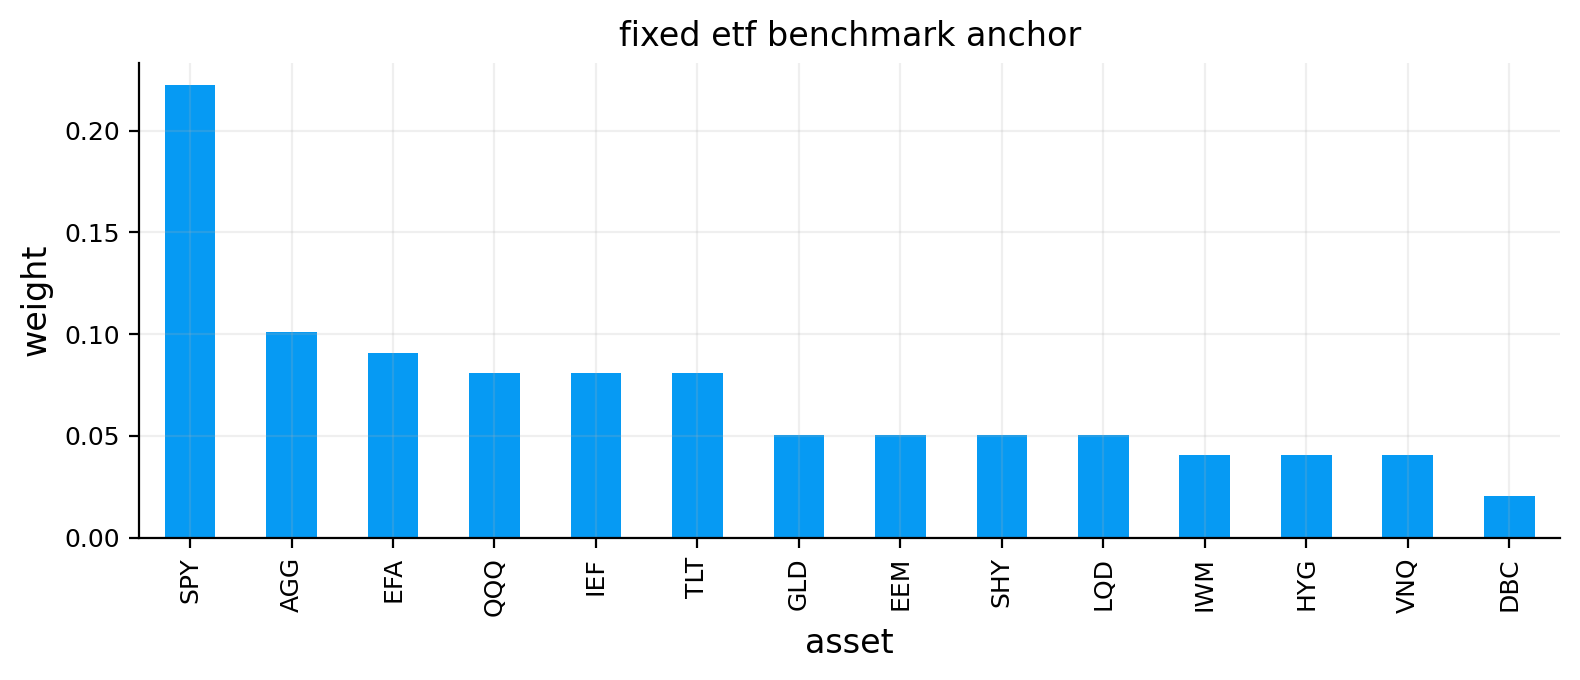

,sleeve,benchmark_weight
7,US equity,0.3434
3,Duration bonds,0.1616
4,International equity,0.1414
1,Core bonds,0.1010
5,Real assets,0.0909
2,Credit,0.0909
6,Short bonds,0.0505
0,Commodities,0.0202


In [10]:
fig, ax = plt.subplots(figsize=(8, 3.5))
benchmark_w.sort_values(ascending=False).plot(kind="bar", ax=ax)
ax.set_title("fixed etf benchmark anchor")
ax.set_ylabel("weight")
ax.set_xlabel("asset")
plt.tight_layout()
plt.show()
benchmark_sleeve = benchmark_table.groupby("sleeve", as_index=False)["benchmark_weight"].sum().sort_values("benchmark_weight", ascending=False)
display(benchmark_sleeve.round(4))


In [11]:
ewma_lambda = 0.97
delta_fallback = 2.5
delta_min = 0.50
delta_max = 8.00
risk_free_daily = (1.0 + 0.04) ** (1.0 / 252.0) - 1.0


def local_make_psd(matrix, eps=1e-10):
    arr = np.asarray(matrix, dtype=float)
    arr = 0.5 * (arr + arr.T)
    vals, vecs = np.linalg.eigh(arr)
    vals = np.maximum(vals, eps)
    out = (vecs * vals) @ vecs.T
    return 0.5 * (out + out.T)


def make_psd_df(matrix, index):
    arr = make_psd(np.asarray(matrix, dtype=float), eps=1e-10)
    return pd.DataFrame(arr, index=index, columns=index)


def estimate_ewma_cov_at_date(returns, date, lookback=cov_lookback, lam=ewma_lambda):
    date = pd.Timestamp(date)
    pos = returns.index.searchsorted(date, side="right") - 1
    window = returns.iloc[max(0, pos - lookback + 1):pos + 1].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    cov_ann = estimate_covariance(window, method="EWMA", annualization=annualization, ewma_lambda=lam, return_df=True)
    return cov_ann


def estimate_delta_at_date(returns, date, benchmark_w, lookback=cov_lookback):
    date = pd.Timestamp(date)
    pos = returns.index.searchsorted(date, side="right") - 1
    window = returns.iloc[max(0, pos - lookback + 1):pos + 1][benchmark_w.index].fillna(0.0)
    bench_ret = window @ benchmark_w
    ann_return = float(bench_ret.mean() * annualization)
    ann_var = float(bench_ret.var(ddof=1) * annualization)
    raw_delta = delta_fallback if (not np.isfinite(ann_var) or ann_var <= 1e-10) else (ann_return - risk_free_daily * annualization) / ann_var
    if not np.isfinite(raw_delta):
        raw_delta = delta_fallback
    return float(np.clip(raw_delta, delta_min, delta_max))


cov_by_date = {}
delta_by_date = {}
prior_mu_by_date = {}
for dt in rebalance_dates:
    cov_ann = estimate_ewma_cov_at_date(returns, dt)
    delta_t = estimate_delta_at_date(returns, dt, benchmark_w)
    prior_mu = pd.Series(delta_t * cov_ann.loc[assets, assets].values @ benchmark_w.loc[assets].values, index=assets)
    cov_by_date[pd.Timestamp(dt)] = cov_ann
    delta_by_date[pd.Timestamp(dt)] = delta_t
    prior_mu_by_date[pd.Timestamp(dt)] = prior_mu
print("stored covariance and prior for", len(prior_mu_by_date), "rebalance dates")


stored covariance and prior for 125 rebalance dates


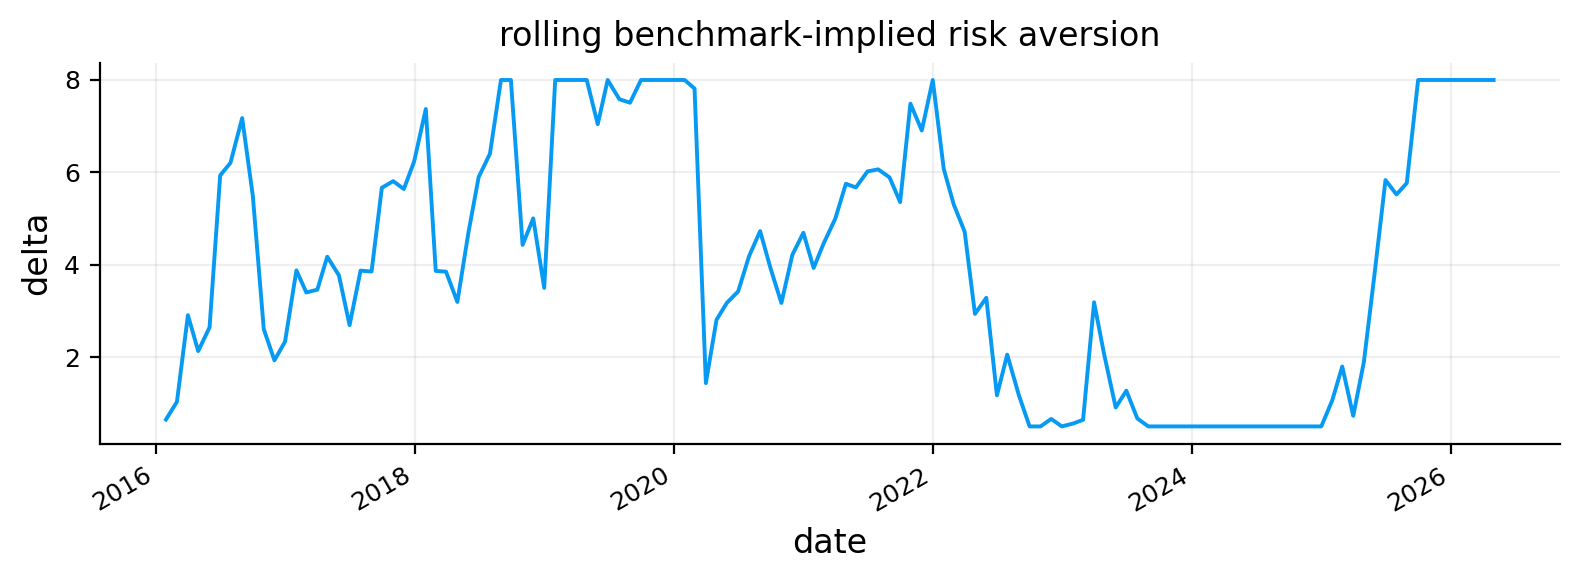

,asset,prior_mu,benchmark_weight
0,EEM,0.2038,0.0505
1,EFA,0.1552,0.0909
2,GLD,0.1525,0.0505
3,IWM,0.1483,0.0404
4,QQQ,0.1370,0.0808
5,SPY,0.1109,0.2222
6,VNQ,0.0769,0.0404
7,TLT,0.0385,0.0808
8,HYG,0.0361,0.0404
9,LQD,0.0350,0.0505


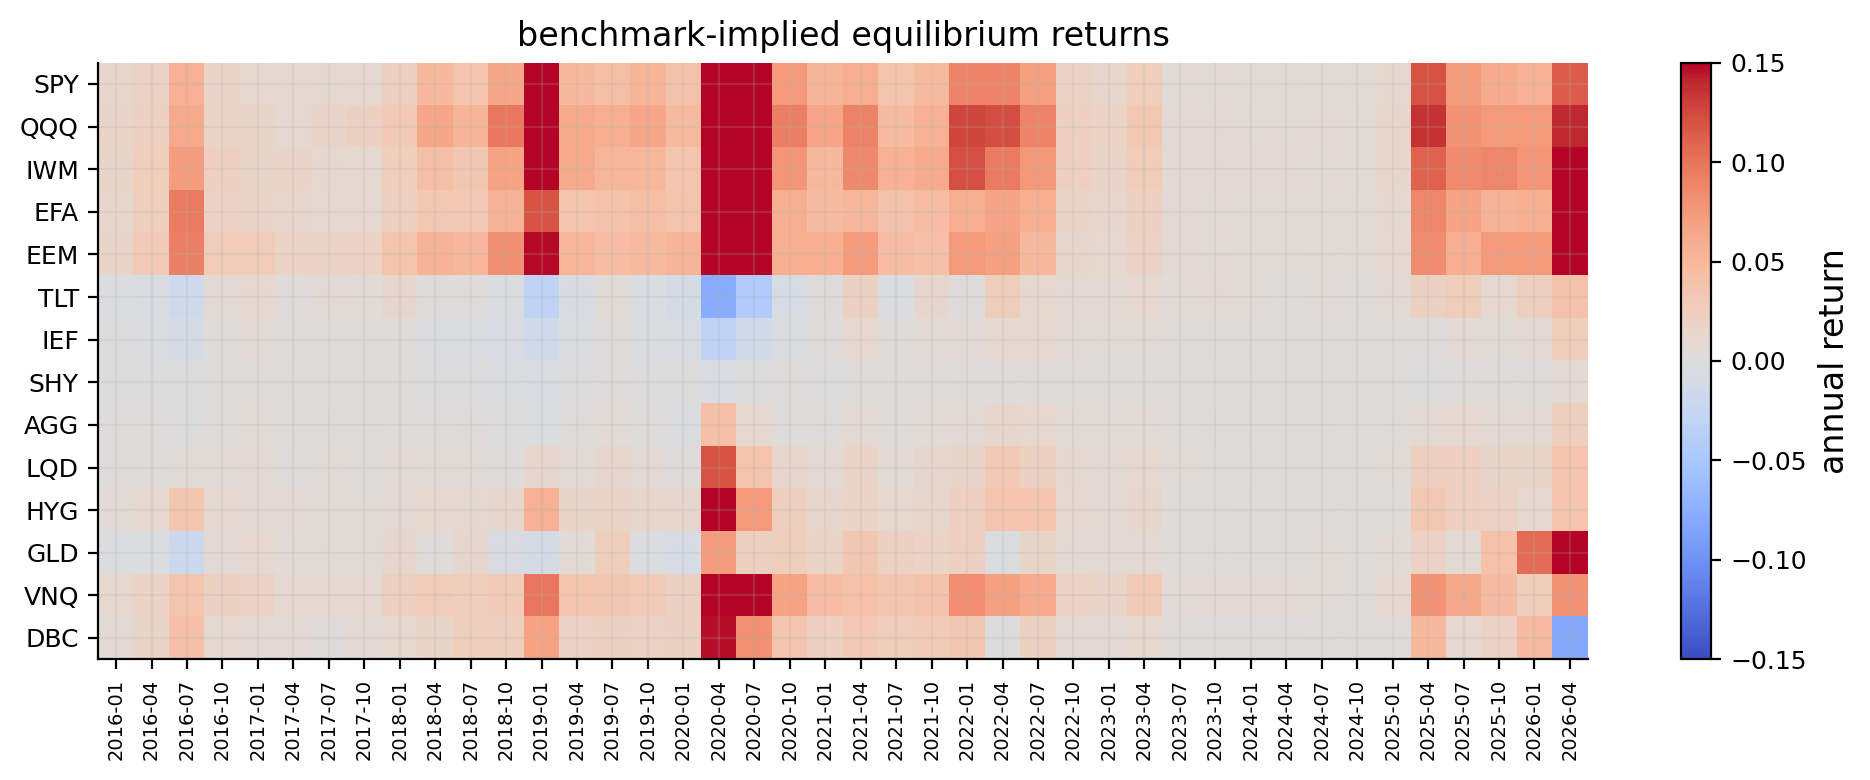

In [12]:
delta_series = pd.Series(delta_by_date).sort_index()
ax = delta_series.plot(figsize=(8, 3), lw=1.4)
ax.set_title("rolling benchmark-implied risk aversion")
ax.set_ylabel("delta")
ax.set_xlabel("date")
plt.tight_layout()
plt.show()

latest_rebalance_date = rebalance_dates[-1]
latest_prior = prior_mu_by_date[pd.Timestamp(latest_rebalance_date)].sort_values(ascending=False)
prior_table = pd.DataFrame({"asset": latest_prior.index, "prior_mu": latest_prior.values, "benchmark_weight": benchmark_w.reindex(latest_prior.index).values})
display(prior_table.round(4))

prior_mu_frame = pd.DataFrame(prior_mu_by_date).T.sort_index()
prior_mu_heat = prior_mu_frame.iloc[::max(1, len(prior_mu_frame) // 36)].T
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(prior_mu_heat, aspect="auto", cmap="coolwarm", vmin=-0.15, vmax=0.15)
ax.set_title("benchmark-implied equilibrium returns")
ax.set_yticks(range(len(prior_mu_heat.index)), prior_mu_heat.index)
ax.set_xticks(range(len(prior_mu_heat.columns)), [d.strftime("%Y-%m") for d in prior_mu_heat.columns], rotation=90, fontsize=7)
fig.colorbar(im, ax=ax, label="annual return")
plt.tight_layout()
plt.show()


In [13]:
cost_bps = 10.0
bl_mv_lambda = 6.0


def simple_nav(returns):
    returns = pd.Series(returns).dropna()
    return (1.0 + returns).cumprod()


def simple_drawdown(nav):
    nav = pd.Series(nav).dropna()
    return nav / nav.cummax() - 1.0


def equal_weight_vector(index):
    out = equal_weight(list(index), w_min=w_min, w_max=w_max, long_only=True, as_series=True)
    return out.reindex(index).fillna(0.0).to_numpy(dtype=float)


def clean_weight_array(weights, index, previous=None):
    if weights is None:
        weights = previous if previous is not None else equal_weight_vector(index)
    w = np.asarray(weights, dtype=float).reshape(-1)
    if len(w) != len(index) or not np.all(np.isfinite(w)):
        w = equal_weight_vector(index) if previous is None else np.asarray(previous, dtype=float)
    w = np.maximum(w, w_min)
    w = np.minimum(w, w_max)
    w = w / w.sum() if w.sum() > 1e-12 else equal_weight_vector(index)
    for _ in range(10):
        over = w > w_max
        if not over.any():
            break
        extra = (w[over] - w_max).sum()
        w[over] = w_max
        room = np.maximum(w_max - w[~over], 0.0)
        if room.sum() <= 1e-12:
            break
        w[~over] += extra * room / room.sum()
    w = np.maximum(w, w_min)
    w = np.minimum(w, w_max)
    return w / w.sum()


In [14]:
def backtest_result_to_dict(name, result, fallback_flags=None):
    flags = pd.Series(dtype=float) if fallback_flags is None else pd.Series(fallback_flags).sort_index()
    return {
        "returns": result.net_returns.rename(name),
        "gross_returns": result.gross_returns.rename(name),
        "nav": result.net_values.rename(name),
        "gross_nav": result.gross_values.rename(name),
        "weights": result.weights.copy(),
        "turnover": result.turnover.rename(name),
        "costs": result.costs.rename(name),
        "fallback_flags": flags.rename(name),
        "fallback_count": int(flags.sum()) if len(flags) else int(result.fallbacks),
    }


def strategic_weight_schedule():
    rows = [benchmark_w.reindex(assets).rename(pd.Timestamp(dt)) for dt in rebalance_dates[:-1]]
    flags = pd.Series(0.0, index=pd.DatetimeIndex(rebalance_dates[:-1]))
    return pd.DataFrame(rows), flags


strategic_weights, strategic_flags = strategic_weight_schedule()
strategic_backtest = run_many_weights_backtests(
    {"Strategic Benchmark": strategic_weights},
    returns=returns[assets],
    cost_bps=cost_bps,
    w_min=w_min,
    w_max=None,
    long_only=True,
    normalize=True,
    weight_timing="next_close",
)["Strategic Benchmark"]

fixed_universe_by_date = {
    pd.Timestamp(dt): {"tickers": list(assets), "avg_dollar_volume": pd.Series(1.0, index=assets)}
    for dt in rebalance_dates
}
walkforward_grid = run_walkforward_grid(
    returns=returns[assets],
    close=close[assets],
    rebalance_dates=rebalance_dates,
    universe_by_date=fixed_universe_by_date,
    cov_lookback=cov_lookback,
    mu_lookback=mu_lookback,
    min_cov_observations=cov_lookback - 1,
    min_mu_observations=mu_lookback - 1,
    max_weight=w_max,
    min_weight=w_min,
    long_only=True,
    trading_cost_bps=cost_bps,
    turnover_penalty_bps=cost_bps,
    fallback="equal",
    rf_daily=risk_free_daily,
    annualization=annualization,
    optimizer_params={
        "MV": {"mv_lambda": bl_mv_lambda},
        "RidgeMV": {"mv_lambda": bl_mv_lambda},
        "FrontierGrid": {"grid_n": 15},
    },
)


def select_best_grid_strategy(grid_summary, optimizer):
    candidates = grid_summary[grid_summary["Optimizer"].eq(optimizer)].replace([np.inf, -np.inf], np.nan).dropna(subset=["Sharpe"])
    if candidates.empty:
        raise ValueError(f"no usable {optimizer} strategies in the walk-forward grid")
    sort_cols = ["Sharpe"]
    ascending = [False]
    if "Max Drawdown" in candidates.columns:
        sort_cols.append("Max Drawdown")
        ascending.append(False)
    if "Turnover" in candidates.columns:
        sort_cols.append("Turnover")
        ascending.append(True)
    return str(candidates.sort_values(sort_cols, ascending=ascending).index[0])


best_minvar_name = select_best_grid_strategy(walkforward_grid.results, "MinVar")
best_mv_name = select_best_grid_strategy(walkforward_grid.results, "MV")

baseline_candidates = {
    "Strategic Benchmark": backtest_result_to_dict("Strategic Benchmark", strategic_backtest, strategic_flags),
    "Equal Weight": backtest_result_to_dict("Equal Weight", walkforward_grid.backtests["EW"]),
    best_minvar_name: backtest_result_to_dict(best_minvar_name, walkforward_grid.backtests[best_minvar_name]),
    best_mv_name: backtest_result_to_dict(best_mv_name, walkforward_grid.backtests[best_mv_name]),
}
baseline_results = {name: baseline_candidates[name] for name in ["Strategic Benchmark", "Equal Weight", best_minvar_name, best_mv_name]}
print("walk-forward grid strategies:", len(walkforward_grid.results))
print("selected benchmark models:", ["Strategic Benchmark", "Equal Weight", best_minvar_name, best_mv_name])


walk-forward grid strategies: 41
selected benchmark models: ['Strategic Benchmark', 'Equal Weight', 'MinVar (OAS)', 'MV (LedoitWolf, BayesStein)']


In [15]:
def quick_metrics(ret, nav=None):
    ret = pd.Series(ret).dropna()
    nav = simple_nav(ret) if nav is None else pd.Series(nav).dropna()
    if ret.empty or nav.empty:
        return {"cagr": np.nan, "ann_vol": np.nan, "sharpe": np.nan, "max_drawdown": np.nan}
    years = max(len(nav) / annualization, 1e-9)
    cagr = float(nav.iloc[-1] ** (1.0 / years) - 1.0)
    ann_vol = float(ret.std(ddof=1) * math.sqrt(annualization))
    sharpe = float((ret.mean() - risk_free_daily) / ret.std(ddof=1) * math.sqrt(annualization)) if ret.std(ddof=1) > 1e-12 else np.nan
    return {"cagr": cagr, "ann_vol": ann_vol, "sharpe": sharpe, "max_drawdown": max_drawdown_from_nav(nav)}


top_mv_minvar = walkforward_grid.results[walkforward_grid.results["Optimizer"].isin(["MV", "MinVar"])].sort_values("Sharpe", ascending=False)

candidate_rows = []
for name, result in baseline_candidates.items():
    m = quick_metrics(result["returns"], result["nav"])
    candidate_rows.append({
        "strategy": name,
        "cagr": m["cagr"],
        "ann_vol": m["ann_vol"],
        "sharpe": m["sharpe"],
        "max_drawdown": m["max_drawdown"],
        "avg_turnover": result["turnover"].mean(),
        "fallback_count": result["fallback_count"],
    })
baseline_candidate_summary = pd.DataFrame(candidate_rows).sort_values("sharpe", ascending=False)
display(baseline_candidate_summary.round(4))
print("benchmarks use the full library walk-forward grid, then keep only best-Sharpe MV and best-Sharpe MinVar; MaxSharpe is not used as a benchmark")


,strategy,cagr,ann_vol,sharpe,max_drawdown,avg_turnover,fallback_count
0,Strategic Benchmark,0.0905,0.1011,0.5213,-0.2242,0.0144,0
1,Equal Weight,0.0848,0.0932,0.4849,-0.2041,0.0113,0
3,"MV (LedoitWolf, BayesStein)",0.0730,0.0687,0.4794,-0.1181,0.0269,0
2,MinVar (OAS),0.0684,0.0755,0.3776,-0.1975,0.0031,0


benchmarks use the full library walk-forward grid, then keep only best-Sharpe MV and best-Sharpe MinVar; MaxSharpe is not used as a benchmark


,avg_turnover
Strategic Benchmark,0.0144
Equal Weight,0.0113
MinVar (OAS),0.0031
"MV (LedoitWolf, BayesStein)",0.0269


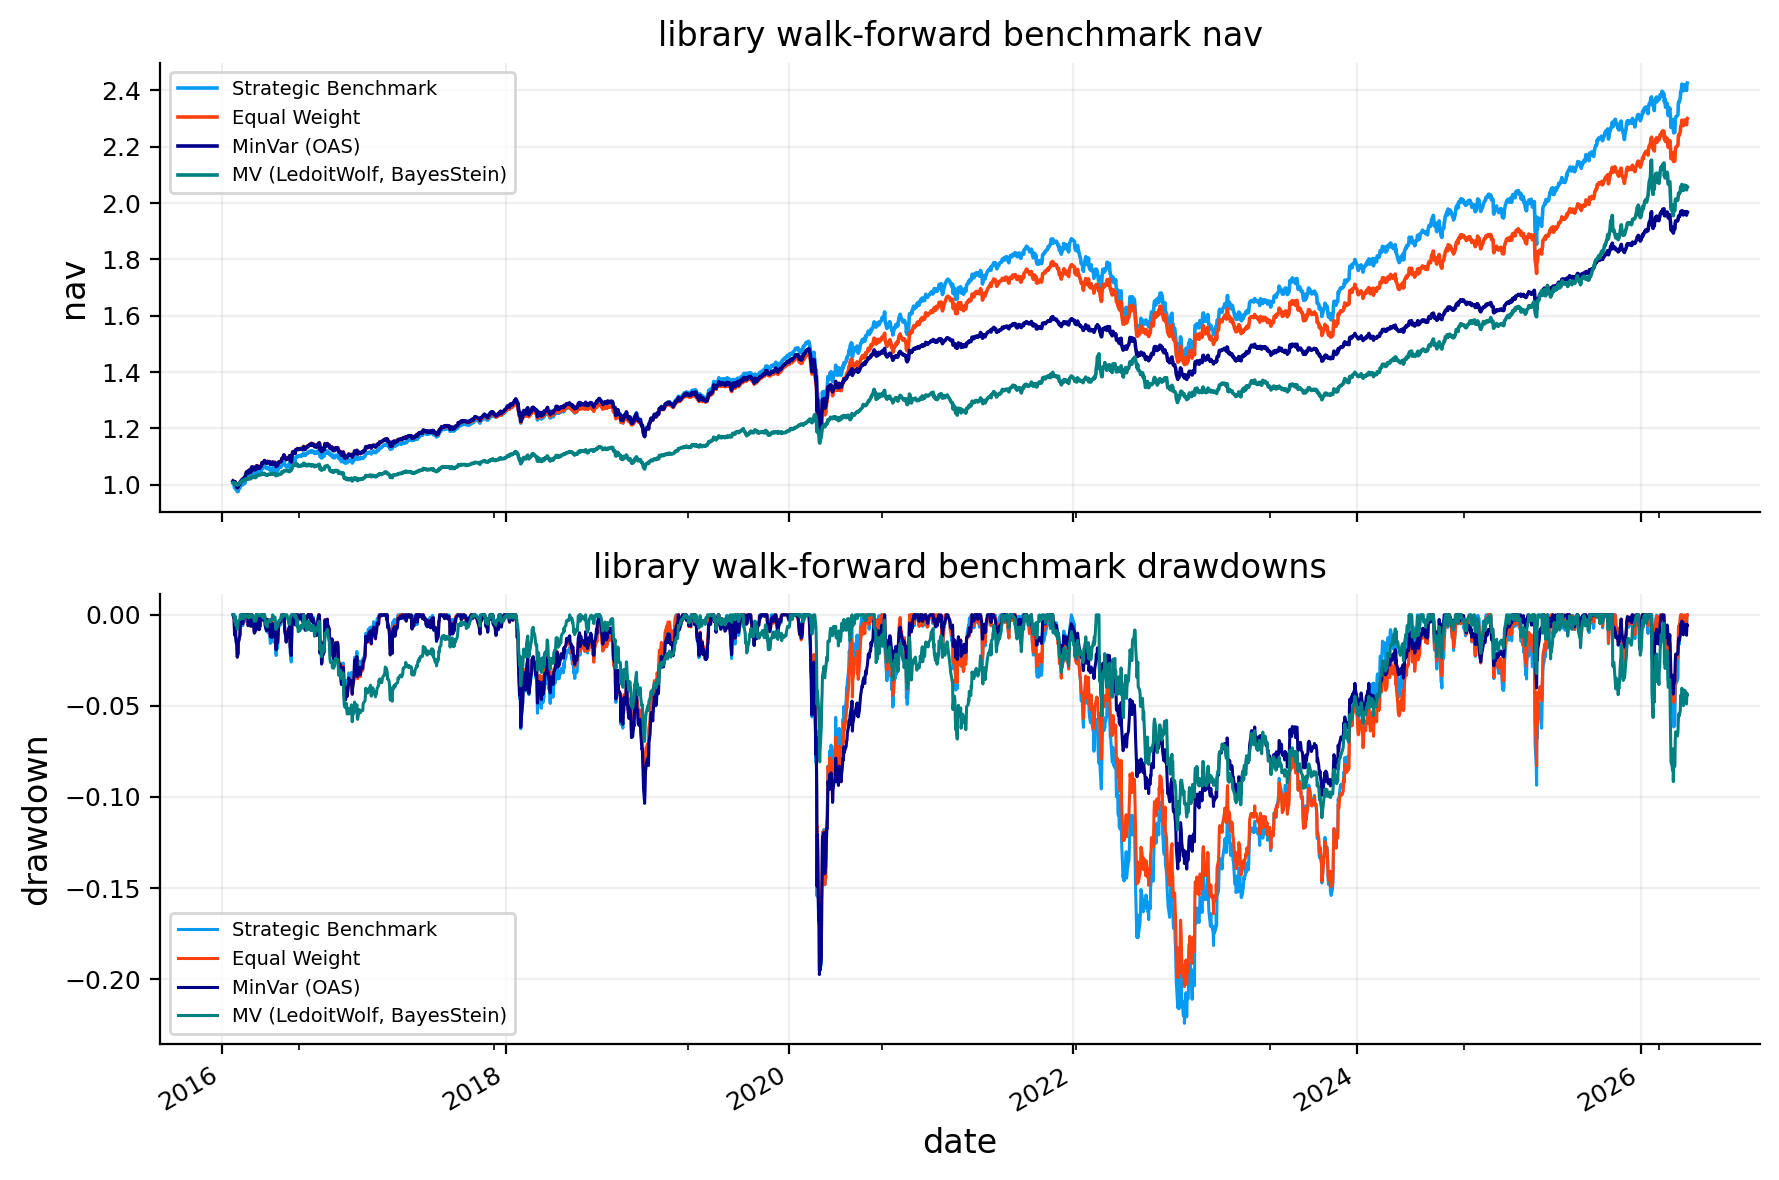

In [16]:
avg_turnover_table = pd.DataFrame({name: result["turnover"].mean() for name, result in baseline_results.items()}, index=["avg_turnover"]).T
display(avg_turnover_table.round(4))
baseline_nav = pd.DataFrame({name: result["nav"] for name, result in baseline_results.items()})
baseline_dd = baseline_nav / baseline_nav.cummax() - 1.0
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
baseline_nav.plot(ax=axes[0], lw=1.3)
axes[0].set_title("library walk-forward benchmark nav")
axes[0].set_ylabel("nav")
baseline_dd.plot(ax=axes[1], lw=1.1)
axes[1].set_title("library walk-forward benchmark drawdowns")
axes[1].set_ylabel("drawdown")
axes[1].set_xlabel("date")
plt.tight_layout(); plt.show()


In [17]:
risky_asset_names = ["SPY", "QQQ", "IWM", "EFA", "EEM", "HYG", "VNQ", "DBC"]
cyclical_asset_names = ["IWM", "EEM", "VNQ", "HYG"]
defensive_asset_names = ["TLT", "IEF", "SHY", "AGG", "LQD", "GLD"]


def winsorized_zscore(series):
    s = pd.Series(series, dtype=float).replace([np.inf, -np.inf], np.nan)
    good = s.dropna()
    if good.empty:
        return pd.Series(0.0, index=s.index)
    clipped = s.clip(good.quantile(0.05), good.quantile(0.95))
    std = clipped.std(ddof=0)
    if not np.isfinite(std) or std < 1e-12:
        return pd.Series(0.0, index=s.index)
    return ((clipped - clipped.mean()) / std).fillna(0.0)


def cumulative_return(window):
    if window is None or len(window) == 0:
        return np.nan
    return float((1.0 + window.dropna()).prod() - 1.0)


def trailing_dividend_yield(dividends, close_hist, ticker, lookback=252):
    if dividends is None or dividends.empty or ticker not in dividends.columns or ticker not in close_hist.columns:
        return np.nan
    div_window = dividends[ticker].reindex(close_hist.index).fillna(0.0).tail(lookback)
    px = close_hist[ticker].dropna()
    if px.empty or px.iloc[-1] <= 0:
        return np.nan
    return float(div_window.sum() / px.iloc[-1])


def relative_cumulative_return(ret_hist, long_asset, short_asset, lookback=63):
    if long_asset not in ret_hist.columns or short_asset not in ret_hist.columns or len(ret_hist) < lookback:
        return np.nan
    long_ret = cumulative_return(ret_hist[long_asset].tail(lookback))
    short_ret = cumulative_return(ret_hist[short_asset].tail(lookback))
    return long_ret - short_ret if np.isfinite(long_ret) and np.isfinite(short_ret) else np.nan


def trailing_pair_correlation(ret_hist, asset_a, asset_b, lookback=126):
    if asset_a not in ret_hist.columns or asset_b not in ret_hist.columns or len(ret_hist) < lookback:
        return np.nan
    window = ret_hist[[asset_a, asset_b]].tail(lookback).dropna()
    if len(window) < max(30, lookback // 3):
        return np.nan
    if window[asset_a].std(ddof=1) <= 1e-12 or window[asset_b].std(ddof=1) <= 1e-12:
        return np.nan
    corr = float(window[asset_a].corr(window[asset_b]))
    return corr if np.isfinite(corr) else np.nan


def trailing_average_correlation(ret_hist, names, lookback=126):
    names = [x for x in names if x in ret_hist.columns]
    if len(names) < 2 or len(ret_hist) < lookback:
        return np.nan
    window = ret_hist[names].tail(lookback).dropna(how="any")
    if len(window) < max(30, lookback // 3):
        return np.nan
    corr = window.corr().replace([np.inf, -np.inf], np.nan)
    vals = corr.where(~np.eye(len(corr), dtype=bool)).stack().dropna()
    return float(vals.mean()) if len(vals) else np.nan


def trend_breadth_from_close(close_hist, names, ma_window=200, offset=0):
    names = [x for x in names if x in close_hist.columns]
    if not names:
        return np.nan
    hist = close_hist.iloc[:len(close_hist) - offset] if offset and len(close_hist) > offset else close_hist
    vals = []
    for ticker in names:
        px = hist[ticker].dropna()
        if len(px) < ma_window:
            continue
        ma = px.tail(ma_window).mean()
        if ma > 0:
            vals.append(px.iloc[-1] / ma - 1.0)
    return float((pd.Series(vals) > 0).mean()) if vals else np.nan


def compute_asset_signals(close, returns, date, dividends=None):
    date = pd.Timestamp(date)
    close_pos = close.index.searchsorted(date, side="right") - 1
    ret_pos = returns.index.searchsorted(date, side="right") - 1
    close_hist = close.iloc[:close_pos + 1]
    ret_hist = returns.iloc[:ret_pos + 1]
    rows = []
    for ticker in returns.columns:
        px = close_hist[ticker].dropna() if ticker in close_hist else pd.Series(dtype=float)
        rt = ret_hist[ticker].dropna() if ticker in ret_hist else pd.Series(dtype=float)
        if len(px) < 200 or len(rt) < 63:
            continue
        mom_1_0 = cumulative_return(rt.tail(21))
        mom_3_0 = cumulative_return(rt.tail(63))
        mom_6_1 = cumulative_return(rt.iloc[-147:-21]) if len(rt) >= 147 else np.nan
        mom_12_1 = cumulative_return(rt.iloc[-273:-21]) if len(rt) >= 273 else np.nan
        trend_50 = float(px.iloc[-1] / px.tail(50).mean() - 1.0) if px.tail(50).mean() > 0 else np.nan
        trend_200 = float(px.iloc[-1] / px.tail(200).mean() - 1.0) if px.tail(200).mean() > 0 else np.nan
        vol_63 = float(rt.tail(63).std(ddof=1) * math.sqrt(annualization))
        high_252 = px.tail(252).max()
        dd_252 = float(px.iloc[-1] / high_252 - 1.0) if high_252 > 0 else np.nan
        rows.append({
            "ticker": ticker,
            "sleeve": sleeve_map.get(ticker, "Other"),
            "mom_1_0": mom_1_0,
            "mom_3_0": mom_3_0,
            "mom_6_1": mom_6_1,
            "mom_12_1": mom_12_1,
            "trend_50": trend_50,
            "trend_200": trend_200,
            "vol_63": vol_63,
            "dd_252": dd_252,
            "drawdown_quality": dd_252,
            "dividend_yield_252": trailing_dividend_yield(dividends, close_hist, ticker),
        })
    asset_signal_table = pd.DataFrame(rows).set_index("ticker") if rows else pd.DataFrame()
    if asset_signal_table.empty:
        return asset_signal_table, {}
    asset_signal_table["score"] = (
        0.25 * winsorized_zscore(asset_signal_table["mom_3_0"])
        + 0.25 * winsorized_zscore(asset_signal_table["mom_6_1"])
        + 0.15 * winsorized_zscore(asset_signal_table["mom_12_1"])
        + 0.20 * winsorized_zscore(asset_signal_table["trend_200"])
        - 0.10 * winsorized_zscore(asset_signal_table["vol_63"])
        + 0.05 * winsorized_zscore(asset_signal_table["drawdown_quality"])
    )
    scores = asset_signal_table["score"]
    risky_available = [ticker for ticker in risky_asset_names if ticker in scores.index]
    defensive_available = [ticker for ticker in defensive_asset_names if ticker in scores.index]
    cyclical_available = [ticker for ticker in cyclical_asset_names if ticker in scores.index]
    risky_trend_breadth = float((asset_signal_table.reindex(risky_available)["trend_200"] > 0).mean()) if risky_available else np.nan
    cyclical_trend_breadth = float((asset_signal_table.reindex(cyclical_available)["trend_200"] > 0).mean()) if cyclical_available else np.nan
    risky_trend_breadth_3m_ago = trend_breadth_from_close(close_hist, risky_available, offset=63)
    cyclical_trend_breadth_3m_ago = trend_breadth_from_close(close_hist, cyclical_available, offset=63)
    spy_drawdown_252 = float(asset_signal_table.loc["SPY", "dd_252"]) if "SPY" in asset_signal_table.index else np.nan
    spy_vol_63 = float(asset_signal_table.loc["SPY", "vol_63"]) if "SPY" in asset_signal_table.index else np.nan
    spy_vol_line = ret_hist["SPY"].rolling(63).std() * math.sqrt(annualization) if "SPY" in ret_hist.columns else pd.Series(dtype=float)
    vol_sample = spy_vol_line.dropna().tail(252)
    spy_vol_threshold = vol_sample.quantile(0.80) if not vol_sample.empty else np.nan
    spy_vol_z = float((spy_vol_63 - vol_sample.mean()) / vol_sample.std(ddof=1)) if len(vol_sample) > 20 and vol_sample.std(ddof=1) > 1e-12 else np.nan
    spy_tlt_corr_126 = trailing_pair_correlation(ret_hist, "SPY", "TLT", 126)
    spy_ief_corr_126 = trailing_pair_correlation(ret_hist, "SPY", "IEF", 126)
    stock_bond_corr_126 = spy_tlt_corr_126 if np.isfinite(spy_tlt_corr_126) else spy_ief_corr_126
    market_state = {
        "risky_median_score": float(scores.reindex(risky_available).median()) if risky_available else np.nan,
        "defensive_median_score": float(scores.reindex(defensive_available).median()) if defensive_available else np.nan,
        "risk_on_score": (float(scores.reindex(risky_available).median()) - float(scores.reindex(defensive_available).median())) if risky_available and defensive_available else np.nan,
        "risky_trend_breadth": risky_trend_breadth,
        "risky_trend_breadth_3m_ago": risky_trend_breadth_3m_ago,
        "risky_trend_breadth_change_63": risky_trend_breadth - risky_trend_breadth_3m_ago if np.isfinite(risky_trend_breadth) and np.isfinite(risky_trend_breadth_3m_ago) else np.nan,
        "cyclical_trend_breadth": cyclical_trend_breadth,
        "cyclical_trend_breadth_3m_ago": cyclical_trend_breadth_3m_ago,
        "cyclical_trend_breadth_change_63": cyclical_trend_breadth - cyclical_trend_breadth_3m_ago if np.isfinite(cyclical_trend_breadth) and np.isfinite(cyclical_trend_breadth_3m_ago) else np.nan,
        "spy_trend_200": float(asset_signal_table.loc["SPY", "trend_200"]) if "SPY" in asset_signal_table.index else np.nan,
        "spy_drawdown_252": spy_drawdown_252,
        "spy_vol_63": spy_vol_63,
        "spy_vol_z": spy_vol_z,
        "equity_stress": bool((np.isfinite(spy_drawdown_252) and spy_drawdown_252 < -0.10) or (np.isfinite(spy_vol_63) and np.isfinite(spy_vol_threshold) and spy_vol_63 > spy_vol_threshold)),
        "qqq_spy_63": relative_cumulative_return(ret_hist, "QQQ", "SPY", 63),
        "qqq_spy_126": relative_cumulative_return(ret_hist, "QQQ", "SPY", 126),
        "hyg_lqd_63": relative_cumulative_return(ret_hist, "HYG", "LQD", 63),
        "hyg_lqd_126": relative_cumulative_return(ret_hist, "HYG", "LQD", 126),
        "iwm_spy_63": relative_cumulative_return(ret_hist, "IWM", "SPY", 63),
        "iwm_spy_126": relative_cumulative_return(ret_hist, "IWM", "SPY", 126),
        "eem_efa_63": relative_cumulative_return(ret_hist, "EEM", "EFA", 63),
        "dbc_ief_63": relative_cumulative_return(ret_hist, "DBC", "IEF", 63),
        "dbc_agg_63": relative_cumulative_return(ret_hist, "DBC", "AGG", 63),
        "dollar_trend": float(asset_signal_table.loc["UUP", "trend_200"]) if "UUP" in asset_signal_table.index else np.nan,
        "dollar_mom_3_0": float(asset_signal_table.loc["UUP", "mom_3_0"]) if "UUP" in asset_signal_table.index else np.nan,
        "spy_tlt_corr_126": spy_tlt_corr_126,
        "spy_ief_corr_126": spy_ief_corr_126,
        "stock_bond_corr_126": stock_bond_corr_126,
        "avg_risky_corr_126": trailing_average_correlation(ret_hist, risky_available, 126),
        "avg_risky_corr_63": trailing_average_correlation(ret_hist, risky_available, 63),
        "asset_corr_to_spy_126": {asset: trailing_pair_correlation(ret_hist, asset, "SPY", 126) for asset in asset_signal_table.index if asset != "SPY"},
        "real_asset_score": float(scores.reindex([x for x in ["GLD", "DBC"] if x in scores.index]).median()) if any(x in scores.index for x in ["GLD", "DBC"]) else np.nan,
        "bond_score": float(scores.reindex([x for x in ["TLT", "IEF", "AGG"] if x in scores.index]).median()) if any(x in scores.index for x in ["TLT", "IEF", "AGG"]) else np.nan,
    }
    return asset_signal_table.sort_values("score", ascending=False), market_state

In [18]:
latest_signal_table, latest_market_state = compute_asset_signals(signal_close, signal_returns, latest_rebalance_date, dividends=dividends_all)
signal_display_cols = ["sleeve", "mom_1_0", "mom_3_0", "mom_6_1", "trend_50", "trend_200", "vol_63", "dd_252", "dividend_yield_252", "score"]
display(latest_signal_table[signal_display_cols].reset_index().round(4))
print("the score ranks assets for relative views; it is not used as a standalone return forecast")
print(latest_market_state)


,ticker,sleeve,mom_1_0,mom_3_0,mom_6_1,trend_50,trend_200,vol_63,dd_252,dividend_yield_252,score
0,DBC,Commodities,0.0743,0.2612,0.3158,0.0908,0.2975,0.2512,-0.0093,0.0241,1.7445
1,EEM,International equity,0.1206,0.0851,0.0871,0.0711,0.1634,0.2832,0.0000,0.0189,0.8135
2,IWM,US equity,0.1191,0.0775,0.0367,0.0758,0.1299,0.2157,0.0000,0.0091,0.5005
3,QQQ,US equity,0.1538,0.0854,-0.0243,0.1009,0.1182,0.1969,0.0000,0.0042,0.3587
4,GLD,Real assets,-0.0334,-0.0489,0.2317,-0.0470,0.0808,0.3438,-0.1466,0.0000,0.2701
5,SPY,US equity,0.0998,0.0443,-0.0108,0.0606,0.0789,0.1514,0.0000,0.0102,-0.0112
6,EFA,International equity,0.0354,0.0135,0.0753,0.0192,0.0708,0.2131,-0.0337,0.0318,-0.0266
7,VNQ,Real assets,0.0791,0.0692,-0.0069,0.0374,0.0711,0.1477,-0.0100,0.0363,-0.0835
8,UUP,Dollar,-0.0115,0.0209,0.0424,-0.0037,0.0138,0.0626,-0.0204,0.0338,-0.3393
9,HYG,Credit,0.0140,0.0068,0.0112,0.0091,0.0200,0.0524,-0.0021,0.0635,-0.3650


the score ranks assets for relative views; it is not used as a standalone return forecast
{'risky_median_score': 0.17374867205248162, 'defensive_median_score': -0.5288770319735261, 'risk_on_score': 0.7026257040260078, 'risky_trend_breadth': 1.0, 'risky_trend_breadth_3m_ago': 1.0, 'risky_trend_breadth_change_63': 0.0, 'cyclical_trend_breadth': 1.0, 'cyclical_trend_breadth_3m_ago': 1.0, 'cyclical_trend_breadth_change_63': 0.0, 'spy_trend_200': 0.07891809711481845, 'spy_drawdown_252': 0.0, 'spy_vol_63': 0.15136413478464925, 'spy_vol_z': -0.07002872545379353, 'equity_stress': False, 'qqq_spy_63': 0.0411448064245048, 'qqq_spy_126': 0.008717305622156335, 'hyg_lqd_63': 0.009586676538705818, 'hyg_lqd_126': 0.03045734135686773, 'iwm_spy_63': 0.03322394644058324, 'iwm_spy_126': 0.08287933191322816, 'eem_efa_63': 0.07160985901167893, 'dbc_ief_63': 0.2609741837498576, 'dbc_agg_63': 0.26040566991034075, 'dollar_trend': 0.013843082442195564, 'dollar_mom_3_0': 0.020856590614012127, 'spy_tlt_corr_126'

In [19]:
family_q_caps = {
    "liquid_leadership": 0.042,
    "dual_momentum": 0.022,
    "inflation_rotation": 0.024,
    "risk_adj_momentum": 0.014,
    "credit_switch": 0.010,
    "reflation_breadth": 0.042,
    "growth_duration": 0.032,
    "correlation_stress": 0.024,
    "international_rotation": 0.018,
    "duration_quality": 0.010,
}
family_display_names = {
    "liquid_leadership": "Liquidity leadership",
    "dual_momentum": "Dual momentum",
    "inflation_rotation": "Inflation rotation",
    "risk_adj_momentum": "Risk-adjusted momentum",
    "credit_switch": "Credit switch",
    "reflation_breadth": "Reflation breadth",
    "growth_duration": "Growth-duration barbell",
    "correlation_stress": "Correlation stress",
    "international_rotation": "International rotation",
    "duration_quality": "Duration quality",
}
view_entry_z = 0.50
q_strength_scale = 1.25
max_active_views = len(family_q_caps)


def clean_diag_value(value):
    if isinstance(value, (np.floating, np.integer)):
        return float(value)
    if isinstance(value, pd.Timestamp):
        return value.strftime("%Y-%m-%d")
    if isinstance(value, (list, tuple)):
        return [clean_diag_value(x) for x in value]
    if isinstance(value, dict):
        return {k: clean_diag_value(v) for k, v in value.items()}
    return value


def p_series_from_assets(long_assets, short_assets, asset_list=assets):
    p = pd.Series(0.0, index=asset_list, dtype=float)
    long_assets = [x for x in long_assets if x in p.index]
    short_assets = [x for x in short_assets if x in p.index]
    if not long_assets or not short_assets:
        return None
    p.loc[long_assets] = 1.0 / len(long_assets)
    p.loc[short_assets] = -1.0 / len(short_assets)
    return p


def make_view_row(view_family, view_name, economic_label, long_assets, short_assets, view_strength, risk_orientation, source="family_rule", priority=0.50, diagnostics=None, confluence_score=None, view_state=None):
    long_assets = list(dict.fromkeys([x for x in long_assets if x in assets]))
    short_assets = list(dict.fromkeys([x for x in short_assets if x in assets and x not in long_assets]))
    if view_family not in family_q_caps or not long_assets or not short_assets or not np.isfinite(view_strength):
        return None
    view_strength = float(abs(view_strength))
    if view_strength <= 1e-8:
        return None
    cap = family_q_caps[view_family]
    q_tilt = float(cap * math.tanh(view_strength / q_strength_scale))
    p = p_series_from_assets(long_assets, short_assets)
    if p is None:
        return None
    confluence = float(np.clip(confluence_score if confluence_score is not None else view_strength / 3.0, 0.0, 1.0))
    display_name = family_display_names.get(view_family, view_family.replace("_", " ").title())
    state = view_state or risk_orientation
    return {
        "view_family": view_family,
        "family_name": display_name,
        "family_display_name": display_name,
        "view_name": view_name,
        "view_side": state,
        "view_state": state,
        "economic_label": economic_label,
        "long_assets": long_assets,
        "short_assets": short_assets,
        "signal_value": view_strength,
        "raw_strength": view_strength,
        "view_strength": view_strength,
        "confluence_score": confluence,
        "q_tilt": q_tilt,
        "q": q_tilt,
        "confidence": np.nan,
        "risk_orientation": risk_orientation,
        "source": source,
        "priority": float(np.clip(priority, 0.0, 1.0)),
        "economic_priority": float(np.clip(priority, 0.0, 1.0)),
        "diagnostics": clean_diag_value(diagnostics or {}),
        "p_vector": p.round(6).to_dict(),
    }


def available(signal_table, names):
    return [x for x in names if x in signal_table.index]


def metric(signal_table, asset, col, default=np.nan):
    if asset not in signal_table.index or col not in signal_table.columns:
        return default
    val = signal_table.loc[asset, col]
    return float(val) if np.isfinite(val) else default


def state_value(market_state, key, default=np.nan):
    val = market_state.get(key, default)
    try:
        return float(val) if np.isfinite(val) else default
    except Exception:
        return default


def score_value(signal_table, asset):
    return metric(signal_table, asset, "score")


def median_score(signal_table, names):
    names = available(signal_table, names)
    return float(signal_table.reindex(names)["score"].median()) if names else np.nan


def robust_mean(values):
    vals = [float(x) for x in values if np.isfinite(x)]
    return float(np.mean(vals)) if vals else np.nan


def clipped(value, scale=1.0, lower=-2.0, upper=2.0):
    if not np.isfinite(value) or scale == 0:
        return np.nan
    return float(np.clip(value / scale, lower, upper))


def best_assets(signal_table, candidates, n=1, require_positive=False):
    names = available(signal_table, candidates)
    if not names:
        return []
    frame = signal_table.reindex(names).sort_values("score", ascending=False)
    if require_positive:
        frame = frame[(frame["score"] > 0) | (frame["trend_200"] > 0) | (frame["mom_3_0"] > 0)]
    return list(frame.head(n).index)


def worst_assets(signal_table, candidates, n=1, require_weak=False):
    names = available(signal_table, candidates)
    if not names:
        return []
    frame = signal_table.reindex(names).sort_values("score", ascending=True)
    if require_weak:
        frame = frame[(frame["score"] < 0) | (frame["trend_200"] < 0) | (frame["mom_3_0"] < 0)]
    return list(frame.head(n).index)


def sleeve_limited_assets(signal_table, candidates, n=3, side="long", per_sleeve=1):
    names = available(signal_table, candidates)
    if not names:
        return []
    frame = signal_table.reindex(names).sort_values("score", ascending=(side == "short"))
    picks, sleeve_counts = [], {}
    for asset, row in frame.iterrows():
        sleeve = row.get("sleeve", sleeve_map.get(asset, "Other"))
        if sleeve_counts.get(sleeve, 0) >= per_sleeve:
            continue
        if side == "long" and row.get("trend_200", 0.0) <= 0 and row.get("mom_3_0", 0.0) <= 0:
            continue
        if side == "short" and row.get("trend_200", 0.0) >= 0 and row.get("mom_3_0", 0.0) >= 0:
            continue
        picks.append(asset)
        sleeve_counts[sleeve] = sleeve_counts.get(sleeve, 0) + 1
        if len(picks) >= n:
            break
    return picks


def cov_corr_to_spy(cov_ann, asset):
    if cov_ann is None or asset not in cov_ann.index or "SPY" not in cov_ann.index:
        return np.nan
    var_a = float(cov_ann.loc[asset, asset])
    var_s = float(cov_ann.loc["SPY", "SPY"])
    if var_a <= 1e-12 or var_s <= 1e-12:
        return np.nan
    corr = float(cov_ann.loc[asset, "SPY"] / math.sqrt(var_a * var_s))
    return corr if np.isfinite(corr) else np.nan


def beta_to_basket(cov_ann, asset, basket):
    basket = [x for x in basket if cov_ann is not None and x in cov_ann.index]
    if cov_ann is None or asset not in cov_ann.index or not basket:
        return np.nan
    b = pd.Series(1.0 / len(basket), index=basket)
    cov_ab = float(cov_ann.loc[asset, basket] @ b)
    var_b = float(b.values @ cov_ann.loc[basket, basket].values @ b.values)
    return cov_ab / var_b if np.isfinite(var_b) and var_b > 1e-12 else np.nan


def add_row(rows, row):
    if row is not None:
        rows.append(row)


def make_high_level_views(signal_table, market_state, cov_ann=None):
    rows = []
    if signal_table.empty:
        return rows

    spy_trend = metric(signal_table, "SPY", "trend_200")
    qqq_trend = metric(signal_table, "QQQ", "trend_200")
    spy_drawdown = state_value(market_state, "spy_drawdown_252", 0.0)
    spy_vol_z = state_value(market_state, "spy_vol_z", 0.0)
    risky_breadth = state_value(market_state, "risky_trend_breadth")
    risky_breadth_change = state_value(market_state, "risky_trend_breadth_change_63", 0.0)
    cyc_breadth = state_value(market_state, "cyclical_trend_breadth")
    cyc_breadth_change = state_value(market_state, "cyclical_trend_breadth_change_63", 0.0)
    qqq_spy = state_value(market_state, "qqq_spy_63", 0.0)
    hyg_lqd = state_value(market_state, "hyg_lqd_63", 0.0)
    iwm_spy = state_value(market_state, "iwm_spy_63", 0.0)
    eem_efa = state_value(market_state, "eem_efa_63", 0.0)
    dbc_ief = state_value(market_state, "dbc_ief_63", 0.0)
    dbc_agg = state_value(market_state, "dbc_agg_63", 0.0)
    stock_bond_corr = state_value(market_state, "stock_bond_corr_126")
    avg_risky_corr = state_value(market_state, "avg_risky_corr_126")
    candidates = [asset for asset in assets if asset in signal_table.index]

    leaders = best_assets(signal_table, ["SPY", "QQQ"], n=2, require_positive=True)
    weak_cyclicals = worst_assets(signal_table, ["IWM", "EEM", "VNQ", "HYG"], n=3, require_weak=True)
    if len(weak_cyclicals) < 2:
        weak_cyclicals = worst_assets(signal_table, ["IWM", "EEM", "VNQ", "HYG"], n=3)
    reflation_confirmed = (
        iwm_spy > 0.015 and hyg_lqd > 0.010 and np.isfinite(cyc_breadth) and cyc_breadth >= 0.75
        and (metric(signal_table, "DBC", "trend_200") > 0 or metric(signal_table, "VNQ", "trend_200") > 0)
    )
    leadership_spread = median_score(signal_table, leaders) - median_score(signal_table, weak_cyclicals) if leaders and weak_cyclicals else np.nan
    liquid_strength = robust_mean([clipped(max(spy_trend, qqq_trend), 0.06), clipped(qqq_spy, 0.035), clipped(leadership_spread, 1.25), clipped(0.55 - cyc_breadth, 0.25), clipped(-cyc_breadth_change, 0.25)])
    if leaders and weak_cyclicals and max(spy_trend, qqq_trend) > 0 and liquid_strength > 0.25 and not reflation_confirmed:
        add_row(rows, make_view_row("liquid_leadership", "Liquidity leadership", "liquid US large-cap and growth leadership versus weak cyclicals", leaders, weak_cyclicals, liquid_strength, "risk_on", priority=0.90, diagnostics={"leadership_spread": leadership_spread, "cyclical_breadth": cyc_breadth, "cyclical_breadth_change_63": cyc_breadth_change, "qqq_spy_63": qqq_spy, "reflation_confirmed_filter": reflation_confirmed}, confluence_score=min(1.0, max(liquid_strength, 0.0) / 2.0), view_state="narrow_leadership"))

    dual_table = signal_table.reindex(candidates).copy()
    dual_table["score"] = 0.40 * winsorized_zscore(dual_table["mom_6_1"]) + 0.25 * winsorized_zscore(dual_table["mom_12_1"]) + 0.20 * winsorized_zscore(dual_table["mom_3_0"]) + 0.15 * winsorized_zscore(dual_table["trend_200"])
    dual_dispersion = float(dual_table["score"].quantile(0.80) - dual_table["score"].quantile(0.20)) if len(dual_table) >= 6 else np.nan
    dual_longs = sleeve_limited_assets(dual_table, candidates, n=4, side="long", per_sleeve=1)
    if len(dual_longs) < 3:
        dual_longs = list(dual_table[(dual_table["trend_200"] > 0) | (dual_table["mom_3_0"] > 0)].sort_values("score", ascending=False).head(4).index)
    dual_shorts = sleeve_limited_assets(dual_table, candidates, n=4, side="short", per_sleeve=1)
    if len(dual_shorts) < 3:
        dual_shorts = list(dual_table[(dual_table["trend_200"] < 0) | (dual_table["mom_3_0"] < 0)].sort_values("score").head(4).index)
    dual_spread = median_score(dual_table, dual_longs) - median_score(dual_table, dual_shorts) if dual_longs and dual_shorts else np.nan
    if dual_longs and dual_shorts and np.isfinite(dual_dispersion) and dual_dispersion > 0.65 and dual_spread > 0.50:
        add_row(rows, make_view_row("dual_momentum", "Dual momentum", "diversified cross-asset momentum with positive absolute trend preference", dual_longs, dual_shorts, max(dual_spread, dual_dispersion), "neutral", priority=0.85, diagnostics={"dual_dispersion": dual_dispersion, "long_scores": dual_table.reindex(dual_longs)["score"].to_dict(), "short_scores": dual_table.reindex(dual_shorts)["score"].to_dict()}, confluence_score=min(1.0, max(dual_spread, 0.0) / 2.5), view_state="trend_following"))

    commodity_score = median_score(signal_table, ["DBC", "GLD"])
    duration_score = median_score(signal_table, ["TLT", "IEF", "AGG"])
    commodity_confirmed = any(metric(signal_table, asset, "trend_200") > 0 and metric(signal_table, asset, "mom_3_0") > 0 for asset in ["DBC", "GLD"] if asset in signal_table.index)
    duration_weak = any(metric(signal_table, asset, "trend_200") < 0 for asset in ["TLT", "IEF", "AGG"] if asset in signal_table.index)
    inflation_strength = robust_mean([clipped(max(dbc_ief, dbc_agg), 0.035), clipped(commodity_score - duration_score, 1.25), clipped(-hyg_lqd, 0.04)])
    if commodity_confirmed and duration_weak and hyg_lqd < 0.020 and inflation_strength > 0.20:
        longs = best_assets(signal_table, ["DBC", "GLD"], n=2, require_positive=True)
        shorts = worst_assets(signal_table, ["TLT", "IEF", "AGG", "LQD", "HYG", "VNQ"], n=4, require_weak=True)
        if len(shorts) < 3:
            shorts = worst_assets(signal_table, ["TLT", "IEF", "AGG", "LQD"], n=3)
        add_row(rows, make_view_row("inflation_rotation", "Inflation rotation", "commodities and gold versus duration and credit when inflation pressure dominates", longs, shorts, max(inflation_strength, commodity_score - duration_score), "neutral", priority=0.80, diagnostics={"commodity_score": commodity_score, "duration_score": duration_score, "dbc_ief_63": dbc_ief, "dbc_agg_63": dbc_agg, "hyg_lqd_63": hyg_lqd}, confluence_score=min(1.0, max(inflation_strength, 0.0) / 2.0), view_state="inflation_shock"))

    risk_adj_table = signal_table.reindex(candidates).copy()
    risk_adj_table["score"] = 0.30 * winsorized_zscore(risk_adj_table["mom_6_1"]) + 0.25 * winsorized_zscore(risk_adj_table["mom_12_1"]) + 0.15 * winsorized_zscore(risk_adj_table["mom_3_0"]) + 0.15 * winsorized_zscore(risk_adj_table["trend_200"]) - 0.20 * winsorized_zscore(risk_adj_table["vol_63"]) + 0.15 * winsorized_zscore(risk_adj_table["drawdown_quality"])
    risk_adj_dispersion = float(risk_adj_table["score"].quantile(0.80) - risk_adj_table["score"].quantile(0.20)) if len(risk_adj_table) >= 6 else np.nan
    ra_longs = list(risk_adj_table[(risk_adj_table["trend_200"] > 0) | (risk_adj_table["mom_3_0"] > 0)].sort_values("score", ascending=False).head(4).index)
    if len(ra_longs) < 3:
        ra_longs = list(risk_adj_table.sort_values("score", ascending=False).head(4).index)
    weak_mask = (risk_adj_table["trend_200"] < 0) | (risk_adj_table["vol_63"] > risk_adj_table["vol_63"].median()) | (risk_adj_table["dd_252"] < risk_adj_table["dd_252"].median())
    ra_shorts = list(risk_adj_table[weak_mask].sort_values("score").head(4).index)
    if len(ra_shorts) < 3:
        ra_shorts = list(risk_adj_table.sort_values("score").head(4).index)
    ra_spread = median_score(risk_adj_table, ra_longs) - median_score(risk_adj_table, ra_shorts) if ra_longs and ra_shorts else np.nan
    if ra_longs and ra_shorts and np.isfinite(risk_adj_dispersion) and risk_adj_dispersion > 0.55 and ra_spread > 0.50:
        add_row(rows, make_view_row("risk_adj_momentum", "Risk-adjusted momentum", "momentum adjusted for volatility and drawdown quality", ra_longs, ra_shorts, max(ra_spread, risk_adj_dispersion), "neutral", priority=1.00, diagnostics={"risk_adj_dispersion": risk_adj_dispersion, "long_scores": risk_adj_table.reindex(ra_longs)["score"].to_dict(), "short_scores": risk_adj_table.reindex(ra_shorts)["score"].to_dict()}, confluence_score=min(1.0, max(ra_spread, 0.0) / 2.5), view_state="quality_momentum"))

    credit_risk_on = spy_trend > 0 and hyg_lqd > 0.010 and np.isfinite(risky_breadth) and risky_breadth >= 0.55
    credit_risk_off = (spy_trend < 0 or spy_drawdown < -0.08 or spy_vol_z > 0.80) and hyg_lqd < -0.005 and (not np.isfinite(risky_breadth) or risky_breadth < 0.55)
    if credit_risk_on:
        longs = [x for x in ["SPY", "QQQ", "HYG"] if x in signal_table.index]
        if iwm_spy > 0 and metric(signal_table, "IWM", "trend_200") > 0:
            longs.append("IWM")
        shorts = available(signal_table, ["SHY", "IEF", "AGG"])
        strength = robust_mean([clipped(spy_trend, 0.06), clipped(hyg_lqd, 0.025), clipped(risky_breadth - 0.50, 0.30)])
        add_row(rows, make_view_row("credit_switch", "Credit switch: risk-on", "credit confirmation supports equity and high-yield risk", longs, shorts, strength, "risk_on", priority=0.88, diagnostics={"spy_trend_200": spy_trend, "hyg_lqd_63": hyg_lqd, "risky_breadth": risky_breadth}, confluence_score=min(1.0, max(strength, 0.0) / 2.0), view_state="risk_on"))
    elif credit_risk_off:
        longs = best_assets(signal_table, ["SHY", "IEF", "AGG", "GLD"], n=4)
        shorts = worst_assets(signal_table, ["HYG", "IWM", "EEM", "VNQ"], n=4, require_weak=True)
        if len(shorts) < 3:
            shorts = worst_assets(signal_table, ["HYG", "IWM", "EEM", "VNQ"], n=4)
        strength = robust_mean([clipped(-spy_trend, 0.06), clipped(-hyg_lqd, 0.025), clipped(0.55 - risky_breadth, 0.30), clipped(-spy_drawdown, 0.15)])
        add_row(rows, make_view_row("credit_switch", "Credit switch: risk-off", "credit rejection shifts toward short-duration, core bonds, and gold", longs, shorts, strength, "risk_off", priority=0.88, diagnostics={"spy_trend_200": spy_trend, "spy_drawdown_252": spy_drawdown, "hyg_lqd_63": hyg_lqd, "risky_breadth": risky_breadth}, confluence_score=min(1.0, max(strength, 0.0) / 2.0), view_state="risk_off"))


    dollar_trend = state_value(market_state, "dollar_trend", 0.0)
    dollar_mom = state_value(market_state, "dollar_mom_3_0", 0.0)
    eem_trend = metric(signal_table, "EEM", "trend_200")
    efa_trend = metric(signal_table, "EFA", "trend_200")
    eem_efta_score_spread = score_value(signal_table, "EEM") - score_value(signal_table, "EFA")
    eem_leadership = eem_efa > 0.040 and dollar_trend < 0.040 and dollar_mom < 0.030 and eem_trend > -0.02
    efa_leadership = eem_efa < -0.020 and dollar_trend > 0.020 and dollar_mom > 0.0
    if eem_leadership:
        strength = robust_mean([clipped(eem_efa, 0.050), clipped(0.040 - dollar_trend, 0.040), clipped(eem_efta_score_spread, 1.00), clipped(eem_trend, 0.08)])
        add_row(rows, make_view_row(
            "international_rotation", "International rotation", "EM leadership over developed ex-US when EEM relative strength is strong and the dollar is not a headwind",
            ["EEM"], ["EFA"], strength, "risk_on", priority=0.72,
            diagnostics={"eem_efa_63": eem_efa, "dollar_trend": dollar_trend, "dollar_mom_3_0": dollar_mom, "eem_trend_200": eem_trend, "efa_trend_200": efa_trend, "score_spread": eem_efta_score_spread},
            confluence_score=min(1.0, max(strength, 0.0) / 2.0), view_state="em_leadership"))
    elif efa_leadership:
        strength = robust_mean([clipped(-eem_efa, 0.040), clipped(dollar_trend, 0.050), clipped(dollar_mom, 0.030), clipped(-eem_efta_score_spread, 1.00)])
        add_row(rows, make_view_row(
            "international_rotation", "International rotation", "developed ex-US leadership over EM when EEM is weak and dollar pressure is strong",
            ["EFA"], ["EEM"], strength, "risk_off", priority=0.72,
            diagnostics={"eem_efa_63": eem_efa, "dollar_trend": dollar_trend, "dollar_mom_3_0": dollar_mom, "eem_trend_200": eem_trend, "efa_trend_200": efa_trend, "score_spread": eem_efta_score_spread},
            confluence_score=min(1.0, max(strength, 0.0) / 2.0), view_state="developed_ex_us_leadership"))

    reflation_active = iwm_spy > 0.010 and hyg_lqd > 0.008 and np.isfinite(risky_breadth) and risky_breadth >= 0.55 and (metric(signal_table, "DBC", "trend_200") > 0 or metric(signal_table, "VNQ", "trend_200") > 0) and spy_drawdown > -0.12
    if reflation_active:
        reflation_longs = [x for x in ["IWM", "HYG", "VNQ", "DBC", "EEM"] if x in signal_table.index and (metric(signal_table, x, "trend_200") > 0 or metric(signal_table, x, "mom_3_0") > 0)]
        if len(reflation_longs) < 3:
            reflation_longs = best_assets(signal_table, ["IWM", "HYG", "VNQ", "DBC", "EEM"], n=4, require_positive=True)
        reflation_shorts = available(signal_table, ["SHY", "IEF", "AGG", "GLD"])
        reflation_strength = robust_mean([clipped(iwm_spy, 0.030), clipped(hyg_lqd, 0.020), clipped(risky_breadth - 0.50, 0.25), clipped(max(metric(signal_table, "DBC", "trend_200"), metric(signal_table, "VNQ", "trend_200")), 0.08)])
        add_row(rows, make_view_row("reflation_breadth", "Reflation breadth", "cyclicals, credit, real assets, and EM broaden versus defensive ballast", reflation_longs, reflation_shorts, reflation_strength, "risk_on", priority=0.78, diagnostics={"iwm_spy_63": iwm_spy, "hyg_lqd_63": hyg_lqd, "risky_breadth": risky_breadth, "spy_drawdown_252": spy_drawdown}, confluence_score=min(1.0, max(reflation_strength, 0.0) / 2.0), view_state="broad_reflation"))

    duration_candidates = [x for x in ["IEF", "AGG", "TLT"] if x in signal_table.index and (metric(signal_table, x, "trend_200") > 0 or metric(signal_table, x, "trend_50") > 0)]
    dbc_weak = metric(signal_table, "DBC", "trend_200") < 0 or metric(signal_table, "DBC", "mom_3_0") < 0
    growth_duration_active = qqq_spy > 0.005 and duration_candidates and dbc_weak and ((not np.isfinite(stock_bond_corr)) or stock_bond_corr < 0.25) and hyg_lqd > -0.040
    if growth_duration_active:
        longs = [x for x in ["QQQ", "SPY"] if x in signal_table.index and (metric(signal_table, x, "trend_200") > 0 or metric(signal_table, x, "mom_3_0") > 0)] + duration_candidates[:3]
        shorts = worst_assets(signal_table, ["DBC", "HYG", "IWM", "VNQ"], n=4, require_weak=True)
        if len(shorts) < 2:
            shorts = worst_assets(signal_table, ["DBC", "HYG", "IWM", "VNQ"], n=3)
        gd_strength = robust_mean([clipped(qqq_spy, 0.030), clipped(median_score(signal_table, duration_candidates), 1.00), clipped(-metric(signal_table, "DBC", "trend_200"), 0.08), clipped(0.25 - stock_bond_corr, 0.35) if np.isfinite(stock_bond_corr) else np.nan])
        add_row(rows, make_view_row("growth_duration", "Growth-duration barbell", "growth equities and duration benefit when commodity pressure fades and bonds hedge", longs, shorts, gd_strength, "risk_on", priority=0.75, diagnostics={"qqq_spy_63": qqq_spy, "duration_candidates": duration_candidates, "dbc_trend_200": metric(signal_table, "DBC", "trend_200"), "stock_bond_corr_126": stock_bond_corr, "hyg_lqd_63": hyg_lqd}, confluence_score=min(1.0, max(gd_strength, 0.0) / 2.0), view_state="soft_landing"))

    duration_not_protective = (np.isfinite(stock_bond_corr) and stock_bond_corr > 0.15) or median_score(signal_table, ["TLT", "IEF", "AGG"]) < 0
    if np.isfinite(avg_risky_corr) and avg_risky_corr > 0.55 and spy_vol_z > 0.50 and (not np.isfinite(risky_breadth) or risky_breadth < 0.55) and duration_not_protective:
        longs = [x for x in ["SHY", "GLD"] if x in signal_table.index]
        if metric(signal_table, "IEF", "trend_200") > 0:
            longs.append("IEF")
        shorts = worst_assets(signal_table, ["IWM", "EEM", "HYG", "VNQ", "DBC", "SPY", "QQQ"], n=5, require_weak=True)
        if len(shorts) < 3:
            shorts = worst_assets(signal_table, ["IWM", "EEM", "HYG", "VNQ", "DBC"], n=5)
        corr_strength = robust_mean([clipped(avg_risky_corr - 0.45, 0.25), clipped(spy_vol_z, 1.5), clipped(0.55 - risky_breadth, 0.30), clipped(stock_bond_corr, 0.35) if np.isfinite(stock_bond_corr) else np.nan])
        add_row(rows, make_view_row("correlation_stress", "Correlation stress", "protect against rising risky correlations and weak diversification", longs, shorts, corr_strength, "risk_off", priority=0.72, diagnostics={"avg_risky_corr_126": avg_risky_corr, "spy_vol_z": spy_vol_z, "risky_breadth": risky_breadth, "stock_bond_corr_126": stock_bond_corr, "duration_not_protective": duration_not_protective}, confluence_score=min(1.0, max(corr_strength, 0.0) / 2.0), view_state="correlation_breakdown"))


    tlt_trend = metric(signal_table, "TLT", "trend_200")
    ief_trend = metric(signal_table, "IEF", "trend_200")
    agg_trend = metric(signal_table, "AGG", "trend_200")
    duration_pair_score = median_score(signal_table, ["TLT", "IEF"])
    quality_score = median_score(signal_table, ["SHY", "AGG", "IEF"])
    duration_weak = (tlt_trend < -0.015 or duration_pair_score < -0.20) and np.isfinite(stock_bond_corr) and stock_bond_corr > 0.10
    duration_helpful = (tlt_trend > 0.015 or ief_trend > 0.010 or duration_pair_score > 0.20) and ((not np.isfinite(stock_bond_corr)) or stock_bond_corr < 0.05)
    if duration_weak:
        longs = [x for x in ["SHY", "AGG"] if x in signal_table.index]
        if "IEF" in signal_table.index and ief_trend > -0.010:
            longs.append("IEF")
        shorts = ["TLT"] if "TLT" in signal_table.index else []
        if "HYG" in signal_table.index and (hyg_lqd < 0.0 or metric(signal_table, "HYG", "trend_200") < 0):
            shorts.append("HYG")
        strength = robust_mean([clipped(-tlt_trend, 0.060), clipped(stock_bond_corr, 0.30), clipped(quality_score - duration_pair_score, 1.00), clipped(-hyg_lqd, 0.030)])
        add_row(rows, make_view_row(
            "duration_quality", "Duration quality", "shorter and higher-quality bonds over weak long duration when stock-bond correlation is positive",
            longs, shorts, strength, "risk_off", priority=0.70,
            diagnostics={"tlt_trend_200": tlt_trend, "ief_trend_200": ief_trend, "agg_trend_200": agg_trend, "stock_bond_corr_126": stock_bond_corr, "hyg_lqd_63": hyg_lqd, "duration_pair_score": duration_pair_score, "quality_score": quality_score},
            confluence_score=min(1.0, max(strength, 0.0) / 2.0), view_state="short_duration_quality"))
    elif duration_helpful:
        longs = [x for x in ["TLT", "IEF"] if x in signal_table.index and (metric(signal_table, x, "trend_200") > 0 or metric(signal_table, x, "mom_3_0") > 0)]
        shorts = [x for x in ["SHY", "HYG"] if x in signal_table.index]
        strength = robust_mean([clipped(max(tlt_trend, ief_trend), 0.060), clipped(0.05 - stock_bond_corr, 0.25) if np.isfinite(stock_bond_corr) else np.nan, clipped(duration_pair_score - score_value(signal_table, "SHY"), 1.00), clipped(-hyg_lqd, 0.050)])
        add_row(rows, make_view_row(
            "duration_quality", "Duration quality", "long-duration bonds over cash-like bonds and credit when duration trend is positive and correlation is hedge-like",
            longs, shorts, strength, "risk_off", priority=0.70,
            diagnostics={"tlt_trend_200": tlt_trend, "ief_trend_200": ief_trend, "stock_bond_corr_126": stock_bond_corr, "hyg_lqd_63": hyg_lqd, "duration_pair_score": duration_pair_score},
            confluence_score=min(1.0, max(strength, 0.0) / 2.0), view_state="duration_hedge"))

    return rows


def make_simple_interpretable_views(signal_table, market_state, cov_ann=None):
    return make_high_level_views(signal_table, market_state, cov_ann=cov_ann)


latest_simple_views = make_simple_interpretable_views(latest_signal_table, latest_market_state, cov_ann=cov_by_date[pd.Timestamp(latest_rebalance_date)].loc[assets, assets])
latest_simple_table = pd.DataFrame(latest_simple_views)
if not latest_simple_table.empty:
    display(latest_simple_table[["view_family", "family_display_name", "view_name", "view_state", "long_assets", "short_assets", "signal_value", "q_tilt", "confluence_score", "risk_orientation", "diagnostics"]].round(4))
else:
    print("no high-level views active on the latest rebalance date")

,view_family,family_display_name,view_name,view_state,long_assets,short_assets,signal_value,q_tilt,confluence_score,risk_orientation,diagnostics
0,liquid_leadership,Liquidity leadership,Liquidity leadership,narrow_leadership,"[QQQ, SPY]","[HYG, VNQ]",0.3329,0.0109,0.1665,risk_on,"{'leadership_spread': 0.3980206952657629, 'cyc..."
1,dual_momentum,Dual momentum,Dual momentum,trend_following,"[DBC, GLD, EEM, IWM]","[TLT, LQD]",1.7715,0.0196,0.7086,neutral,"{'dual_dispersion': 1.356483128543048, 'long_s..."
2,inflation_rotation,Inflation rotation,Inflation rotation,inflation_shock,"[DBC, GLD]","[TLT, LQD, IEF, AGG]",1.5712,0.0204,0.5029,neutral,"{'commodity_score': 1.007280659722617, 'durati..."
3,risk_adj_momentum,Risk-adjusted momentum,Risk-adjusted momentum,quality_momentum,"[DBC, EEM, IWM, QQQ]","[TLT, IEF, LQD, AGG]",0.9988,0.0093,0.3995,neutral,"{'risk_adj_dispersion': 0.6934411211187503, 'l..."
4,international_rotation,International rotation,International rotation,em_leadership,[EEM],[EFA],1.2315,0.0136,0.6158,risk_on,"{'eem_efa_63': 0.07160985901167893, 'dollar_tr..."
5,reflation_breadth,Reflation breadth,Reflation breadth,broad_reflation,"[IWM, HYG, VNQ, DBC, EEM]","[SHY, IEF, AGG, GLD]",1.3967,0.0339,0.6983,risk_on,"{'iwm_spy_63': 0.03322394644058324, 'hyg_lqd_6..."
6,duration_quality,Duration quality,Duration quality,short_duration_quality,"[SHY, AGG, IEF]",[TLT],0.2180,0.0017,0.1090,risk_off,"{'tlt_trend_200': -0.010226109945979278, 'ief_..."


In [20]:
conf_floor = 0.30
conf_cap = 0.90
haircut_conf_floor = 0.20
haircut_conf_cap = 0.85
max_active_selected_views = 5
redundancy_similarity_threshold = 0.85
max_same_direction_views = 3
protective_view_families = {"correlation_stress"}

view_theme_map = family_display_names.copy()


def view_theme(row):
    return view_theme_map.get(row.get("view_family"), row.get("view_family", "other"))


def make_systematic_signal_table(signal_table, market_state):
    if signal_table.empty:
        return pd.DataFrame()
    rows = []
    for key in [
        "spy_trend_200", "qqq_spy_63", "hyg_lqd_63", "iwm_spy_63", "eem_efa_63",
        "dbc_ief_63", "dbc_agg_63", "spy_vol_z", "spy_drawdown_252", "risky_trend_breadth",
        "risky_trend_breadth_change_63", "cyclical_trend_breadth", "cyclical_trend_breadth_change_63",
        "dollar_trend", "dollar_mom_3_0", "stock_bond_corr_126", "avg_risky_corr_126", "risk_on_score",
    ]:
        rows.append({"signal": key, "value": market_state.get(key, np.nan)})
    if all(x in signal_table.index for x in ["DBC", "GLD", "TLT", "IEF"]):
        rows.append({"signal": "commodity_minus_duration_score", "value": median_score(signal_table, ["DBC", "GLD"]) - median_score(signal_table, ["TLT", "IEF"])})
    return pd.DataFrame(rows)


def view_signature(row):
    return (tuple(sorted(row.get("long_assets", []))), tuple(sorted(row.get("short_assets", []))))


def make_systematic_views(signal_table, market_state, simple_views, cross_section_active=False):
    return []


def combine_and_rank_views(simple_views, systematic_views):
    rows, seen = [], set()
    for row in simple_views + systematic_views:
        sig = view_signature(row)
        if sig in seen:
            continue
        seen.add(sig)
        row = dict(row)
        row["economic_theme"] = view_theme(row)
        cap = family_q_caps.get(row.get("view_family"), 0.020)
        q_score = float(np.clip(abs(row.get("q_tilt", 0.0)) / cap, 0.0, 1.0)) if cap > 0 else 0.0
        row["q_score"] = q_score
        row["adjusted_strength"] = 0.55 * row.get("confluence_score", 0.0) + 0.25 * q_score + 0.20 * row.get("economic_priority", 0.0)
        rows.append(row)
    return sorted(rows, key=lambda x: x["adjusted_strength"], reverse=True)[:max_active_views]


def family_reliability_stats(view_family, payoff_history, current_date):
    current_date = pd.Timestamp(current_date)
    if payoff_history is None or len(payoff_history) == 0:
        sample = pd.DataFrame()
    else:
        sample = payoff_history[(payoff_history["view_family"] == view_family) & (payoff_history["date"] < current_date) & (payoff_history["payoff_end_date"] < current_date)].sort_values("date")
    empty = {
        "n_obs": 0, "hit_rate": np.nan, "recent_hit_rate": np.nan, "avg_payoff": 0.0, "payoff_vol": np.nan,
        "payoff_ir": 0.0, "t_stat": 0.0, "info_coefficient": 0.0, "sign_stability": np.nan,
        "recent_decay": 0.0, "sample_score": 0.0, "stress_n_obs": 0, "stress_hit_rate": np.nan,
        "stress_avg_payoff": 0.0, "stress_payoff_ir": 0.0,
    }
    if sample.empty:
        return empty
    payoff_col = "payoff_ann" if "payoff_ann" in sample.columns else "payoff"
    payoff = pd.to_numeric(sample[payoff_col], errors="coerce").dropna()
    n_obs = int(len(payoff))
    if n_obs == 0:
        return empty
    aligned = sample.loc[payoff.index]
    avg_payoff = float(payoff.mean())
    payoff_vol = float(payoff.std(ddof=1)) if n_obs > 1 else np.nan
    payoff_ir = avg_payoff / payoff_vol if np.isfinite(payoff_vol) and payoff_vol > 1e-10 else 0.0
    t_stat = payoff_ir * math.sqrt(n_obs) if n_obs > 1 else 0.0
    hit_rate = float((payoff > 0).mean())
    recent = payoff.tail(6)
    recent_hit_rate = float((recent > 0).mean()) if len(recent) else np.nan
    signal_strength = pd.to_numeric(aligned.get("signal_strength", aligned["signal_value"].abs()), errors="coerce").reindex(payoff.index).fillna(0.0)
    info_coefficient = float(signal_strength.corr(payoff)) if n_obs >= 8 and signal_strength.std(ddof=1) > 1e-10 and payoff.std(ddof=1) > 1e-10 else 0.0
    if not np.isfinite(info_coefficient):
        info_coefficient = 0.0
    stress_n_obs, stress_hit_rate, stress_avg_payoff, stress_payoff_ir = 0, np.nan, 0.0, 0.0
    if view_family in protective_view_families and "stress_state" in aligned.columns:
        stress_mask = aligned["stress_state"].astype(bool).reindex(payoff.index).fillna(False)
        stress_payoff = payoff[stress_mask]
        stress_n_obs = int(len(stress_payoff))
        if stress_n_obs:
            stress_avg_payoff = float(stress_payoff.mean())
            stress_hit_rate = float((stress_payoff > 0).mean())
            stress_vol = float(stress_payoff.std(ddof=1)) if stress_n_obs > 1 else np.nan
            stress_payoff_ir = stress_avg_payoff / stress_vol if np.isfinite(stress_vol) and stress_vol > 1e-10 else 0.0
    return {
        "n_obs": n_obs, "hit_rate": hit_rate, "recent_hit_rate": recent_hit_rate, "avg_payoff": avg_payoff,
        "payoff_vol": payoff_vol, "payoff_ir": payoff_ir, "t_stat": t_stat, "info_coefficient": info_coefficient,
        "sign_stability": hit_rate, "recent_decay": float(recent.mean() - avg_payoff) if len(recent) else 0.0,
        "sample_score": float(np.clip((n_obs - 4) / 20.0, 0.0, 1.0)), "stress_n_obs": stress_n_obs,
        "stress_hit_rate": stress_hit_rate, "stress_avg_payoff": stress_avg_payoff, "stress_payoff_ir": stress_payoff_ir,
    }


def reliability_diagnostic_note(stats, row):
    n_obs = stats.get("n_obs", 0)
    hit_rate = stats.get("hit_rate", np.nan)
    recent_hit_rate = stats.get("recent_hit_rate", np.nan)
    payoff_ir = stats.get("payoff_ir", np.nan)
    if n_obs >= 12 and np.isfinite(hit_rate) and hit_rate < 0.52:
        return "soft reliability note: hit rate below 52 percent"
    if n_obs >= 12 and np.isfinite(payoff_ir) and payoff_ir <= 0.03:
        return "soft reliability note: payoff IR too low"
    if n_obs >= 8 and np.isfinite(recent_hit_rate) and recent_hit_rate < 0.35:
        return "soft reliability note: recent hit rate below 35 percent"
    if row.get("view_family") in protective_view_families and stats.get("stress_n_obs", 0) >= 6:
        stress_hit = stats.get("stress_hit_rate", np.nan)
        stress_ir = stats.get("stress_payoff_ir", np.nan)
        if (np.isfinite(stress_hit) and stress_hit < 0.50) or (np.isfinite(stress_ir) and stress_ir <= 0.0):
            return "soft reliability note: protective stress payoff weak"
    return None


def confidence_from_stats(stats, row, market_state, confidence_mode):
    n_obs = stats["n_obs"]
    hit_rate = stats["hit_rate"] if np.isfinite(stats["hit_rate"]) else 0.50
    recent_hit_rate = stats["recent_hit_rate"] if np.isfinite(stats["recent_hit_rate"]) else hit_rate
    payoff_ir = stats["payoff_ir"] if np.isfinite(stats["payoff_ir"]) else 0.0
    t_stat = stats["t_stat"] if np.isfinite(stats["t_stat"]) else 0.0
    info_coefficient = stats["info_coefficient"] if np.isfinite(stats["info_coefficient"]) else 0.0
    confidence = 0.40 + 0.14 * math.tanh(t_stat / 2.0) + 0.12 * math.tanh(2.0 * payoff_ir) + 0.08 * math.tanh(2.0 * info_coefficient)
    confidence += 0.18 * (hit_rate - 0.50) * 2.0 + 0.05 * stats["sample_score"] + 0.05 * float(row.get("confluence_score", 0.0))
    if n_obs < 8:
        confidence = min(confidence, 0.52)
    if payoff_ir <= 0.03 and hit_rate <= 0.52 and n_obs >= 8:
        confidence = min(confidence, 0.46)
    if recent_hit_rate < 0.35 and n_obs >= 8:
        confidence = min(confidence - 0.08, 0.42)
    if row.get("view_family") in protective_view_families and stats.get("stress_n_obs", 0) >= 6:
        if stats.get("stress_hit_rate", 1.0) < 0.50 or stats.get("stress_payoff_ir", 1.0) <= 0.0:
            confidence = min(confidence, 0.40)
    if market_state.get("equity_stress", False) and row.get("risk_orientation") == "risk_on":
        confidence -= 0.03
    haircut_multiplier = 1.0
    if confidence_mode == "fixed":
        confidence = 0.50
    elif confidence_mode == "haircut":
        if market_state.get("equity_stress", False) and row.get("risk_orientation") == "risk_on":
            haircut_multiplier *= 0.85
        if recent_hit_rate < 0.35 and n_obs >= 8:
            haircut_multiplier *= 0.75
        confidence = float(np.clip(confidence * haircut_multiplier, haircut_conf_floor, haircut_conf_cap))
    else:
        confidence = float(np.clip(confidence, conf_floor, conf_cap))
    out = dict(stats)
    out.update({"confidence": confidence, "confidence_mode": confidence_mode, "haircut_multiplier": haircut_multiplier, "risk_orientation": row.get("risk_orientation", "neutral")})
    return out


def confidence_for_view(row, payoff_history, current_date, market_state, confidence_mode):
    return confidence_from_stats(family_reliability_stats(row["view_family"], payoff_history, current_date), row, market_state, confidence_mode)


def novelty_score_for_view(row, payoff_history, current_date):
    if payoff_history is None or len(payoff_history) == 0:
        return 1.0
    current_date = pd.Timestamp(current_date)
    recent = payoff_history[(payoff_history["date"] < current_date) & (payoff_history["date"] >= current_date - pd.DateOffset(months=12))]
    family_count = int((recent["view_family"] == row["view_family"]).sum()) if not recent.empty else 0
    return float(1.0 / (1.0 + family_count / 6.0))


def payoff_quality_from_stats(stats):
    n_obs = stats.get("n_obs", 0)
    if n_obs < 8:
        return 0.45
    hit_rate = stats.get("hit_rate", np.nan)
    recent_hit_rate = stats.get("recent_hit_rate", np.nan)
    payoff_ir = stats.get("payoff_ir", np.nan)
    sample_score = stats.get("sample_score", 0.0)
    hit_component = np.clip(((hit_rate if np.isfinite(hit_rate) else 0.50) - 0.50) / 0.15, 0.0, 1.0)
    recent_component = np.clip(((recent_hit_rate if np.isfinite(recent_hit_rate) else hit_rate) - 0.50) / 0.20, 0.0, 1.0)
    ir_component = np.clip((payoff_ir if np.isfinite(payoff_ir) else 0.0) / 0.30, 0.0, 1.0)
    return float(np.clip(0.35 * hit_component + 0.25 * ir_component + 0.20 * recent_component + 0.20 * sample_score, 0.0, 1.0))


def view_exposure_vector(row):
    if isinstance(row.get("p_vector"), dict):
        return pd.Series(row.get("p_vector"), dtype=float).reindex(assets).fillna(0.0)
    p = p_series_from_assets(row.get("long_assets", []), row.get("short_assets", []), assets)
    return p if p is not None else pd.Series(0.0, index=assets)


def exposure_cosine_similarity(row_a, row_b):
    a = view_exposure_vector(row_a).values
    b = view_exposure_vector(row_b).values
    denom = float(np.linalg.norm(a) * np.linalg.norm(b))
    if denom <= 1e-12:
        return np.nan
    return float(a @ b / denom)


def select_selected_views(active_views, payoff_history, current_date, market_state, confidence_mode):
    evaluated = []
    for row in active_views:
        row = dict(row)
        row["economic_theme"] = view_theme(row)
        details = confidence_for_view(row, payoff_history, current_date, market_state, confidence_mode)
        gate = None
        skip, reason = False, "eligible"
        cap = family_q_caps.get(row.get("view_family"), 0.020)
        if details["n_obs"] < 8:
            row["q_tilt"] = min(float(row.get("q_tilt", 0.0)), min(cap, 0.012))
        q_score = float(np.clip(abs(float(row.get("q_tilt", 0.0))) / cap, 0.0, 1.0)) if cap > 0 else 0.0
        confluence_score = float(np.clip(row.get("confluence_score", 0.0), 0.0, 1.0))
        historical_confidence = float(details["confidence"] if np.isfinite(details["confidence"]) else 0.50)
        payoff_quality = payoff_quality_from_stats(details)
        novelty_score = novelty_score_for_view(row, payoff_history, current_date)
        basket_breadth = float(np.clip((len(row.get("long_assets", [])) + len(row.get("short_assets", []))) / 8.0, 0.0, 1.0))
        diversification_bonus = float(np.clip(0.70 * basket_breadth + 0.30 * novelty_score, 0.0, 1.0))
        economic_priority = float(np.clip(row.get("economic_priority", row.get("priority", 0.0)), 0.0, 1.0))
        selected_score = 0.25 * historical_confidence + 0.25 * payoff_quality + 0.20 * confluence_score + 0.15 * q_score + 0.10 * economic_priority + 0.05 * diversification_bonus
        row.update({
            "confidence": historical_confidence, "hit_rate": details["hit_rate"], "recent_hit_rate": details["recent_hit_rate"],
            "avg_payoff": details["avg_payoff"], "payoff_vol": details["payoff_vol"], "payoff_ir": details["payoff_ir"],
            "t_stat": details["t_stat"], "info_coefficient": details["info_coefficient"], "n_obs": details["n_obs"],
            "stress_n_obs": details.get("stress_n_obs", 0), "stress_hit_rate": details.get("stress_hit_rate", np.nan),
            "stress_payoff_ir": details.get("stress_payoff_ir", np.nan), "historical_confidence": historical_confidence,
            "q_score": q_score, "payoff_quality": payoff_quality, "novelty_score": novelty_score,
            "diversification_bonus": diversification_bonus, "selected_score": selected_score,
        })
        evaluated.append({"row": row, "skip": skip, "reason": reason, "redundancy_similarity": np.nan})

    selected = []
    for item in sorted([x for x in evaluated if not x["skip"]], key=lambda x: x["row"]["selected_score"], reverse=True):
        row = item["row"]
        max_similarity, redundant = np.nan, False
        for kept in selected:
            similarity = exposure_cosine_similarity(row, kept)
            if np.isfinite(similarity):
                max_similarity = max(abs(similarity), max_similarity if np.isfinite(max_similarity) else 0.0)
                if abs(similarity) > redundancy_similarity_threshold:
                    redundant = True
        item["redundancy_similarity"] = max_similarity
        if redundant:
            item["skip"], item["reason"] = True, "redundancy gate: exposure cosine similarity"
            continue
        same_direction = sum(kept.get("risk_orientation") == row.get("risk_orientation") and row.get("risk_orientation") in ["risk_on", "risk_off"] for kept in selected)
        if same_direction >= max_same_direction_views and row["selected_score"] < 0.78:
            item["skip"], item["reason"] = True, "direction crowding gate"
            continue
        if len(selected) >= max_active_selected_views:
            item["skip"], item["reason"] = True, "below top selected views"
            continue
        selected.append(row)

    selected_ids = {id(row) for row in selected}
    log_rows = []
    for item in evaluated:
        row = item["row"]
        kept = id(row) in selected_ids
        log_rows.append({
            "date": pd.Timestamp(current_date), "view_family": row["view_family"], "family_display_name": row.get("family_display_name", view_theme(row)),
            "view_name": row["view_name"], "view_state": row.get("view_state", row.get("risk_orientation", "neutral")), "economic_theme": row["economic_theme"],
            "kept": kept, "scale_reason": "kept" if kept else item["reason"], "confidence_mode": confidence_mode,
            "confidence": row.get("confidence", np.nan), "historical_confidence": row.get("historical_confidence", np.nan),
            "payoff_quality": row.get("payoff_quality", np.nan), "confluence_score": row.get("confluence_score", np.nan),
            "novelty_score": row.get("novelty_score", np.nan), "diversification_bonus": row.get("diversification_bonus", np.nan),
            "economic_priority": row.get("economic_priority", np.nan), "q_tilt": row.get("q_tilt", np.nan), "q_score": row.get("q_score", np.nan),
            "selected_score": row.get("selected_score", np.nan), "n_obs": row.get("n_obs", np.nan), "hit_rate": row.get("hit_rate", np.nan),
            "recent_hit_rate": row.get("recent_hit_rate", np.nan), "payoff_ir": row.get("payoff_ir", np.nan), "avg_payoff": row.get("avg_payoff", np.nan),
            "t_stat": row.get("t_stat", np.nan), "info_coefficient": row.get("info_coefficient", np.nan),
            "stress_n_obs": row.get("stress_n_obs", np.nan), "stress_hit_rate": row.get("stress_hit_rate", np.nan), "stress_payoff_ir": row.get("stress_payoff_ir", np.nan),
            "signal_value": row.get("signal_value", np.nan), "raw_strength": row.get("raw_strength", row.get("view_strength", np.nan)),
            "view_strength": row.get("view_strength", np.nan), "redundancy_similarity": item.get("redundancy_similarity", np.nan),
            "source": row.get("source", ""), "risk_orientation": row.get("risk_orientation", "neutral"),
        })
    return selected, log_rows


latest_systematic_signals = make_systematic_signal_table(latest_signal_table, latest_market_state)
display(latest_systematic_signals.round(4))

,signal,value
0,spy_trend_200,0.0789
1,qqq_spy_63,0.0411
2,hyg_lqd_63,0.0096
3,iwm_spy_63,0.0332
4,eem_efa_63,0.0716
5,dbc_ief_63,0.2610
6,dbc_agg_63,0.2604
7,spy_vol_z,-0.0700
8,spy_drawdown_252,0.0000
9,risky_trend_breadth,1.0000


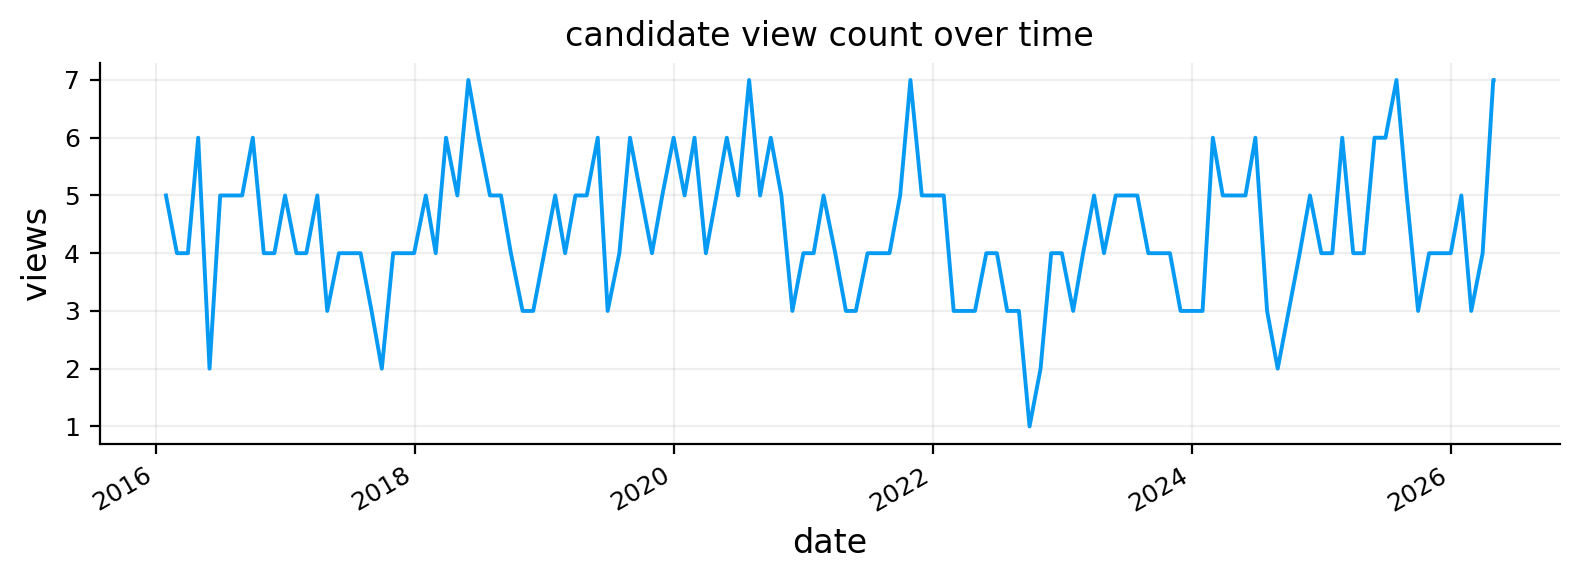

,view_family,view_name,long_assets,short_assets,signal_value,q_tilt,confluence_score,economic_priority,risk_orientation,diagnostics
0,dual_momentum,Dual momentum,"[DBC, GLD, EEM, IWM]","[TLT, LQD]",1.7715,0.0196,0.7086,0.85,neutral,"{'dual_dispersion': 1.356483128543048, 'long_s..."
1,reflation_breadth,Reflation breadth,"[IWM, HYG, VNQ, DBC, EEM]","[SHY, IEF, AGG, GLD]",1.3967,0.0339,0.6983,0.78,risk_on,"{'iwm_spy_63': 0.03322394644058324, 'hyg_lqd_6..."
2,international_rotation,International rotation,[EEM],[EFA],1.2315,0.0136,0.6158,0.72,risk_on,"{'eem_efa_63': 0.07160985901167893, 'dollar_tr..."
3,inflation_rotation,Inflation rotation,"[DBC, GLD]","[TLT, LQD, IEF, AGG]",1.5712,0.0204,0.5029,0.80,neutral,"{'commodity_score': 1.007280659722617, 'durati..."
4,risk_adj_momentum,Risk-adjusted momentum,"[DBC, EEM, IWM, QQQ]","[TLT, IEF, LQD, AGG]",0.9988,0.0093,0.3995,1.00,neutral,"{'risk_adj_dispersion': 0.6934411211187503, 'l..."
5,liquid_leadership,Liquidity leadership,"[QQQ, SPY]","[HYG, VNQ]",0.3329,0.0109,0.1665,0.90,risk_on,"{'leadership_spread': 0.3980206952657629, 'cyc..."
6,duration_quality,Duration quality,"[SHY, AGG, IEF]",[TLT],0.2180,0.0017,0.1090,0.70,risk_off,"{'tlt_trend_200': -0.010226109945979278, 'ief_..."


,active_count,avg_q_tilt,avg_abs_q_tilt,avg_signal_strength
view_family,,,,
risk_adj_momentum,125,0.0123,0.0123,1.8257
dual_momentum,118,0.0191,0.0191,1.7699
duration_quality,78,0.0042,0.0042,0.6185
credit_switch,58,0.0069,0.0069,1.1253
liquid_leadership,51,0.0209,0.0209,0.7422
international_rotation,46,0.0117,0.0117,1.0113
growth_duration,28,0.0168,0.0168,0.7771
reflation_breadth,22,0.0318,0.0318,1.3210
inflation_rotation,21,0.0152,0.0152,0.9968


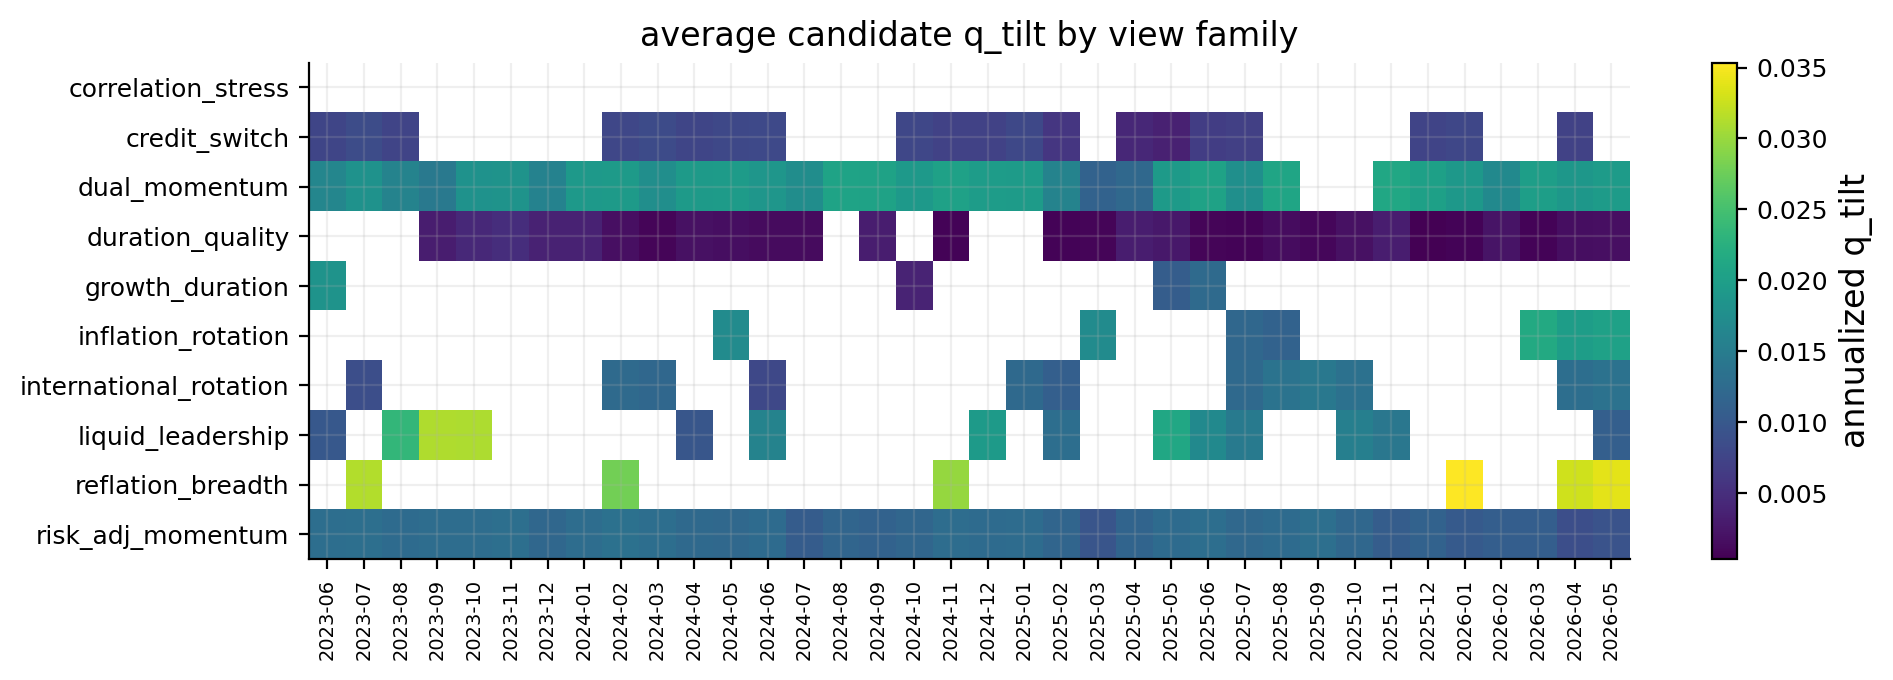

In [21]:
view_cache = {}
view_log_rows = []
for dt in rebalance_dates:
    dt = pd.Timestamp(dt)
    signal_table, market_state = compute_asset_signals(signal_close, signal_returns, dt, dividends=dividends_all)
    cov_ann = cov_by_date[dt].loc[assets, assets]
    simple_views = make_simple_interpretable_views(signal_table, market_state, cov_ann=cov_ann)
    systematic_signals = make_systematic_signal_table(signal_table, market_state)
    systematic_views = make_systematic_views(signal_table, market_state, simple_views)
    active_views = combine_and_rank_views(simple_views, systematic_views)
    view_cache[dt] = {
        "asset_signal_table": signal_table,
        "market_state": market_state,
        "simple_views": simple_views,
        "systematic_signals": systematic_signals,
        "systematic_views": systematic_views,
        "active_views": active_views,
    }
    for row in active_views:
        rec = dict(row)
        rec["date"] = dt
        view_log_rows.append(rec)
view_preview_log = pd.DataFrame(view_log_rows)
active_count_series = view_preview_log.groupby("date").size().reindex(rebalance_dates, fill_value=0) if not view_preview_log.empty else pd.Series(0, index=rebalance_dates)
ax = active_count_series.plot(figsize=(8, 3), lw=1.4)
ax.set_title("candidate view count over time")
ax.set_ylabel("views")
ax.set_xlabel("date")
plt.tight_layout(); plt.show()
latest_active_views = view_cache[pd.Timestamp(latest_rebalance_date)]["active_views"]
latest_active_table = pd.DataFrame(latest_active_views)
if not latest_active_table.empty:
    display(latest_active_table[["view_family", "view_name", "long_assets", "short_assets", "signal_value", "q_tilt", "confluence_score", "economic_priority", "risk_orientation", "diagnostics"]].round(4))
else:
    print("no candidate views on the latest rebalance date")
if not view_preview_log.empty:
    family_frequency = view_preview_log.groupby("view_family").agg(
        active_count=("view_name", "size"),
        avg_q_tilt=("q_tilt", "mean"),
        avg_abs_q_tilt=("q_tilt", lambda x: np.mean(np.abs(x))),
        avg_signal_strength=("signal_value", lambda x: np.mean(np.abs(x))),
    ).sort_values("active_count", ascending=False)
    display(family_frequency.round(4))
    q_heatmap = view_preview_log.groupby(["view_family", "date"])["q_tilt"].mean().unstack().iloc[:, -36:]
    fig, ax = plt.subplots(figsize=(10, max(3, 0.35 * len(q_heatmap))))
    im = ax.imshow(q_heatmap, aspect="auto", cmap="viridis")
    ax.set_title("average candidate q_tilt by view family")
    ax.set_yticks(range(len(q_heatmap.index)), q_heatmap.index)
    ax.set_xticks(range(len(q_heatmap.columns)), [d.strftime("%Y-%m") for d in q_heatmap.columns], rotation=90, fontsize=7)
    fig.colorbar(im, ax=ax, label="annualized q_tilt")
    plt.tight_layout(); plt.show()


In [22]:
def reliability_score_for_q(stats):
    hit_rate = stats.get("hit_rate", np.nan)
    recent_hit_rate = stats.get("recent_hit_rate", np.nan)
    payoff_ir = stats.get("payoff_ir", np.nan)
    sample_score = stats.get("sample_score", 0.0)
    hit_component = np.clip(((hit_rate if np.isfinite(hit_rate) else 0.50) - 0.50) / 0.15, 0.0, 1.0)
    recent_component = np.clip(((recent_hit_rate if np.isfinite(recent_hit_rate) else hit_rate) - 0.50) / 0.20, 0.0, 1.0)
    ir_component = np.clip((payoff_ir if np.isfinite(payoff_ir) else 0.0) / 0.30, 0.0, 1.0)
    return float(np.clip(0.35 * hit_component + 0.25 * recent_component + 0.25 * ir_component + 0.15 * sample_score, 0.0, 1.0))


def reliability_q_multiplier(stats):
    n_obs = stats.get("n_obs", 0)
    hit_rate = stats.get("hit_rate", np.nan)
    recent_hit_rate = stats.get("recent_hit_rate", np.nan)
    payoff_ir = stats.get("payoff_ir", np.nan)

    if n_obs < 8:
        return 0.60

    mult = 1.00
    if np.isfinite(hit_rate):
        if hit_rate < 0.48:
            mult *= 0.60
        elif hit_rate < 0.52:
            mult *= 0.80
        elif hit_rate > 0.58:
            mult *= 1.10
    if np.isfinite(payoff_ir):
        if payoff_ir < -0.10:
            mult *= 0.50
        elif payoff_ir <= 0.03:
            mult *= 0.75
        elif payoff_ir > 0.20:
            mult *= 1.15
    if np.isfinite(recent_hit_rate):
        if recent_hit_rate < 0.35:
            mult *= 0.75
        elif recent_hit_rate > 0.65:
            mult *= 1.10
    return float(np.clip(mult, 0.35, 1.25))


def learned_q_for_row(row, raw_q, payoff_history, current_date, use_learned_q=True):
    cap = family_q_caps.get(row.get("view_family"), 0.020)
    stats = family_reliability_stats(row.get("view_family"), payoff_history, current_date) if current_date is not None else family_reliability_stats(row.get("view_family"), pd.DataFrame(), pd.Timestamp("1900-01-01"))
    raw_q = float(np.clip(abs(raw_q), 0.0, cap))
    learned_component = 0.0
    q_final = raw_q
    q_model = "rule q only"
    if use_learned_q:
        mult = reliability_q_multiplier(stats)
        q_final = float(np.clip(raw_q * mult, 0.0, cap))
        learned_component = q_final - raw_q
        q_model = "soft reliability scaled q"
    q_shrinkage_or_boost = (q_final / raw_q - 1.0) if raw_q > 1e-12 else np.nan
    return q_final, learned_component, q_shrinkage_or_boost, q_model, stats


def build_view_matrix(active_views, assets, prior_mu=None, payoff_history=None, current_date=None, use_learned_q=True):
    clean_rows, view_p_rows, view_q_vals = [], [], []
    asset_index = {asset: i for i, asset in enumerate(assets)}
    prior = pd.Series(prior_mu, index=assets, dtype=float).reindex(assets).fillna(0.0) if prior_mu is not None else pd.Series(0.0, index=assets)
    for row in active_views:
        long_assets = [x for x in row.get("long_assets", []) if x in asset_index]
        short_assets = [x for x in row.get("short_assets", []) if x in asset_index]
        if not long_assets or not short_assets:
            continue
        p_row = np.zeros(len(assets), dtype=float)
        for asset in long_assets:
            p_row[asset_index[asset]] += 1.0 / len(long_assets)
        for asset in short_assets:
            p_row[asset_index[asset]] -= 1.0 / len(short_assets)
        if abs(p_row.sum()) > 1e-8:
            print("warning: p row does not sum close to zero", row.get("view_name"), p_row.sum())
        tilt_cap = family_q_caps.get(row.get("view_family"), 0.020)
        view_strength = float(abs(row.get("view_strength", row.get("signal_value", 0.0))))
        raw_q_tilt = float(np.clip(abs(row.get("q_tilt", tilt_cap * math.tanh(view_strength / q_strength_scale))), 0.0, tilt_cap))
        q_tilt_final, learned_q_component, q_shrinkage_or_boost, q_model, stats = learned_q_for_row(row, raw_q_tilt, payoff_history, current_date, use_learned_q=use_learned_q)
        if use_learned_q and q_tilt_final <= 1e-10:
            continue
        base_view_spread = float(p_row @ prior.values)
        q_val = base_view_spread + q_tilt_final
        expression_parts = [f"{1.0 / len(long_assets):.2f}*{asset}" for asset in long_assets] + [f"-{1.0 / len(short_assets):.2f}*{asset}" for asset in short_assets]
        rec = dict(row)
        rec["economic_theme"] = view_theme(rec)
        rec["base_view_spread"] = base_view_spread
        rec["raw_q"] = raw_q_tilt
        rec["raw_q_tilt"] = raw_q_tilt
        rec["learned_q_component"] = learned_q_component
        rec["final_q"] = q_tilt_final
        rec["q_tilt"] = q_tilt_final
        rec["q_tilt_final"] = q_tilt_final
        rec["q"] = q_val
        rec["q_model"] = q_model
        rec["q_shrinkage_or_boost"] = q_shrinkage_or_boost
        rec["q_shrink"] = raw_q_tilt - q_tilt_final
        rec["q_n_obs"] = stats.get("n_obs", np.nan)
        rec["q_hit_rate"] = stats.get("hit_rate", np.nan)
        rec["q_recent_hit_rate"] = stats.get("recent_hit_rate", np.nan)
        rec["q_payoff_ir"] = stats.get("payoff_ir", np.nan)
        rec["q_avg_payoff"] = stats.get("avg_payoff", np.nan)
        rec["q_t_stat"] = stats.get("t_stat", np.nan)
        rec["q_info_coefficient"] = stats.get("info_coefficient", np.nan)
        rec["p_expression"] = " + ".join(expression_parts).replace("+ -", "- ")
        rec["p_vector"] = pd.Series(p_row, index=assets).round(6).to_dict()
        clean_rows.append(rec)
        view_p_rows.append(p_row)
        view_q_vals.append(q_val)
    view_p = np.vstack(view_p_rows) if view_p_rows else np.empty((0, len(assets)))
    view_q = np.asarray(view_q_vals, dtype=float)
    clean_view_table = pd.DataFrame(clean_rows)
    assert view_p.shape[1] == len(assets)
    return view_p, view_q, clean_view_table


latest_view_p, latest_view_q, latest_clean_view_table = build_view_matrix(latest_active_views, assets, prior_mu_by_date[pd.Timestamp(latest_rebalance_date)], use_learned_q=False)
print("view_p shape:", latest_view_p.shape, "view_q shape:", latest_view_q.shape)
if not latest_clean_view_table.empty:
    display(latest_clean_view_table[["view_family", "family_display_name", "view_name", "view_state", "long_assets", "short_assets", "base_view_spread", "raw_q", "final_q", "q", "confidence", "p_expression", "diagnostics"]].round(4))
    latest_p_table = pd.DataFrame(latest_view_p, columns=assets, index=latest_clean_view_table["view_family"])
    display(latest_p_table.round(3))

view_p shape: (7, 14) view_q shape: (7,)


,view_family,family_display_name,view_name,view_state,long_assets,short_assets,base_view_spread,raw_q,final_q,q,confidence,p_expression,diagnostics
0,dual_momentum,Dual momentum,Dual momentum,trend_following,"[DBC, GLD, EEM, IWM]","[TLT, LQD]",0.0696,0.0196,0.0196,0.0892,NaN,0.25*DBC + 0.25*GLD + 0.25*EEM + 0.25*IWM - 0....,"{'dual_dispersion': 1.356483128543048, 'long_s..."
1,reflation_breadth,Reflation breadth,Reflation breadth,broad_reflation,"[IWM, HYG, VNQ, DBC, EEM]","[SHY, IEF, AGG, GLD]",0.0249,0.0339,0.0339,0.0588,NaN,0.20*IWM + 0.20*HYG + 0.20*VNQ + 0.20*DBC + 0....,"{'iwm_spy_63': 0.03322394644058324, 'hyg_lqd_6..."
2,international_rotation,International rotation,International rotation,em_leadership,[EEM],[EFA],0.0486,0.0136,0.0136,0.0622,NaN,1.00*EEM - 1.00*EFA,"{'eem_efa_63': 0.07160985901167893, 'dollar_tr..."
3,inflation_rotation,Inflation rotation,Inflation rotation,inflation_shock,"[DBC, GLD]","[TLT, LQD, IEF, AGG]",0.0060,0.0204,0.0204,0.0264,NaN,0.50*DBC + 0.50*GLD - 0.25*TLT - 0.25*LQD - 0....,"{'commodity_score': 1.007280659722617, 'durati..."
4,risk_adj_momentum,Risk-adjusted momentum,Risk-adjusted momentum,quality_momentum,"[DBC, EEM, IWM, QQQ]","[TLT, IEF, LQD, AGG]",0.0718,0.0093,0.0093,0.0811,NaN,0.25*DBC + 0.25*EEM + 0.25*IWM + 0.25*QQQ - 0....,"{'risk_adj_dispersion': 0.6934411211187503, 'l..."
5,liquid_leadership,Liquidity leadership,Liquidity leadership,narrow_leadership,"[QQQ, SPY]","[HYG, VNQ]",0.0674,0.0109,0.0109,0.0784,NaN,0.50*QQQ + 0.50*SPY - 0.50*HYG - 0.50*VNQ,"{'leadership_spread': 0.3980206952657629, 'cyc..."
6,duration_quality,Duration quality,Duration quality,short_duration_quality,"[SHY, AGG, IEF]",[TLT],-0.0196,0.0017,0.0017,-0.0178,NaN,0.33*SHY + 0.33*AGG + 0.33*IEF - 1.00*TLT,"{'tlt_trend_200': -0.010226109945979278, 'ief_..."


,SPY,QQQ,IWM,EFA,EEM,TLT,IEF,SHY,AGG,LQD,HYG,GLD,VNQ,DBC
view_family,,,,,,,,,,,,,,
dual_momentum,0.0,0.00,0.25,0.0,0.25,-0.50,0.000,0.000,0.000,-0.50,0.0,0.25,0.0,0.25
reflation_breadth,0.0,0.00,0.20,0.0,0.20,0.00,-0.250,-0.250,-0.250,0.00,0.2,-0.25,0.2,0.20
international_rotation,0.0,0.00,0.00,-1.0,1.00,0.00,0.000,0.000,0.000,0.00,0.0,0.00,0.0,0.00
inflation_rotation,0.0,0.00,0.00,0.0,0.00,-0.25,-0.250,0.000,-0.250,-0.25,0.0,0.50,0.0,0.50
risk_adj_momentum,0.0,0.25,0.25,0.0,0.25,-0.25,-0.250,0.000,-0.250,-0.25,0.0,0.00,0.0,0.25
liquid_leadership,0.5,0.50,0.00,0.0,0.00,0.00,0.000,0.000,0.000,0.00,-0.5,0.00,-0.5,0.00
duration_quality,0.0,0.00,0.00,0.0,0.00,-1.00,0.333,0.333,0.333,0.00,0.0,0.00,0.0,0.00


In [23]:
view_horizon_days = 21


def p_row_from_view(row, assets):
    return p_series_from_assets(row.get("long_assets", []), row.get("short_assets", []), list(assets))


def stress_state_from_market_state(market_state):
    spy_dd = state_value(market_state, "spy_drawdown_252", 0.0)
    spy_vol_z = state_value(market_state, "spy_vol_z", 0.0)
    breadth = state_value(market_state, "risky_trend_breadth")
    credit = state_value(market_state, "hyg_lqd_63", 0.0)
    return bool((np.isfinite(spy_dd) and spy_dd < -0.08) or spy_vol_z > 0.80 or (np.isfinite(breadth) and breadth < 0.45) or credit < -0.020)


def build_view_payoff_history(view_log, returns, horizon=view_horizon_days):
    if view_log.empty:
        return pd.DataFrame()
    rows = []
    for _, row in view_log.iterrows():
        dt = pd.Timestamp(row["date"])
        pos = returns.index.searchsorted(dt, side="right") - 1
        if pos < 0 or pos + horizon >= len(returns.index):
            continue
        forward_asset_return = (1.0 + returns.iloc[pos + 1:pos + horizon + 1]).prod() - 1.0
        p = p_row_from_view(row, returns.columns)
        if p is None:
            continue
        payoff_horizon = float(p @ forward_asset_return.reindex(p.index).fillna(0.0))
        payoff_ann = float(np.log1p(np.clip(payoff_horizon, -0.95, None)) * annualization / horizon)
        market_state_t = view_cache.get(dt, {}).get("market_state", {}) if "view_cache" in globals() else {}
        stress_state = stress_state_from_market_state(market_state_t) if market_state_t else False
        rows.append({
            "date": dt,
            "payoff_end_date": returns.index[pos + horizon],
            "view_family": row["view_family"],
            "family_name": row.get("family_name", family_display_names.get(row["view_family"], row["view_family"])),
            "family_display_name": row.get("family_display_name", family_display_names.get(row["view_family"], row["view_family"])),
            "view_name": row["view_name"],
            "view_state": row.get("view_state", row.get("risk_orientation", "neutral")),
            "economic_theme": view_theme(row),
            "signal_value": row["signal_value"],
            "raw_strength": row.get("raw_strength", abs(row["signal_value"])),
            "signal_strength": abs(row["signal_value"]),
            "q_tilt": row.get("q_tilt", np.nan),
            "q": row.get("q", np.nan),
            "payoff_horizon": payoff_horizon,
            "payoff_ann": payoff_ann,
            "payoff": payoff_ann,
            "hit": payoff_horizon > 0,
            "risk_orientation": row["risk_orientation"],
            "economic_label": row["economic_label"],
            "spy_drawdown_252": market_state_t.get("spy_drawdown_252", np.nan),
            "spy_vol_z": market_state_t.get("spy_vol_z", np.nan),
            "risky_trend_breadth": market_state_t.get("risky_trend_breadth", np.nan),
            "hyg_lqd_63": market_state_t.get("hyg_lqd_63", np.nan),
            "stress_state": stress_state,
            "diagnostics": row.get("diagnostics", {}),
            "p_vector": p.round(6).to_dict(),
        })
    return pd.DataFrame(rows)


all_payoff_history = build_view_payoff_history(view_preview_log, returns[assets])
print("payoff observations:", len(all_payoff_history))
print("confidence and learned Q use only payoff observations whose payoff_end_date is before the rebalance date")

confidence_preview_rows = []
for mode in ["fixed", "learned", "haircut"]:
    for row in latest_active_views:
        details = confidence_for_view(row, all_payoff_history, latest_rebalance_date, latest_market_state, mode)
        confidence_preview_rows.append({"date": pd.Timestamp(latest_rebalance_date), "view_family": row["view_family"], "view_name": row["view_name"], "confidence_mode": "full_" + mode, "confidence": details["confidence"], "hit_rate": details["hit_rate"], "recent_hit_rate": details["recent_hit_rate"], "payoff_ir": details["payoff_ir"], "stress_hit_rate": details.get("stress_hit_rate", np.nan), "stress_payoff_ir": details.get("stress_payoff_ir", np.nan), "t_stat": details["t_stat"], "info_coefficient": details["info_coefficient"], "n_obs": details["n_obs"], "haircut_multiplier": details["haircut_multiplier"], "risk_orientation": details["risk_orientation"]})
for mode in ["learned", "haircut"]:
    selected_preview, _ = select_selected_views(latest_active_views, all_payoff_history, latest_rebalance_date, latest_market_state, mode)
    for row in selected_preview:
        details = confidence_for_view(row, all_payoff_history, latest_rebalance_date, latest_market_state, mode)
        confidence_preview_rows.append({"date": pd.Timestamp(latest_rebalance_date), "view_family": row["view_family"], "view_name": row["view_name"], "confidence_mode": "selected_" + mode, "confidence": details["confidence"], "hit_rate": details["hit_rate"], "recent_hit_rate": details["recent_hit_rate"], "payoff_ir": details["payoff_ir"], "stress_hit_rate": details.get("stress_hit_rate", np.nan), "stress_payoff_ir": details.get("stress_payoff_ir", np.nan), "t_stat": details["t_stat"], "info_coefficient": details["info_coefficient"], "n_obs": details["n_obs"], "haircut_multiplier": details["haircut_multiplier"], "risk_orientation": details["risk_orientation"]})
confidence_preview = pd.DataFrame(confidence_preview_rows)
if not confidence_preview.empty:
    display(confidence_preview.groupby(["confidence_mode", "view_family"])["confidence"].mean().unstack(0).round(4))

payoff observations: 537
confidence and learned Q use only payoff observations whose payoff_end_date is before the rebalance date


confidence_mode,full_fixed,full_haircut,full_learned,selected_haircut,selected_learned
view_family,,,,,
dual_momentum,0.5,0.5942,0.5942,0.5942,0.5942
duration_quality,0.5,0.2000,0.3000,NaN,NaN
inflation_rotation,0.5,0.4873,0.4873,0.4873,0.4873
international_rotation,0.5,0.3131,0.3131,NaN,NaN
liquid_leadership,0.5,0.6194,0.6194,0.6194,0.6194
reflation_breadth,0.5,0.3150,0.4200,0.3150,0.4200
risk_adj_momentum,0.5,0.5226,0.5226,0.5226,0.5226


In [24]:
tau = 0.05
use_empirical_omega_rescale = False


def empirical_view_variance(view_family, payoff_history, current_date):
    if payoff_history is None or len(payoff_history) == 0:
        return np.nan, 0
    sample = payoff_history[(payoff_history["view_family"] == view_family) & (payoff_history["payoff_end_date"] < pd.Timestamp(current_date))].copy()
    payoff_col = "payoff_ann" if "payoff_ann" in sample.columns else "payoff"
    x = pd.to_numeric(sample.get(payoff_col, pd.Series(dtype=float)), errors="coerce").dropna()
    if len(x) < 8:
        return np.nan, int(len(x))
    return float(x.var(ddof=1)), int(len(x))


def omega_from_confidence(view_p, cov_ann, confidence, active_view_rows=None, payoff_history=None, current_date=None, full_view_cov=True):
    if len(confidence) == 0 or view_p.shape[0] == 0:
        return np.empty((0, 0)), np.array([])
    conf = np.asarray(confidence, dtype=float)
    conf = np.where(np.isfinite(conf), conf, 0.50)
    conf = np.maximum(conf, 1e-4)
    cov_arr = np.asarray(cov_ann, dtype=float)
    view_cov = view_p @ cov_arr @ view_p.T
    view_cov = 0.5 * (view_cov + view_cov.T)
    view_var = np.maximum(np.diag(view_cov), 1e-8)
    scale = np.sqrt((1.0 - conf) / conf)
    base_omega = tau * np.diag(scale) @ view_cov @ np.diag(scale)
    base_omega = 0.5 * (base_omega + base_omega.T) + np.eye(len(conf)) * 1e-8
    base_diag = np.maximum(np.diag(base_omega), 1e-10)
    target_diag = base_diag.copy()
    if use_empirical_omega_rescale and active_view_rows is not None and payoff_history is not None and current_date is not None:
        for i, row in enumerate(active_view_rows):
            emp_var, n_obs = empirical_view_variance(row.get("view_family"), payoff_history, current_date)
            if np.isfinite(emp_var) and emp_var > 1e-10:
                sample_weight = min(0.50, n_obs / 48.0)
                target_diag[i] = (1.0 - sample_weight) * base_diag[i] + sample_weight * emp_var
    try:
        rescale = np.sqrt(np.maximum(target_diag, 1e-10) / base_diag)
        omega = np.diag(rescale) @ base_omega @ np.diag(rescale)
        omega = 0.5 * (omega + omega.T) + np.eye(len(conf)) * 1e-8
        if np.all(np.isfinite(omega)):
            return omega, view_var
    except Exception:
        pass
    return np.diag(np.maximum(target_diag, 1e-8)), view_var


if latest_view_p.shape[0] > 0:
    learned_conf = [confidence_for_view(row, all_payoff_history, latest_rebalance_date, latest_market_state, "learned")["confidence"] for row in latest_clean_view_table.to_dict("records")]
    latest_omega, latest_view_var = omega_from_confidence(latest_view_p, cov_by_date[pd.Timestamp(latest_rebalance_date)].loc[assets, assets], learned_conf, active_view_rows=latest_clean_view_table.to_dict("records"), payoff_history=all_payoff_history, current_date=latest_rebalance_date)
    omega_table = latest_clean_view_table[["view_name", "view_family", "raw_q", "learned_q_component", "final_q", "q"]].copy()
    omega_table["confidence"] = learned_conf
    omega_table["view_variance"] = latest_view_var
    omega_table["omega_diag"] = np.diag(latest_omega)
    display(omega_table.round(6))
    print("omega uses confidence-based full view covariance; learned Q is applied when build_view_matrix is called with use_learned_q=True")
else:
    print("no active views for omega display")

,view_name,view_family,raw_q,learned_q_component,final_q,q,confidence,view_variance,omega_diag
0,Dual momentum,dual_momentum,0.019558,0.0,0.019558,0.089174,0.594198,0.024714,0.000844
1,Reflation breadth,reflation_breadth,0.033879,0.0,0.033879,0.058752,0.420000,0.007321,0.000505
2,International rotation,international_rotation,0.013596,0.0,0.013596,0.062218,0.313130,0.014962,0.001641
3,Inflation rotation,inflation_rotation,0.020405,0.0,0.020405,0.026418,0.487302,0.045933,0.002416
4,Risk-adjusted momentum,risk_adj_momentum,0.009289,0.0,0.009289,0.081132,0.522604,0.017509,0.000800
5,Liquidity leadership,liquid_leadership,0.010930,0.0,0.010930,0.078368,0.619355,0.017489,0.000537
6,Duration quality,duration_quality,0.001726,0.0,0.001726,-0.017848,0.300000,0.003988,0.000465


omega uses confidence-based full view covariance; learned Q is applied when build_view_matrix is called with use_learned_q=True


In [25]:
def black_litterman_posterior(prior_mu, cov_ann, view_p, view_q, omega, tau=tau):
    prior_mu = pd.Series(prior_mu).astype(float)
    cov_ann = pd.DataFrame(cov_ann, index=prior_mu.index, columns=prior_mu.index).astype(float)
    diag = {"n_views": int(view_p.shape[0]), "avg_confidence": np.nan, "max_confidence": np.nan, "min_confidence": np.nan, "max_abs_q": float(np.max(np.abs(view_q))) if len(view_q) else 0.0, "max_abs_posterior_shift": 0.0, "condition_number": np.nan, "no_views": view_p.shape[0] == 0, "failure": False, "clipped": False}
    if view_p.shape[0] == 0:
        return prior_mu.copy(), cov_ann.copy(), diag
    try:
        cov_arr = make_psd_df(cov_ann.values, cov_ann.index).values
        tau_cov = tau * cov_arr
        omega_arr = np.asarray(omega, dtype=float)
        omega_arr = 0.5 * (omega_arr + omega_arr.T) + np.eye(view_p.shape[0]) * 1e-8
        middle = view_p @ tau_cov @ view_p.T + omega_arr
        middle = 0.5 * (middle + middle.T) + np.eye(view_p.shape[0]) * 1e-10
        view_gap = view_q - view_p @ prior_mu.values
        diag["condition_number"] = float(np.linalg.cond(middle))
        solved_gap = np.linalg.solve(middle, view_gap)
        post_mu_arr = prior_mu.values + tau_cov @ view_p.T @ solved_gap
        solved_cov = np.linalg.solve(middle, view_p @ tau_cov)
        posterior_uncertainty = tau_cov - tau_cov @ view_p.T @ solved_cov
        post_cov_arr = local_make_psd(cov_arr + posterior_uncertainty)
        clipped = np.any((post_mu_arr < -0.30) | (post_mu_arr > 0.30))
        post_mu_arr = np.clip(post_mu_arr, -0.30, 0.30)
        post_mu = pd.Series(post_mu_arr, index=prior_mu.index)
        post_cov = pd.DataFrame(post_cov_arr, index=prior_mu.index, columns=prior_mu.index)
        diag["clipped"] = bool(clipped)
        diag["max_abs_posterior_shift"] = float(np.max(np.abs(post_mu.values - prior_mu.values)))
        return post_mu, post_cov, diag
    except Exception:
        diag["failure"] = True
        return prior_mu.copy(), cov_ann.copy(), diag

def diagnostic_bl_weights(post_mu, post_cov, delta_t):
    try:
        raw = pd.Series(np.linalg.solve(delta_t * post_cov.values, post_mu.values), index=post_mu.index)
        return normalize_box_weights(raw.clip(lower=0.0), post_mu.index, lower=w_min, upper=w_max)
    except Exception:
        return benchmark_w.copy()

if latest_view_p.shape[0] > 0:
    post_mu_sample, post_cov_sample, post_diag_sample = black_litterman_posterior(prior_mu_by_date[pd.Timestamp(latest_rebalance_date)], cov_by_date[pd.Timestamp(latest_rebalance_date)].loc[assets, assets], latest_view_p, latest_view_q, latest_omega)
else:
    post_mu_sample, post_cov_sample, post_diag_sample = black_litterman_posterior(prior_mu_by_date[pd.Timestamp(latest_rebalance_date)], cov_by_date[pd.Timestamp(latest_rebalance_date)].loc[assets, assets], latest_view_p, latest_view_q, np.empty((0, 0)))
prior_post_table = pd.DataFrame({"asset": assets, "prior_mu": prior_mu_by_date[pd.Timestamp(latest_rebalance_date)].reindex(assets).values, "post_mu": post_mu_sample.reindex(assets).values, "shift": post_mu_sample.reindex(assets).values - prior_mu_by_date[pd.Timestamp(latest_rebalance_date)].reindex(assets).values}).sort_values("shift", ascending=False)
display(prior_post_table.round(4))
diagnostic_w = diagnostic_bl_weights(post_mu_sample, post_cov_sample, delta_by_date[pd.Timestamp(latest_rebalance_date)])
display(pd.DataFrame({"asset": diagnostic_w.index, "diagnostic_bl_implied_weight": diagnostic_w.values}).sort_values("diagnostic_bl_implied_weight", ascending=False).round(4))
print(post_diag_sample)


,asset,prior_mu,post_mu,shift
11,GLD,0.1525,0.3000,0.1475
13,DBC,-0.0793,0.0168,0.0961
4,EEM,0.2038,0.2946,0.0908
1,QQQ,0.1370,0.1872,0.0502
0,SPY,0.1109,0.1467,0.0357
3,EFA,0.1552,0.1830,0.0278
2,IWM,0.1483,0.1743,0.0260
10,HYG,0.0361,0.0389,0.0028
6,IEF,0.0255,0.0274,0.0019
7,SHY,0.0077,0.0095,0.0018


,asset,diagnostic_bl_implied_weight
0,SPY,0.1921
4,EEM,0.1921
8,AGG,0.1921
13,DBC,0.1921
6,IEF,0.1921
2,IWM,0.0302
11,GLD,0.0095
5,TLT,0.0000
1,QQQ,0.0000
3,EFA,0.0000


{'n_views': 7, 'avg_confidence': nan, 'max_confidence': nan, 'min_confidence': nan, 'max_abs_q': 0.08917445627697065, 'max_abs_posterior_shift': 0.14746388981351133, 'condition_number': 1465.5038944376747, 'no_views': False, 'failure': False, 'clipped': True}


In [26]:
active_weight_limit = 0.15
active_weight_relaxed = 0.22
gamma_te = 3.0
active_te_target = 0.05


def clean_bl_weight_array(weights, index, previous=None):
    caps = asset_caps.reindex(index).fillna(w_max)
    if weights is None:
        weights = previous if previous is not None else benchmark_w.reindex(index).values
    w = pd.Series(np.asarray(weights, dtype=float).reshape(-1), index=index)
    if len(w) != len(index) or not np.all(np.isfinite(w)):
        w = pd.Series(previous, index=index) if previous is not None else benchmark_w.reindex(index).fillna(0.0)
    w = w.clip(lower=w_min, upper=caps)
    if w.sum() <= 1e-12:
        w = benchmark_w.reindex(index).fillna(0.0).clip(upper=caps)
    w = w / w.sum()
    for _ in range(100):
        over = w > caps + 1e-12
        if not over.any():
            break
        extra = float((w[over] - caps[over]).sum())
        w[over] = caps[over]
        room = (caps[~over] - w[~over]).clip(lower=0.0)
        if room.sum() <= 1e-12:
            break
        w.loc[room.index] += extra * room / room.sum()
    w = w.clip(lower=w_min, upper=caps)
    return (w / w.sum()).to_numpy(dtype=float)


def cvxpy_bl_optimizer(mu, cov_ann, w_prev=None, risk_aversion=None, active_limit=active_weight_limit, use_sleeves=True, te_gamma=0.0):
    if cp is None:
        return None
    index = list(mu.index)
    n = len(index)
    w_var = cp.Variable(n)
    cov_arr = local_make_psd(cov_ann.values + np.eye(n) * 1e-8)
    caps = asset_caps.reindex(index).fillna(w_max).to_numpy(dtype=float)
    bench = benchmark_w.reindex(index).fillna(0.0).to_numpy(dtype=float)
    prev = np.asarray(w_prev if w_prev is not None else bench, dtype=float)
    risk_aversion = float(delta_fallback if risk_aversion is None or not np.isfinite(risk_aversion) else risk_aversion)
    turnover_penalty = cost_bps / 10000.0 * cp.norm1(w_var - prev)
    te_penalty = te_gamma * cp.quad_form(w_var - bench, cov_arr) if te_gamma and te_gamma > 0 else 0.0
    objective = cp.Maximize(mu.values @ w_var - 0.5 * risk_aversion * cp.quad_form(w_var, cov_arr) - turnover_penalty - te_penalty)
    constraints = [cp.sum(w_var) == 1.0, w_var >= w_min, w_var <= caps]
    if active_limit is not None:
        constraints += [w_var - bench <= active_limit, bench - w_var <= active_limit]
    if use_sleeves:
        for sleeve, spec in sleeve_constraints.items():
            locs = [index.index(asset) for asset in spec["assets"] if asset in index]
            if locs:
                sleeve_weight = cp.sum(w_var[locs])
                constraints += [sleeve_weight >= spec["min"], sleeve_weight <= spec["max"]]
    problem = cp.Problem(objective, constraints)
    for solver in ["CLARABEL", "OSQP", "ECOS", "SCS"]:
        try:
            problem.solve(solver=solver, verbose=False)
            if w_var.value is not None and problem.status in ["optimal", "optimal_inaccurate"]:
                return np.asarray(w_var.value, dtype=float)
        except Exception:
            continue
    return None


def optimize_bl_weights(post_mu, post_cov, w_prev=None, risk_aversion=None):
    attempts = [
        {"active_limit": active_weight_limit, "use_sleeves": True, "te_gamma": 0.0},
        {"active_limit": active_weight_relaxed, "use_sleeves": True, "te_gamma": 0.0},
        {"active_limit": active_weight_limit, "use_sleeves": False, "te_gamma": 0.0},
        {"active_limit": active_weight_relaxed, "use_sleeves": False, "te_gamma": 0.0},
        {"active_limit": None, "use_sleeves": False, "te_gamma": gamma_te},
    ]
    for attempt in attempts:
        w = cvxpy_bl_optimizer(post_mu, post_cov, w_prev=w_prev, risk_aversion=risk_aversion, **attempt)
        if w is not None:
            return clean_bl_weight_array(w, post_mu.index, previous=w_prev), False, attempt
    previous = w_prev if w_prev is not None else benchmark_w.reindex(post_mu.index).values
    return clean_bl_weight_array(previous, post_mu.index, previous=previous), True, {"active_limit": None, "use_sleeves": False, "te_gamma": np.nan}

In [27]:
bl_modes = {
    "Learned-Confidence BL": {"view_set": "selected", "confidence_mode": "learned"},
}
bl_weight_rows = {name: [] for name in bl_modes}
bl_fallback_rows = {name: [] for name in bl_modes}
bl_prev_weights = {name: None for name in bl_modes}
confidence_log_rows = []
posterior_log_rows = []
candidate_view_log_rows = []
selected_view_log_rows = []
selection_log_rows = []
post_mu_store = {}
post_cov_store = {}

for i, dt in enumerate(rebalance_dates[:-1]):
    dt = pd.Timestamp(dt)
    cache = view_cache[dt]
    candidate_views = cache["active_views"]
    market_state = cache["market_state"]
    prior_mu = prior_mu_by_date[dt].reindex(assets)
    cov_ann = cov_by_date[dt].loc[assets, assets]
    risk_aversion_t = delta_by_date[dt]
    payoff_history_now = all_payoff_history[all_payoff_history["payoff_end_date"] < dt].copy() if not all_payoff_history.empty else pd.DataFrame()
    if candidate_views:
        candidate_view_log_rows.extend(pd.DataFrame(candidate_views).assign(date=dt, view_set="candidate").to_dict("records"))

    selected_views, scale_rows = select_selected_views(candidate_views, payoff_history_now, dt, market_state, "learned")
    selection_log_rows.extend(scale_rows)
    view_p, view_q, clean_table = build_view_matrix(selected_views, assets, prior_mu, payoff_history=payoff_history_now, current_date=dt, use_learned_q=True)
    if not clean_table.empty:
        selected_view_log_rows.extend(clean_table.assign(date=dt, view_set="selected", strategy="Learned-Confidence BL").to_dict("records"))

    rows_for_posterior = clean_table.to_dict("records") if not clean_table.empty else []
    conf_values = []
    for strategy_name, spec in bl_modes.items():
        mode = spec["confidence_mode"]
        for row in rows_for_posterior:
            details = confidence_for_view(row, payoff_history_now, dt, market_state, mode)
            conf_values.append(details["confidence"] if np.isfinite(details["confidence"]) else 0.50)
            confidence_log_rows.append({"date": dt, "view_set": "selected", "strategy": strategy_name, "view_family": row["view_family"], "view_name": row["view_name"], "economic_theme": view_theme(row), "confidence_mode": mode, "confidence": details["confidence"], "historical_confidence": row.get("historical_confidence", np.nan), "selected_score": row.get("selected_score", np.nan), "confluence_score": row.get("confluence_score", np.nan), "novelty_score": row.get("novelty_score", np.nan), "economic_priority": row.get("economic_priority", np.nan), "q_tilt": row.get("q_tilt", np.nan), "hit_rate": details["hit_rate"], "recent_hit_rate": details["recent_hit_rate"], "payoff_ir": details["payoff_ir"], "t_stat": details.get("t_stat", np.nan), "info_coefficient": details.get("info_coefficient", np.nan), "n_obs": details["n_obs"], "haircut_multiplier": details.get("haircut_multiplier", 1.0), "risk_orientation": row["risk_orientation"]})
        omega, view_var = omega_from_confidence(view_p, cov_ann, conf_values, active_view_rows=rows_for_posterior, payoff_history=payoff_history_now, current_date=dt, full_view_cov=True)
        post_mu, post_cov, diag = black_litterman_posterior(prior_mu, cov_ann, view_p, view_q, omega)
        if conf_values:
            diag["avg_confidence"] = float(np.mean(conf_values)); diag["max_confidence"] = float(np.max(conf_values)); diag["min_confidence"] = float(np.min(conf_values))
        diag.update({"date": dt, "strategy": strategy_name, "view_set": "selected", "confidence_mode": mode, "risk_aversion": risk_aversion_t})
        posterior_log_rows.append(diag)
        post_mu_store[(strategy_name, dt)] = post_mu
        post_cov_store[(strategy_name, dt)] = post_cov
        w_prev = bl_prev_weights[strategy_name]
        w_new, fallback, opt_info = optimize_bl_weights(post_mu, post_cov, w_prev=w_prev, risk_aversion=risk_aversion_t)
        w_new = clean_bl_weight_array(w_new, assets, previous=w_prev)
        bl_weight_rows[strategy_name].append(pd.Series(w_new, index=assets, name=dt))
        bl_fallback_rows[strategy_name].append((dt, int(bool(fallback or diag.get("failure", False)))))
        bl_prev_weights[strategy_name] = w_new

bl_weight_schedules = {name: pd.DataFrame(rows) for name, rows in bl_weight_rows.items()}
bl_fallback_flags = {name: pd.Series(dict(rows), dtype=float).sort_index() for name, rows in bl_fallback_rows.items()}
bl_backtests = run_many_weights_backtests(
    bl_weight_schedules,
    returns=returns[assets],
    cost_bps=cost_bps,
    w_min=w_min,
    w_max=None,
    long_only=True,
    normalize=True,
    weight_timing="next_close",
)
bl_results = {name: backtest_result_to_dict(name, result, bl_fallback_flags[name]) for name, result in bl_backtests.items()}
candidate_view_log = pd.DataFrame(candidate_view_log_rows)
selected_view_log = pd.DataFrame(selected_view_log_rows)
view_log = selected_view_log.copy()
selection_log = pd.DataFrame(selection_log_rows)
confidence_log = pd.DataFrame(confidence_log_rows)
posterior_log = pd.DataFrame(posterior_log_rows)
print("black-litterman strategy finished:", list(bl_results))
print("candidate view rows:", len(candidate_view_log), "selected view rows:", len(selected_view_log), "confidence rows:", len(confidence_log), "posterior rows:", len(posterior_log))

black-litterman strategy finished: ['Learned-Confidence BL']
candidate view rows: 544 selected view rows: 510 confidence rows: 510 posterior rows: 124


In [28]:
combined_results = {}
combined_results.update(baseline_results)
combined_results.update(bl_results)
final_strategy_names = [
    "Strategic Benchmark",
    "Equal Weight",
    best_minvar_name,
    best_mv_name,
    "Learned-Confidence BL",
]

returns_by_strategy = {name: combined_results[name]["returns"] for name in final_strategy_names}
nav_by_strategy = {name: combined_results[name]["nav"] for name in final_strategy_names}
weights_by_strategy = {name: combined_results[name]["weights"] for name in final_strategy_names}
turnover_by_strategy = {name: combined_results[name]["turnover"] for name in final_strategy_names}
cost_by_strategy = {name: combined_results[name]["costs"] for name in final_strategy_names}


def cagr_from_nav(nav):
    nav = pd.Series(nav).dropna()
    if nav.empty:
        return np.nan
    years = max(len(nav) / annualization, 1e-9)
    return float(nav.iloc[-1] ** (1.0 / years) - 1.0)


gross_net_rows = []
for name in final_strategy_names:
    result = combined_results[name]
    gross_net_rows.append({
        "strategy": name,
        "Gross CAGR": cagr_from_nav(result.get("gross_nav", result["nav"])),
        "Net CAGR": cagr_from_nav(result["nav"]),
        "Cost Drag": float(result["costs"].sum()) if len(result["costs"]) else np.nan,
        "Average Monthly Turnover": float(result["turnover"].mean()) if len(result["turnover"]) else np.nan,
        "Total Turnover": float(result["turnover"].sum()) if len(result["turnover"]) else np.nan,
    })

gross_net_table = pd.DataFrame(gross_net_rows).set_index("strategy")
display(gross_net_table.round(4))


def full_strategy_metrics(name, result):
    ret = pd.Series(result["returns"]).dropna(); nav = pd.Series(result["nav"]).dropna()
    if ret.empty:
        return {"strategy": name}
    years = max(len(nav) / annualization, 1e-9)
    cagr = float(nav.iloc[-1] ** (1.0 / years) - 1.0)
    ann_vol = float(ret.std(ddof=1) * math.sqrt(annualization))
    sharpe = float((ret.mean() - risk_free_daily) / ret.std(ddof=1) * math.sqrt(annualization)) if ret.std(ddof=1) > 1e-12 else np.nan
    downside = ret[ret < risk_free_daily]
    sortino = float((ret.mean() - risk_free_daily) / downside.std(ddof=1) * math.sqrt(annualization)) if len(downside) > 2 and downside.std(ddof=1) > 1e-12 else np.nan
    max_dd = max_drawdown_from_nav(nav)
    weights = result["weights"]
    eff_n = float((1.0 / weights.pow(2).sum(axis=1)).replace([np.inf, -np.inf], np.nan).mean()) if not weights.empty else np.nan
    avg_max_weight = float(weights.max(axis=1).mean()) if not weights.empty else np.nan
    return {"strategy": name, "CAGR": cagr, "Annualized Volatility": ann_vol, "Sharpe": sharpe, "Sortino": sortino, "Max Drawdown": max_dd, "Calmar": cagr / abs(max_dd) if max_dd < 0 else np.nan, "Avg Monthly Turnover": float(result["turnover"].mean()) if len(result["turnover"]) else np.nan, "Total Turnover": float(result["turnover"].sum()) if len(result["turnover"]) else np.nan, "Cost Drag": float(result["costs"].sum()) if len(result["costs"]) else np.nan, "Effective Number of Holdings": eff_n, "Average Max Weight": avg_max_weight, "Fallback Count": result.get("fallback_count", 0)}

summary_table = pd.DataFrame([full_strategy_metrics(name, combined_results[name]) for name in final_strategy_names]).set_index("strategy")
display(summary_table.round(4))


def avg_active_risk_against_benchmark(weights):
    rows = []
    bench = benchmark_w.reindex(assets).fillna(0.0)
    for dt, row in weights.iterrows():
        dt = pd.Timestamp(dt)
        if dt not in cov_by_date:
            continue
        diff = row.reindex(assets).fillna(0.0).values - bench.values
        cov_ann = cov_by_date[dt].loc[assets, assets].values
        rows.append(float(np.sqrt(max(diff @ cov_ann @ diff, 0.0))))
    return float(np.mean(rows)) if rows else np.nan


def benchmark_relative_metrics(name):
    bench_ret = pd.Series(combined_results["Strategic Benchmark"]["returns"]).dropna()
    ret = pd.Series(combined_results[name]["returns"]).reindex(bench_ret.index).fillna(0.0)
    active = ret - bench_ret
    active_nav = simple_nav(active)
    tracking_error = float(active.std(ddof=1) * math.sqrt(annualization)) if active.std(ddof=1) > 1e-12 else np.nan
    active_return = float(active.mean() * annualization)
    info_ratio = active_return / tracking_error if np.isfinite(tracking_error) and tracking_error > 1e-12 else np.nan
    corr = float(ret.corr(bench_ret)) if ret.std(ddof=1) > 1e-12 and bench_ret.std(ddof=1) > 1e-12 else np.nan
    beta = float(ret.cov(bench_ret) / bench_ret.var(ddof=1)) if bench_ret.var(ddof=1) > 1e-12 else np.nan
    weights = combined_results[name]["weights"].reindex(columns=assets).fillna(0.0)
    bench = benchmark_w.reindex(assets).fillna(0.0)
    avg_active_dist = float(weights.subtract(bench, axis=1).abs().sum(axis=1).mean()) if not weights.empty else np.nan
    return {"strategy": name, "active_return_ann": active_return, "tracking_error": tracking_error, "information_ratio": info_ratio, "active_max_drawdown": max_drawdown_from_nav(active_nav), "hit_rate_vs_benchmark": float((active > 0).mean()), "corr_to_benchmark": corr, "beta_to_benchmark": beta, "avg_active_weight_distance": avg_active_dist, "avg_active_risk": avg_active_risk_against_benchmark(weights)}

benchmark_relative_table = pd.DataFrame([benchmark_relative_metrics(name) for name in final_strategy_names if name != "Strategic Benchmark"]).set_index("strategy")
display(benchmark_relative_table.round(4))

,Gross CAGR,Net CAGR,Cost Drag,Average Monthly Turnover,Total Turnover
strategy,,,,,
Strategic Benchmark,0.0907,0.0905,0.0025,0.0144,1.7845
Equal Weight,0.0849,0.0848,0.0022,0.0113,1.4181
MinVar (OAS),0.0684,0.0684,0.0005,0.0031,0.3903
"MV (LedoitWolf, BayesStein)",0.0734,0.0730,0.0044,0.0269,3.3647
Learned-Confidence BL,0.1033,0.1010,0.0385,0.1761,21.8353


,CAGR,Annualized Volatility,Sharpe,Sortino,Max Drawdown,Calmar,Avg Monthly Turnover,Total Turnover,Cost Drag,Effective Number of Holdings,Average Max Weight,Fallback Count
strategy,,,,,,,,,,,,
Strategic Benchmark,0.0905,0.1011,0.5213,0.6420,-0.2242,0.4035,0.0144,1.7845,0.0025,9.7136,0.2222,0
Equal Weight,0.0848,0.0932,0.4849,0.5962,-0.2041,0.4153,0.0113,1.4181,0.0022,14.0000,0.0714,0
MinVar (OAS),0.0684,0.0755,0.3776,0.4336,-0.1975,0.3463,0.0031,0.3903,0.0005,9.1865,0.2389,0
"MV (LedoitWolf, BayesStein)",0.0730,0.0687,0.4794,0.5804,-0.1181,0.6185,0.0269,3.3647,0.0044,4.8248,0.3443,0
Learned-Confidence BL,0.1010,0.1030,0.6060,0.7607,-0.2207,0.4576,0.1761,21.8353,0.0385,6.7529,0.2541,0


,active_return_ann,tracking_error,information_ratio,active_max_drawdown,hit_rate_vs_benchmark,corr_to_benchmark,beta_to_benchmark,avg_active_weight_distance,avg_active_risk
strategy,,,,,,,,,
Equal Weight,-0.0075,0.0181,-0.4126,-0.1093,0.4787,0.9859,0.9092,0.4560,0.0170
MinVar (OAS),-0.0242,0.0454,-0.5331,-0.2451,0.4717,0.9081,0.6778,0.6987,0.0400
"MV (LedoitWolf, BayesStein)",-0.0197,0.0801,-0.2462,-0.3092,0.4779,0.6135,0.4172,1.0929,0.0681
Learned-Confidence BL,0.0097,0.0303,0.3213,-0.0586,0.5167,0.9561,0.9744,0.6673,0.0249


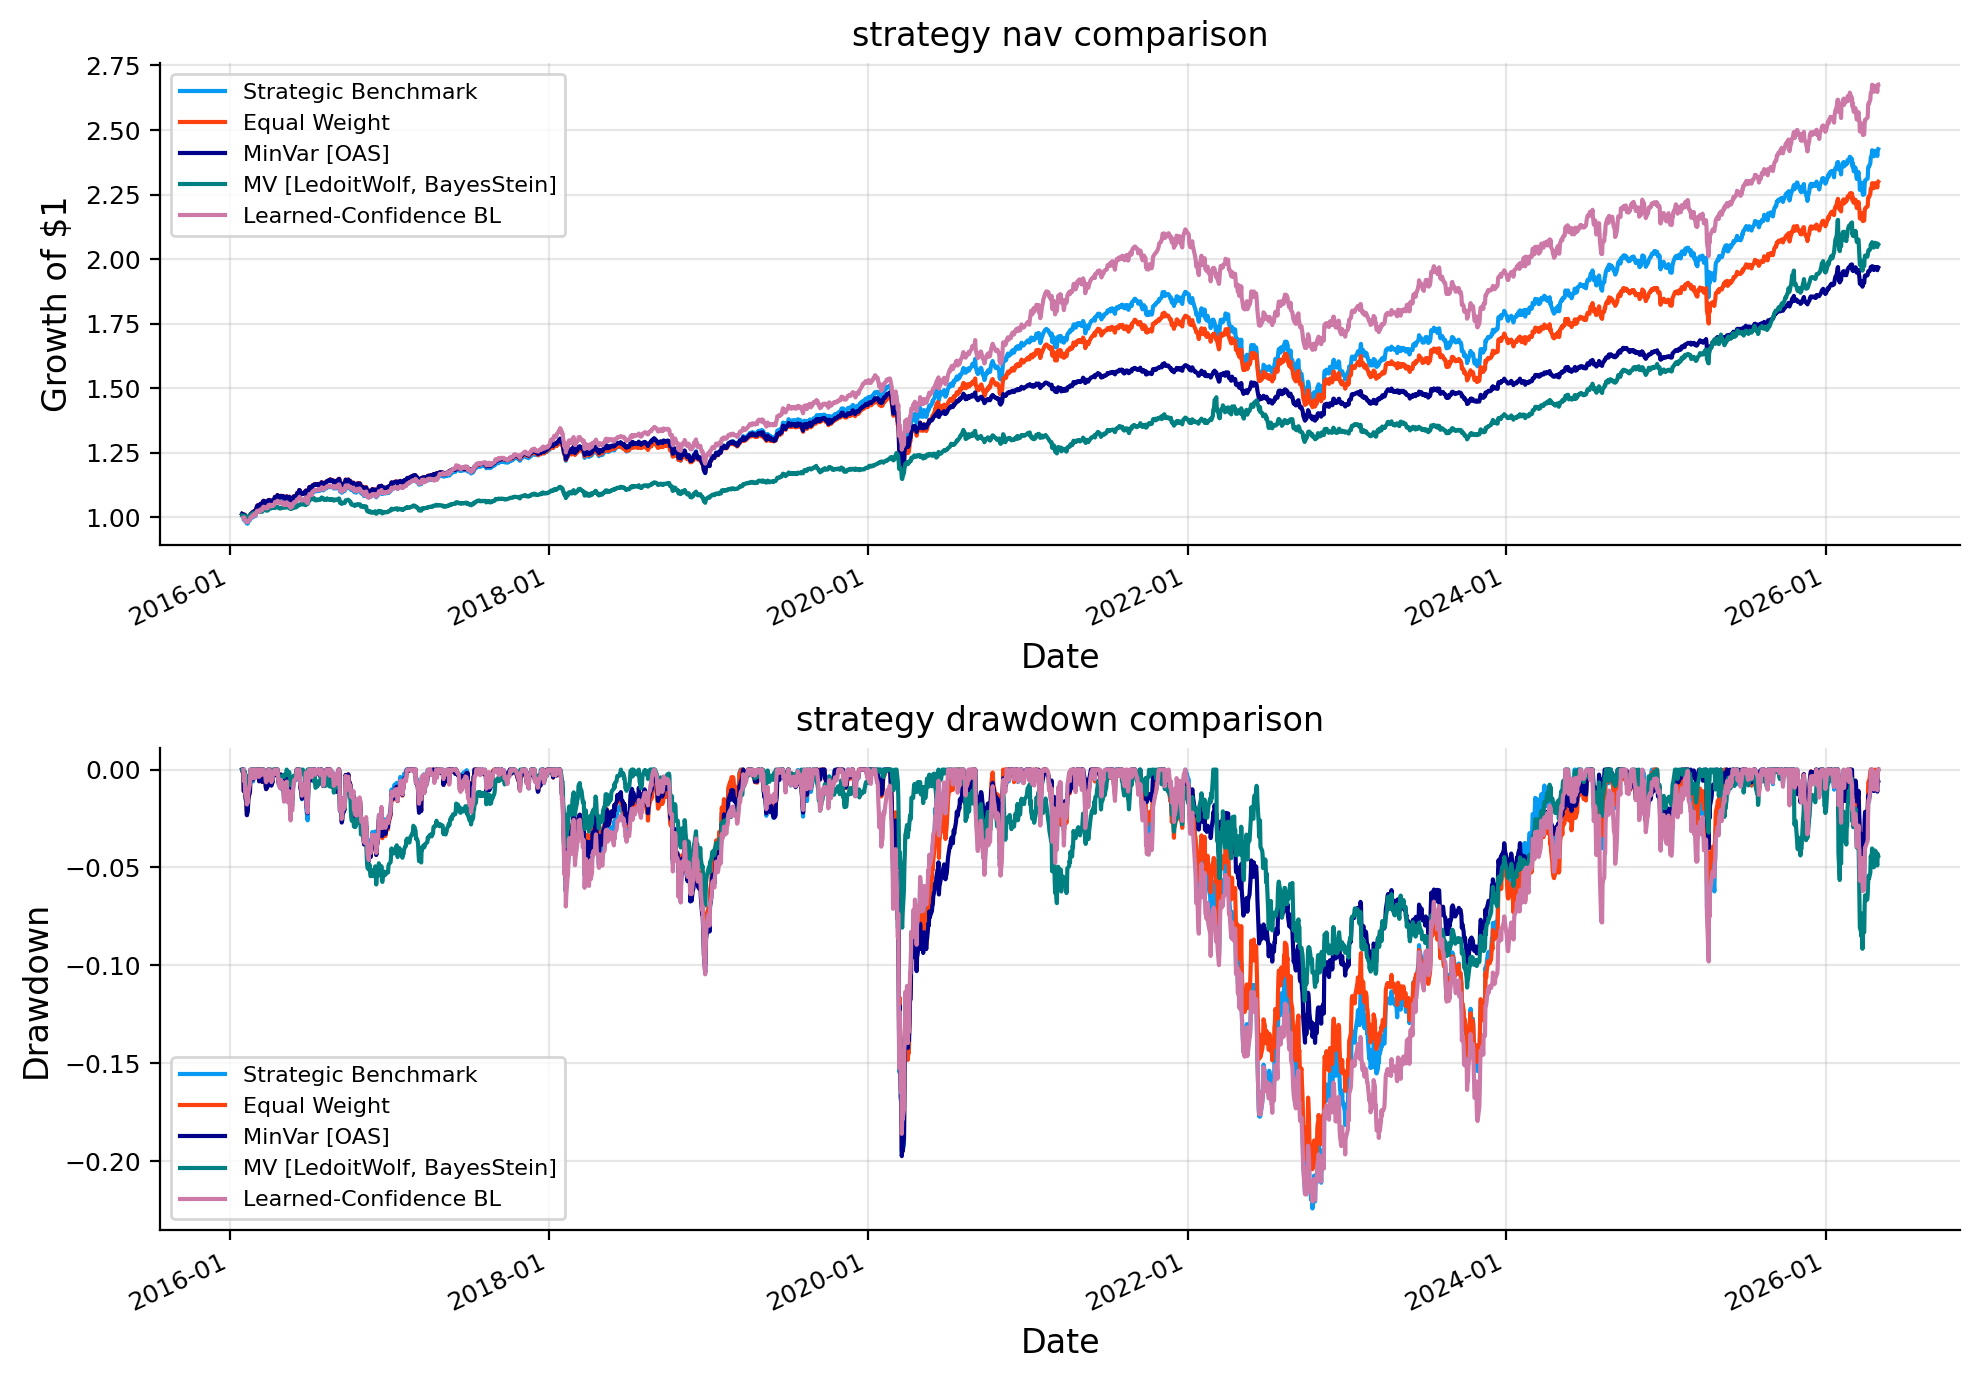

In [29]:
nav_df = pd.DataFrame(nav_by_strategy)[final_strategy_names]
drawdown_df = nav_df / nav_df.cummax() - 1.0
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
plot_strategy_nav(nav_df, final_strategy_names, ax=axes[0], title="strategy nav comparison")
plot_strategy_drawdowns(nav_df, final_strategy_names, ax=axes[1], title="strategy drawdown comparison")
plt.tight_layout()
plt.show()


,max_dd,longest_dd_days,avg_recovery_days,ulcer_index
object,,,,
Equal Weight,-0.2041,667,14.7219,0.0571
Learned-Confidence BL,-0.2207,598,13.5122,0.0670
"MV (LedoitWolf, BayesStein)",-0.1181,549,18.6555,0.0388
MinVar (OAS),-0.1975,668,15.2414,0.0423
Strategic Benchmark,-0.2242,598,12.4830,0.0611


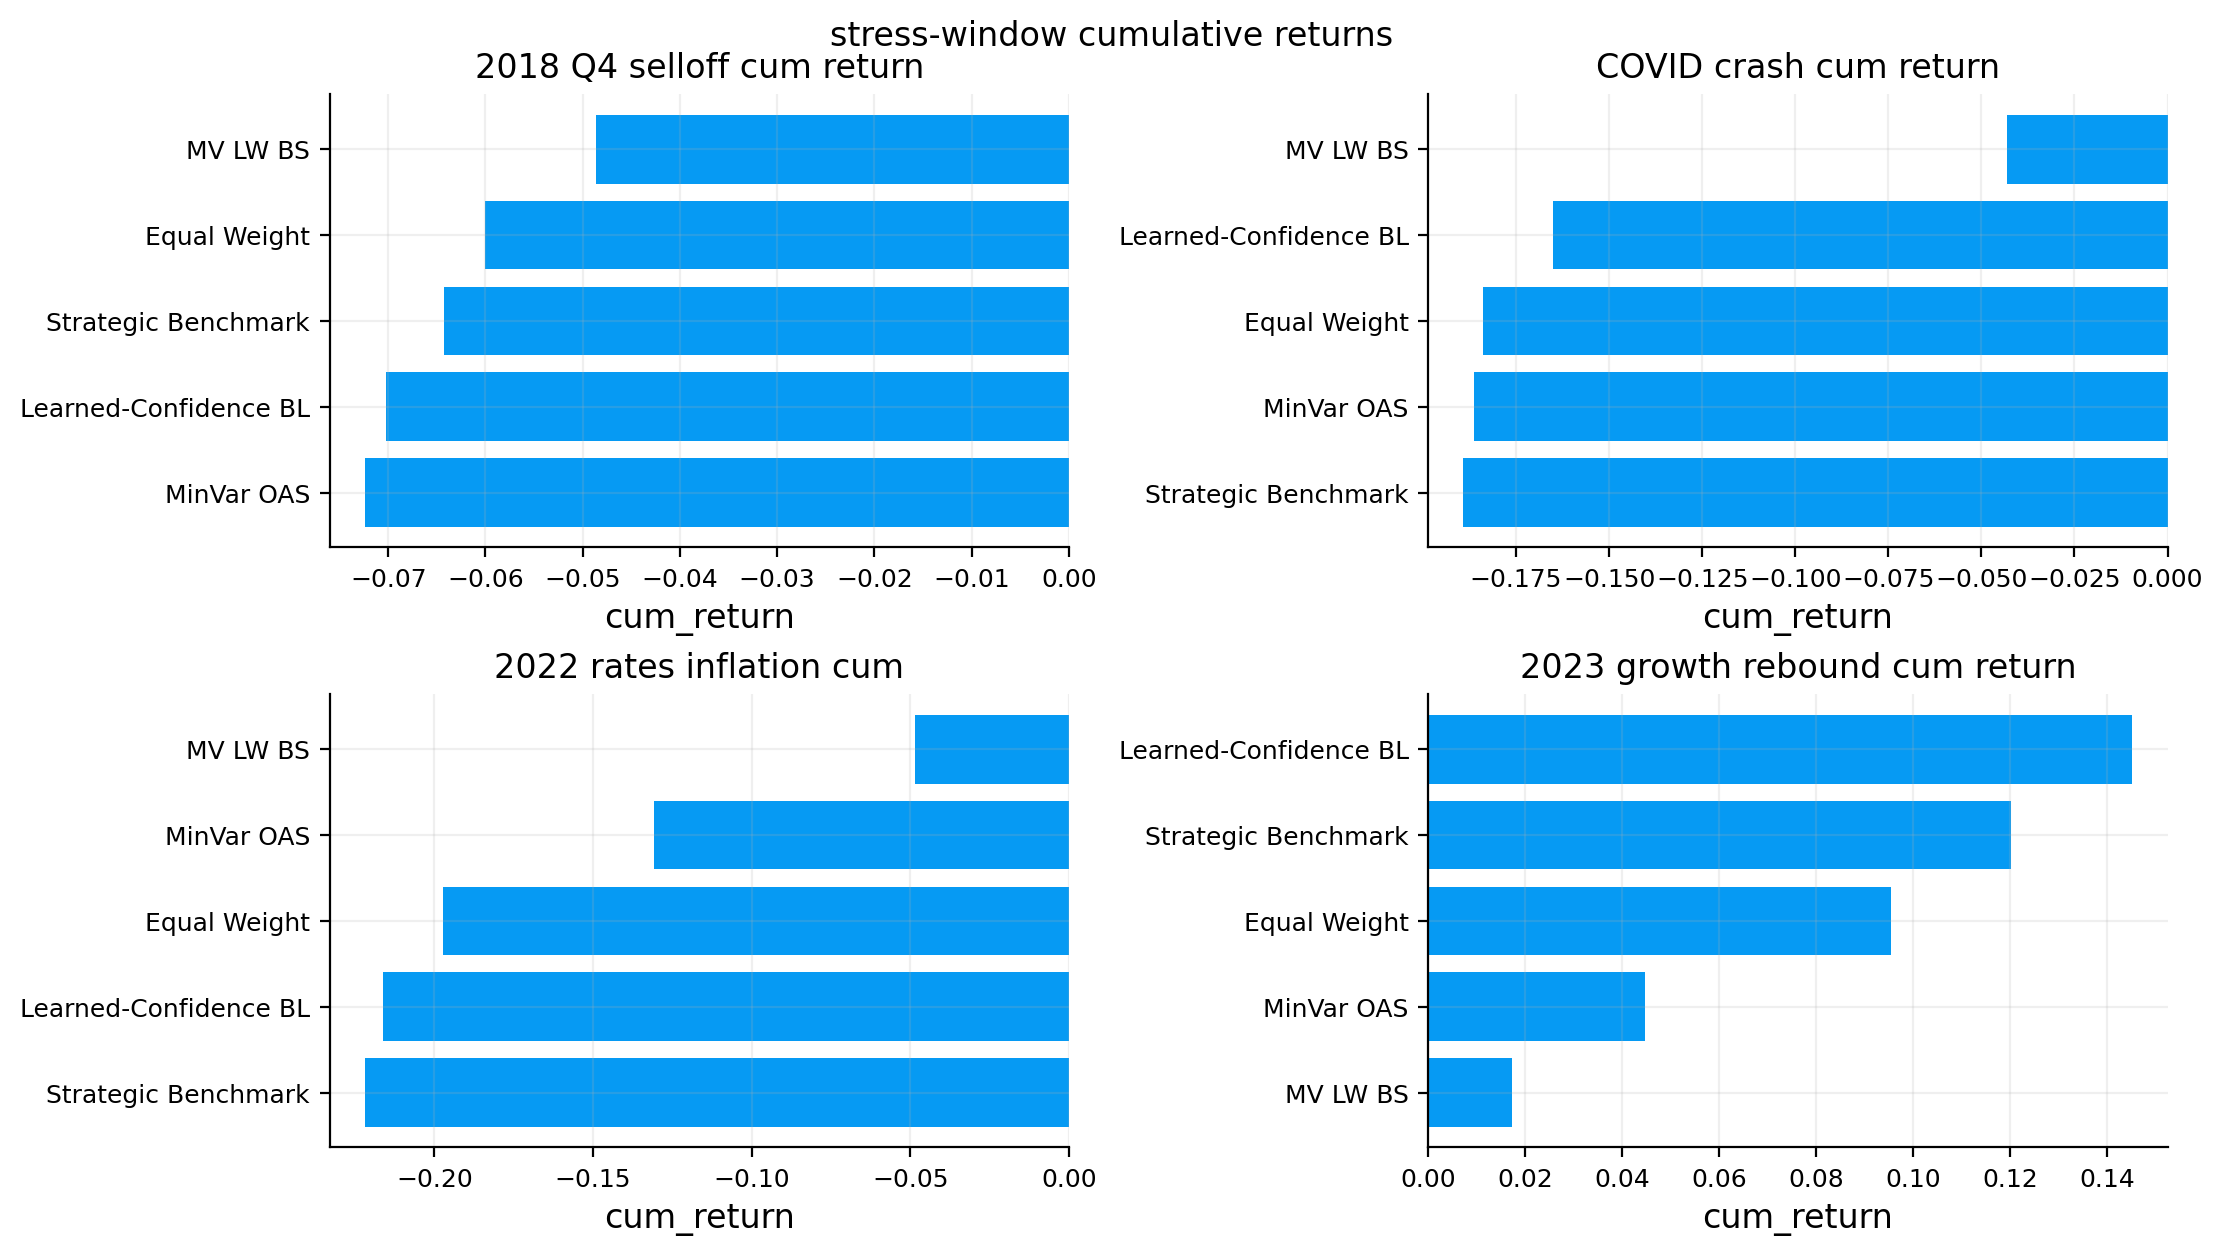

,hist_var5,hist_es5,fhs_var5,fhs_es5
object,,,,
Equal Weight,0.0086,0.0139,0.0099,0.0152
Learned-Confidence BL,0.0100,0.0158,0.0122,0.0177
"MV (LedoitWolf, BayesStein)",0.0064,0.0106,0.0118,0.0176
MinVar (OAS),0.0066,0.0111,0.0074,0.0114
Strategic Benchmark,0.0093,0.0151,0.0109,0.0172


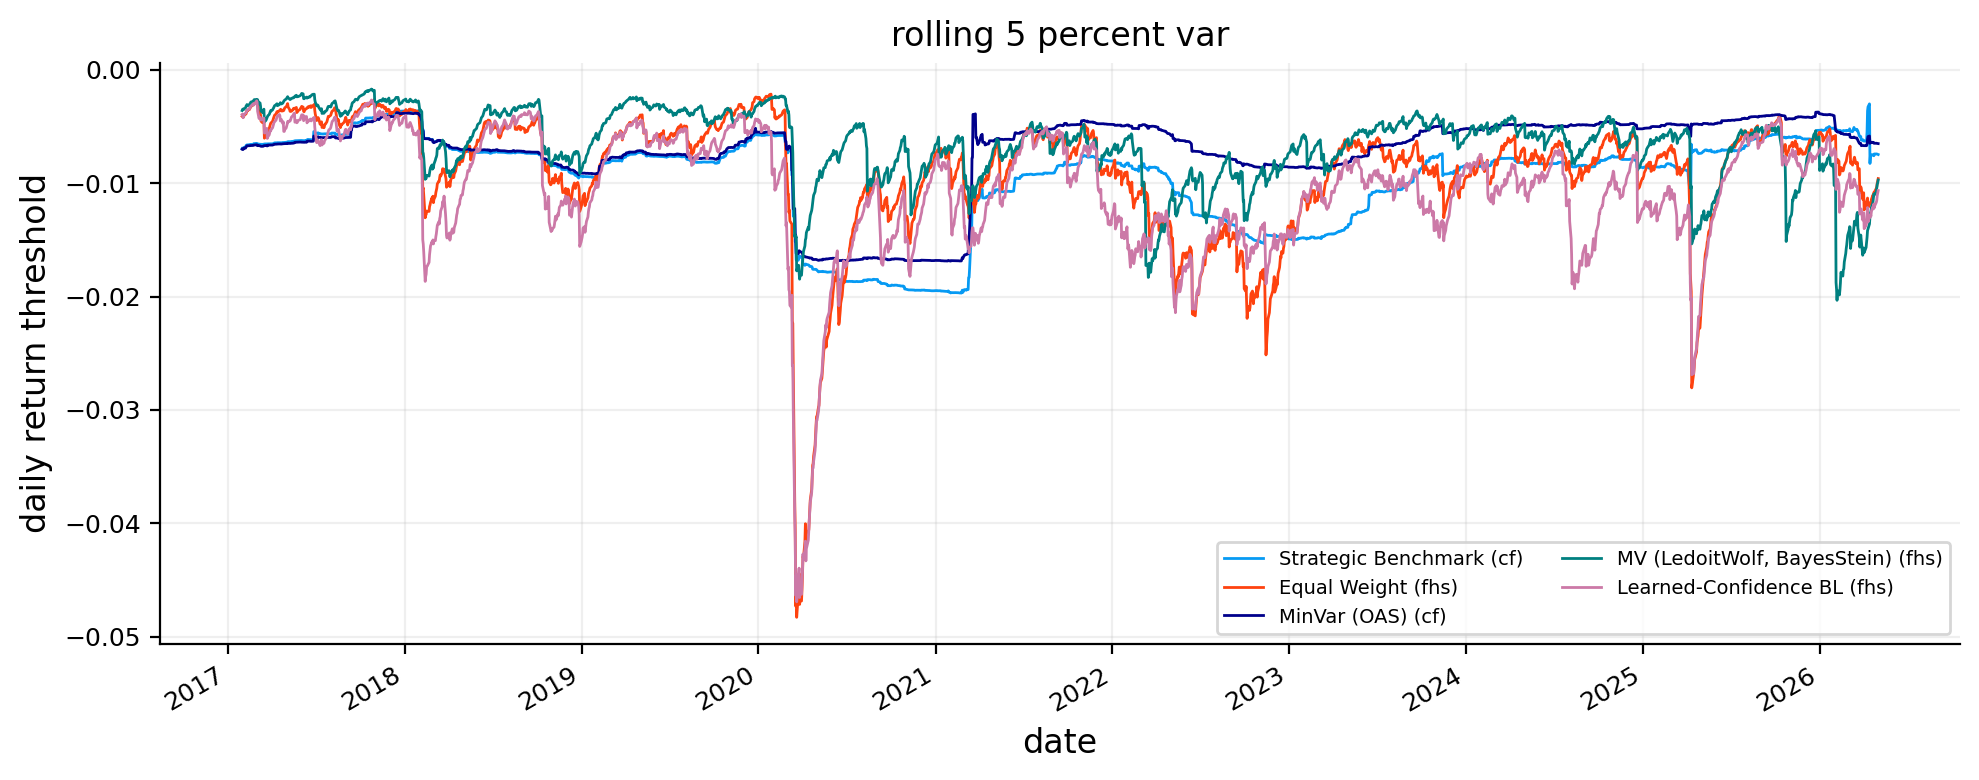

In [30]:
final_returns_df = pd.DataFrame(returns_by_strategy)[final_strategy_names].dropna(how="all").fillna(0.0)

drawdown_summary = drawdown_summary_table(final_returns_df)
if drawdown_summary.empty:
    rows = []
    for name in final_strategy_names:
        nav = simple_nav(final_returns_df[name]); dd = simple_drawdown(nav)
        rows.append({"strategy": name, "max_drawdown": dd.min(), "date_of_max_drawdown": dd.idxmin(), "current_drawdown": dd.iloc[-1], "average_drawdown": dd.mean()})
    drawdown_summary = pd.DataFrame(rows).set_index("strategy")
display(drawdown_summary.round(4))

stress_windows = {"2018_Q4_selloff": ("2018-10-01", "2018-12-31"), "COVID_crash": ("2020-02-19", "2020-03-23"), "2022_rates_inflation": ("2022-01-03", "2022-10-14"), "2023_growth_rebound": ("2023-01-01", "2023-07-31")}
stress_result = stress_table(final_returns_df, windows=stress_windows, worst_only=False)
fig, axes = plt.subplots(2, 2, figsize=(11, 6), constrained_layout=True)
for ax, window in zip(axes.ravel(), stress_windows.keys()):
    plot_stress_bar(ax, stress_result, window=window, metric="cum_return", ascending=True)
fig.suptitle("stress-window cumulative returns", y=1.02)
plt.show()

var_es = var_es_table(final_returns_df, alpha=0.05, methods=("hist", "fhs"))
display(var_es.round(4))

best_var_method = {name: "fhs" for name in final_strategy_names}
var_backtest_internal = var_backtest_table(final_returns_df, alpha=0.05, methods=("hist", "cf", "fhs"), lookback=252)
picked = best_var_methods(var_backtest_internal)
if isinstance(picked, dict):
    best_var_method.update({k: picked.get(k, "fhs") for k in final_strategy_names})

fig, ax = plt.subplots(figsize=(10, 4))
for name in final_strategy_names:
    method = best_var_method.get(name, "fhs")
    method = method if method in ["hist", "cf", "fhs"] else "fhs"
    rv = rolling_var(final_returns_df[name], alpha=0.05, lookback=252, method=method)
    rv.plot(ax=ax, lw=1.0, label=f"{name} ({method})")
    
ax.set_title("rolling 5 percent var"); ax.set_ylabel("daily return threshold"); ax.set_xlabel("date"); ax.legend(ncol=2, fontsize=7)
plt.tight_layout()
plt.show()


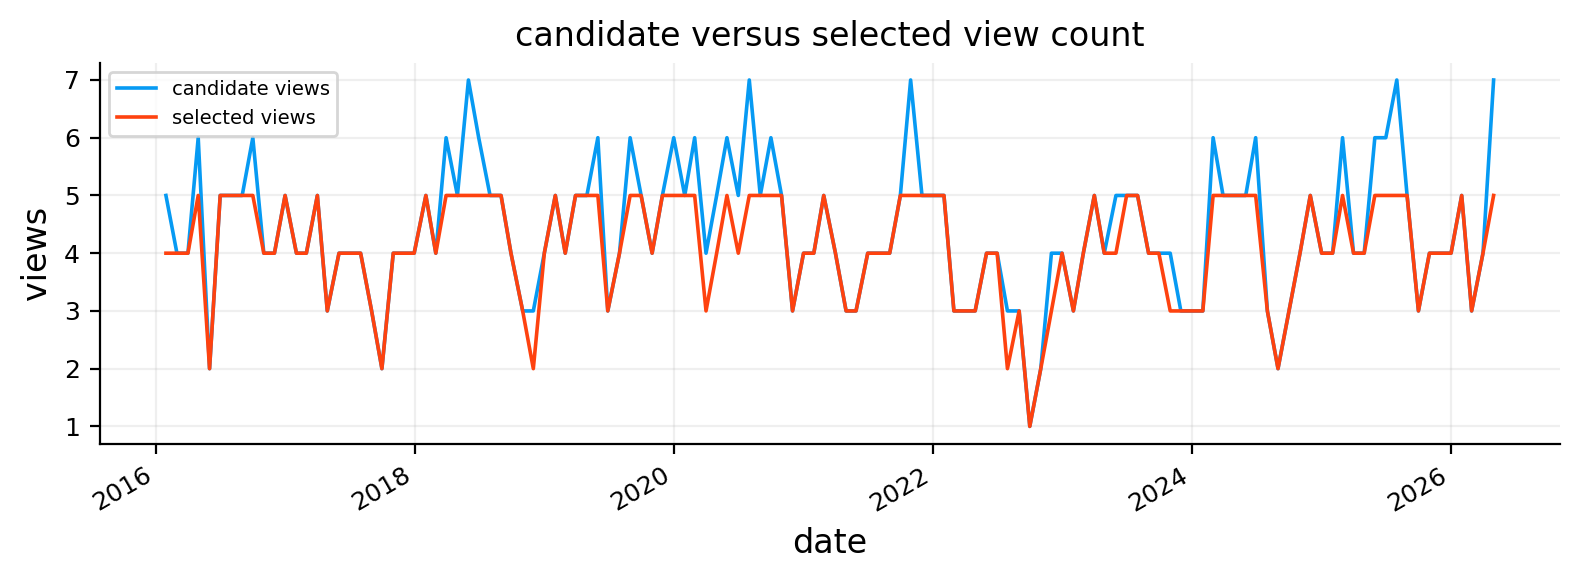

,selected_count,selected_rebalance_count,avg_q_tilt,avg_abs_q_tilt,avg_confidence,avg_confluence,avg_selected_score,selected_share_of_rebalances
view_family,,,,,,,,
risk_adj_momentum,123,123,0.0103,0.0103,0.4487,0.7308,0.6403,0.9919
dual_momentum,106,106,0.0120,0.0120,0.4214,0.6667,0.5755,0.8548
duration_quality,66,66,0.0020,0.0020,0.3496,0.3376,0.3737,0.5323
credit_switch,57,57,0.0061,0.0061,0.5092,0.5648,0.6041,0.4597
liquid_leadership,48,48,0.0215,0.0215,0.5437,0.3768,0.5742,0.3871
international_rotation,38,38,0.0047,0.0047,0.3069,0.5114,0.4247,0.3065
growth_duration,28,28,0.0115,0.0115,0.4689,0.3885,0.4846,0.2258
reflation_breadth,21,21,0.0242,0.0242,0.6453,0.6587,0.6735,0.1694
inflation_rotation,19,19,0.0096,0.0096,0.4265,0.3823,0.4723,0.1532


,realized_count,hit_rate,avg_forward_payoff_ann,payoff_vol,avg_q_tilt,payoff_ir
view_family,,,,,,
risk_adj_momentum,122,0.5738,0.0356,0.4231,0.0103,0.0840
dual_momentum,105,0.5905,0.0563,0.3870,0.0119,0.1454
duration_quality,66,0.3333,-0.0501,0.3234,0.0020,-0.1550
credit_switch,56,0.5357,0.0383,0.5335,0.0061,0.0718
liquid_leadership,48,0.6250,0.0562,0.4198,0.0215,0.1339
international_rotation,38,0.4474,-0.0775,0.3486,0.0047,-0.2224
growth_duration,28,0.4286,0.0805,0.4631,0.0115,0.1738
reflation_breadth,20,0.7000,0.1273,0.3458,0.0238,0.3682
inflation_rotation,18,0.5000,0.0339,0.6572,0.0094,0.0516


,strategy,view_family,observations,avg_active_return_horizon,active_return_ann,hit_rate
4,Learned-Confidence BL,growth_duration,28,0.0038,0.0459,0.7143
0,Learned-Confidence BL,correlation_stress,4,0.0033,0.0393,1.0000
5,Learned-Confidence BL,inflation_rotation,19,0.0027,0.0326,0.7895
8,Learned-Confidence BL,reflation_breadth,21,0.0020,0.0244,0.6190
3,Learned-Confidence BL,duration_quality,66,0.0013,0.0157,0.6061
7,Learned-Confidence BL,liquid_leadership,48,0.0011,0.0130,0.5625
9,Learned-Confidence BL,risk_adj_momentum,123,0.0009,0.0113,0.5854
2,Learned-Confidence BL,dual_momentum,106,0.0008,0.0099,0.5943
1,Learned-Confidence BL,credit_switch,57,-0.0001,-0.0015,0.5088
6,Learned-Confidence BL,international_rotation,38,-0.0012,-0.0150,0.4211


,selected_views,max_abs_p_vector_corr,avg_abs_p_vector_corr
count,124.0000,124.0000,124.0000
mean,4.1129,0.6336,0.3434
std,0.9214,0.1427,0.1070
min,1.0000,0.0000,0.0000
25%,4.0000,0.5774,0.2715
50%,4.0000,0.6455,0.3317
75%,5.0000,0.7193,0.4073
max,5.0000,0.8281,0.6291


,dual_momentum,reflation_breadth,credit_switch,risk_adj_momentum,inflation_rotation
dual_momentum,1.000,0.333,0.298,0.810,0.756
reflation_breadth,0.333,1.000,0.683,0.580,0.172
credit_switch,0.298,0.683,1.000,0.540,0.252
risk_adj_momentum,0.810,0.580,0.540,1.000,0.612
inflation_rotation,0.756,0.172,0.252,0.612,1.000


In [31]:
candidate_active_count = candidate_view_log.groupby("date").size().reindex(rebalance_dates[:-1], fill_value=0) if not candidate_view_log.empty else pd.Series(0, index=rebalance_dates[:-1])
selected_active_count = selected_view_log.groupby("date").size().reindex(rebalance_dates[:-1], fill_value=0) if not selected_view_log.empty else pd.Series(0, index=rebalance_dates[:-1])
fig, ax = plt.subplots(figsize=(8, 3))
candidate_active_count.plot(ax=ax, lw=1.3, label="candidate views")
selected_active_count.plot(ax=ax, lw=1.3, label="selected views")
ax.set_title("candidate versus selected view count")
ax.set_ylabel("views")
ax.set_xlabel("date")
ax.legend()
plt.tight_layout(); plt.show()

selected_payoff_history = build_view_payoff_history(selected_view_log, returns[assets]) if not selected_view_log.empty else pd.DataFrame()

if not selected_view_log.empty:
    selected_family_diagnostics = selected_view_log.groupby("view_family").agg(
        selected_count=("view_name", "size"),
        selected_rebalance_count=("date", "nunique"),
        avg_q_tilt=("q_tilt_final", "mean"),
        avg_abs_q_tilt=("q_tilt_final", lambda x: np.mean(np.abs(x))),
        avg_confidence=("confidence", "mean"),
        avg_confluence=("confluence_score", "mean"),
        avg_selected_score=("selected_score", "mean"),
    ).sort_values("selected_count", ascending=False)
    selected_family_diagnostics["selected_share_of_rebalances"] = selected_family_diagnostics["selected_rebalance_count"] / len(rebalance_dates[:-1])
    display(selected_family_diagnostics.round(4))

    if not selected_payoff_history.empty:
        realized_payoff_by_family = selected_payoff_history.groupby("view_family").agg(
            realized_count=("payoff_ann", "size"),
            hit_rate=("hit", "mean"),
            avg_forward_payoff_ann=("payoff_ann", "mean"),
            payoff_vol=("payoff_ann", "std"),
            avg_q_tilt=("q_tilt", "mean"),
        )
        realized_payoff_by_family["payoff_ir"] = realized_payoff_by_family["avg_forward_payoff_ann"] / realized_payoff_by_family["payoff_vol"].replace(0.0, np.nan)
        display(realized_payoff_by_family.sort_values("realized_count", ascending=False).round(4))

    def active_return_conditional_on_family(strategy_name):
        active = (combined_results[strategy_name]["returns"] - combined_results["Strategic Benchmark"]["returns"]).dropna()
        rows = []
        for family, grp in selected_view_log.groupby("view_family"):
            horizon_returns = []
            for dt in pd.to_datetime(grp["date"].drop_duplicates()):
                pos = active.index.searchsorted(pd.Timestamp(dt), side="right")
                if pos >= len(active):
                    continue
                end = min(pos + view_horizon_days, len(active))
                if end <= pos:
                    continue
                horizon_returns.append(float((1.0 + active.iloc[pos:end]).prod() - 1.0))
            if horizon_returns:
                vals = pd.Series(horizon_returns, dtype=float)
                rows.append({
                    "strategy": strategy_name,
                    "view_family": family,
                    "observations": int(len(vals)),
                    "avg_active_return_horizon": float(vals.mean()),
                    "active_return_ann": float(np.log1p(np.clip(vals.mean(), -0.95, None)) * annualization / view_horizon_days),
                    "hit_rate": float((vals > 0).mean()),
                })
        return pd.DataFrame(rows)

    active_conditional = active_return_conditional_on_family("Learned-Confidence BL")
    if not active_conditional.empty:
        display(active_conditional.sort_values(["strategy", "active_return_ann"], ascending=[True, False]).round(4))

    redundancy_rows = []
    latest_corr = pd.DataFrame()
    for dt, grp in selected_view_log.groupby("date"):
        p_rows = []
        labels = []
        for _, row in grp.iterrows():
            p_rows.append(pd.Series(row.get("p_vector", {}), dtype=float).reindex(assets).fillna(0.0))
            labels.append(row["view_family"])
        if len(p_rows) < 2:
            redundancy_rows.append({"date": pd.Timestamp(dt), "selected_views": len(p_rows), "max_abs_p_vector_corr": 0.0, "avg_abs_p_vector_corr": 0.0})
            continue
        p_frame = pd.DataFrame(p_rows, index=labels)
        corr = p_frame.T.corr().replace([np.inf, -np.inf], np.nan)
        vals = corr.where(~np.eye(len(corr), dtype=bool)).stack().abs()
        redundancy_rows.append({"date": pd.Timestamp(dt), "selected_views": len(p_rows), "max_abs_p_vector_corr": float(vals.max()) if len(vals) else 0.0, "avg_abs_p_vector_corr": float(vals.mean()) if len(vals) else 0.0})
        if pd.Timestamp(dt) == pd.Timestamp(selected_view_log["date"].max()):
            latest_corr = corr
    redundancy_summary = pd.DataFrame(redundancy_rows).set_index("date")
    display(redundancy_summary.describe().round(4))
    if not latest_corr.empty:
        display(latest_corr.round(3))
else:
    print("no selected views were active")


,asset,benchmark_weight,prior_mu,post_mu_learned_confidence_bl,posterior_shift_learned_confidence_bl
0,SPY,0.2222,0.1142,0.1183,0.0041
1,QQQ,0.0808,0.1406,0.1322,-0.0084
2,IWM,0.0404,0.1526,0.1819,0.0293
3,EFA,0.0909,0.1602,0.1884,0.0282
4,EEM,0.0505,0.2100,0.2270,0.0170
5,TLT,0.0808,0.0394,0.0473,0.0079
6,IEF,0.0808,0.0263,0.0316,0.0053
7,SHY,0.0505,0.0079,0.0093,0.0014
8,AGG,0.1010,0.0241,0.0287,0.0047
9,LQD,0.0505,0.0360,0.0421,0.0062


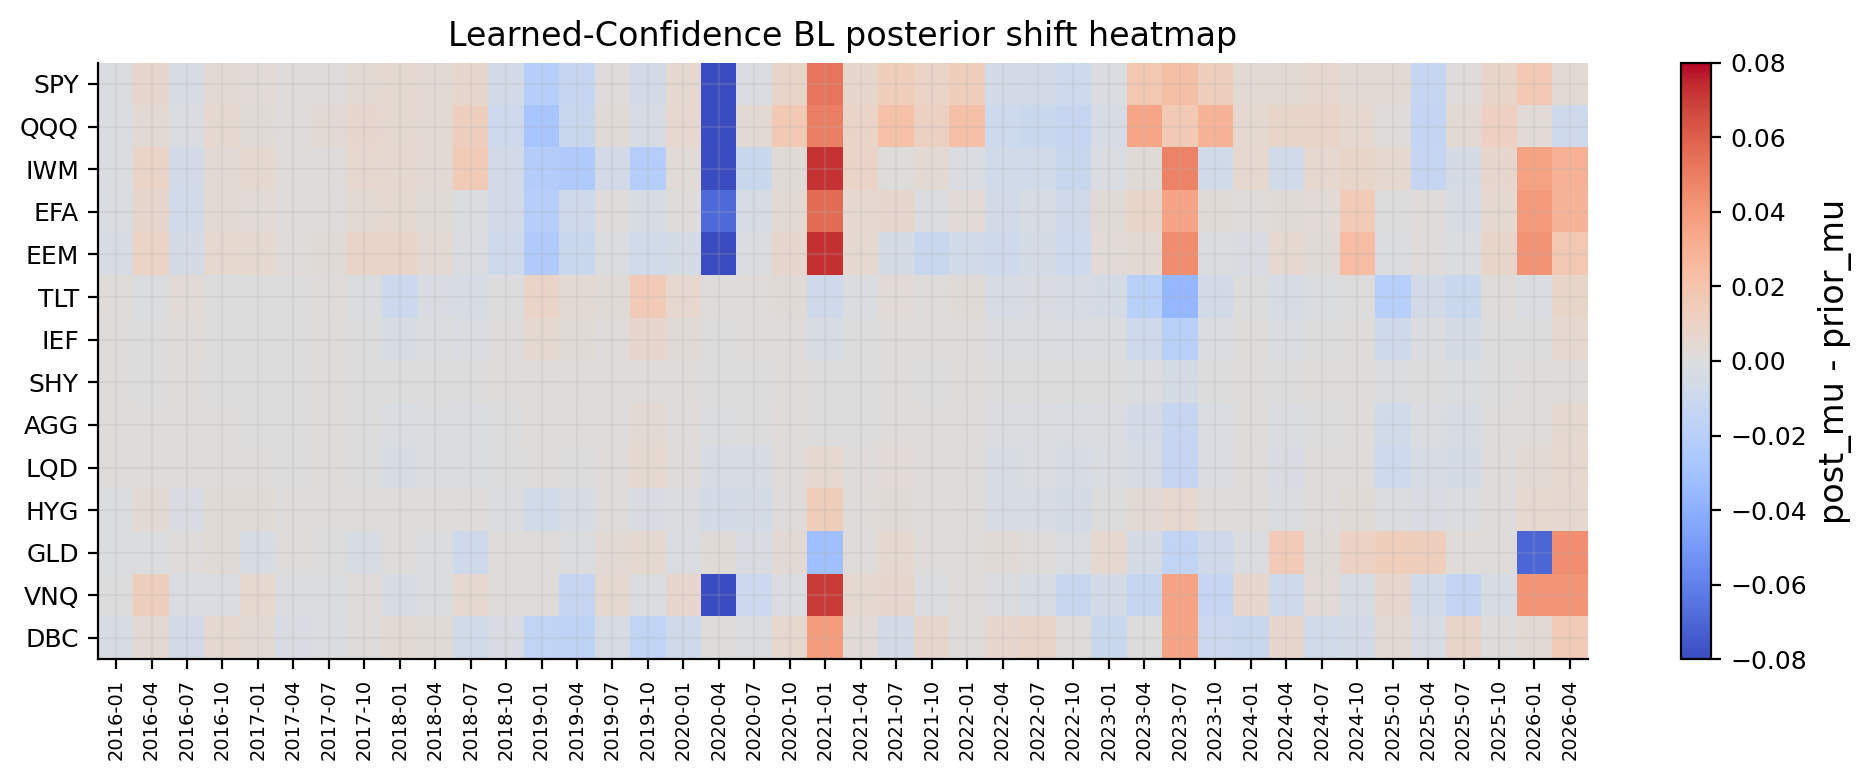

In [32]:
latest_post_date = posterior_log["date"].max() if not posterior_log.empty else pd.Timestamp(rebalance_dates[-2])
prior_latest = prior_mu_by_date[pd.Timestamp(latest_post_date)].reindex(assets)
posterior_clarity = pd.DataFrame({
    "asset": assets,
    "benchmark_weight": benchmark_w.reindex(assets).values,
    "prior_mu": prior_latest.values,
    "post_mu_learned_confidence_bl": post_mu_store.get(("Learned-Confidence BL", latest_post_date), prior_latest).reindex(assets).values,
})
posterior_clarity["posterior_shift_learned_confidence_bl"] = posterior_clarity["post_mu_learned_confidence_bl"] - posterior_clarity["prior_mu"]
display(posterior_clarity.round(4))
shift_cols = {}
for dt in sorted({key[1] for key in post_mu_store if key[0] == "Learned-Confidence BL"}):
    shift_cols[dt] = post_mu_store[("Learned-Confidence BL", dt)].reindex(assets) - prior_mu_by_date[dt].reindex(assets)
learned_confidence_shift = pd.DataFrame(shift_cols)
if not learned_confidence_shift.empty:
    selected_shift = learned_confidence_shift.iloc[:, ::max(1, learned_confidence_shift.shape[1] // 36)]
    fig, ax = plt.subplots(figsize=(10, 4))
    im = ax.imshow(selected_shift, aspect="auto", cmap="coolwarm", vmin=-0.08, vmax=0.08)
    ax.set_title("Learned-Confidence BL posterior shift heatmap")
    ax.set_yticks(range(len(selected_shift.index)), selected_shift.index)
    ax.set_xticks(range(len(selected_shift.columns)), [d.strftime("%Y-%m") for d in selected_shift.columns], rotation=90, fontsize=7)
    fig.colorbar(im, ax=ax, label="post_mu - prior_mu")
    plt.tight_layout(); plt.show()

In [33]:
if not candidate_view_log.empty:
    candidate_counts = candidate_view_log.groupby("view_family").size().rename("candidate_count")
    display_name = candidate_view_log.groupby("view_family")["family_display_name"].agg(lambda x: x.mode().iloc[0] if len(x.mode()) else x.iloc[0]) if "family_display_name" in candidate_view_log.columns else pd.Series(dtype=object)
    econ_label = candidate_view_log.groupby("view_family")["economic_label"].agg(lambda x: x.mode().iloc[0] if len(x.mode()) else x.iloc[0])
    risk_mode = candidate_view_log.groupby("view_family")["risk_orientation"].agg(lambda x: x.mode().iloc[0] if len(x.mode()) else x.iloc[0])
else:
    candidate_counts = pd.Series(dtype=float, name="candidate_count"); display_name = pd.Series(dtype=object); econ_label = pd.Series(dtype=object); risk_mode = pd.Series(dtype=object)
if not selected_view_log.empty:
    selected_counts = selected_view_log.groupby("view_family").size().rename("selected_count")
    avg_abs_q = selected_view_log.groupby("view_family")["q_tilt_final"].agg(lambda x: np.mean(np.abs(x))).rename("avg_abs_q")
    avg_q_tilt = selected_view_log.groupby("view_family")["q_tilt_final"].mean().rename("avg_q_tilt")
else:
    selected_counts = pd.Series(dtype=float, name="selected_count"); avg_abs_q = pd.Series(dtype=float, name="avg_abs_q"); avg_q_tilt = pd.Series(dtype=float, name="avg_q_tilt")
if not all_payoff_history.empty:
    payoff_stats = all_payoff_history.groupby("view_family").agg(hit_rate=("hit", "mean"), avg_payoff=("payoff", "mean"), payoff_vol=("payoff", "std"))
    payoff_stats["payoff_ir"] = payoff_stats["avg_payoff"] / payoff_stats["payoff_vol"].replace(0.0, np.nan)
    recent_hits = all_payoff_history.sort_values("date").groupby("view_family").tail(6).groupby("view_family")["hit"].mean().rename("recent_hit_rate")
    stress_stats = all_payoff_history[all_payoff_history.get("stress_state", False).astype(bool)].groupby("view_family").agg(stress_obs=("hit", "size"), stress_hit_rate=("hit", "mean"), stress_avg_payoff=("payoff", "mean")) if "stress_state" in all_payoff_history.columns else pd.DataFrame()
else:
    payoff_stats = pd.DataFrame(columns=["hit_rate", "avg_payoff", "payoff_vol", "payoff_ir"]); recent_hits = pd.Series(dtype=float, name="recent_hit_rate"); stress_stats = pd.DataFrame()
conf_means = confidence_log.groupby("view_family")["confidence"].mean().rename("avg_tactical_confidence") if not confidence_log.empty else pd.Series(dtype=float)
score_means = confidence_log.groupby("view_family")["selected_score"].mean().rename("avg_selected_score") if not confidence_log.empty and "selected_score" in confidence_log.columns else pd.Series(dtype=float)
reliability = pd.concat([display_name.rename("display_name"), candidate_counts, selected_counts, econ_label.rename("economic_label"), payoff_stats, avg_abs_q, avg_q_tilt, conf_means, score_means, recent_hits, stress_stats, risk_mode.rename("risk_orientation_mode")], axis=1)
reliability["selected_share"] = reliability["selected_count"] / reliability["candidate_count"].replace(0.0, np.nan)


def reliability_label(row):
    count = row.get("candidate_count", 0); hit_rate = row.get("hit_rate", np.nan); payoff_ir = row.get("payoff_ir", np.nan); risk = row.get("risk_orientation_mode", "neutral")
    if count < 10:
        return "low evidence"
    if np.isfinite(payoff_ir) and np.isfinite(hit_rate) and payoff_ir > 0.03 and hit_rate >= 0.52:
        return "reliable positive"
    if (np.isfinite(hit_rate) and hit_rate < 0.52) or (np.isfinite(payoff_ir) and payoff_ir <= 0.03):
        return "weak reliability, soft scaled"
    if risk == "risk_off":
        return "mostly defensive"
    if risk == "risk_on":
        return "mostly risk-on"
    return "mixed but useful"


def final_reliability_decision(row):
    count = row.get("candidate_count", 0)
    selected_count = row.get("selected_count", 0)
    hit_rate = row.get("hit_rate", np.nan)
    payoff_ir = row.get("payoff_ir", np.nan)
    recent_hit_rate = row.get("recent_hit_rate", np.nan)
    if np.isfinite(recent_hit_rate) and recent_hit_rate < 0.35 and count >= 8:
        return "soft-scale recent weakness"
    if count >= 12 and np.isfinite(hit_rate) and hit_rate < 0.52:
        return "soft-scale low hit rate"
    if count >= 12 and np.isfinite(payoff_ir) and payoff_ir <= 0.03:
        return "soft-scale low payoff IR"
    if count < 8:
        return "probation, soft q"
    if selected_count > 0:
        return "ranked eligible"
    return "candidate only"

reliability["interpretation"] = reliability.apply(reliability_label, axis=1)
reliability["final_decision"] = reliability.apply(final_reliability_decision, axis=1)
reliability_cols = ["display_name", "candidate_count", "selected_count", "selected_share", "hit_rate", "avg_payoff", "payoff_vol", "payoff_ir", "avg_abs_q", "avg_q_tilt", "avg_tactical_confidence", "avg_selected_score", "recent_hit_rate", "stress_obs", "stress_hit_rate", "stress_avg_payoff", "risk_orientation_mode", "interpretation", "final_decision"]
reliability = reliability[[col for col in reliability_cols if col in reliability.columns]].sort_values(["selected_count", "candidate_count"], ascending=False)
display(reliability.round(4))

,display_name,candidate_count,selected_count,selected_share,hit_rate,avg_payoff,payoff_vol,payoff_ir,avg_abs_q,avg_q_tilt,avg_tactical_confidence,avg_selected_score,recent_hit_rate,stress_obs,stress_hit_rate,stress_avg_payoff,risk_orientation_mode,interpretation,final_decision
view_family,,,,,,,,,,,,,,,,,,,
risk_adj_momentum,Risk-adjusted momentum,124,123,0.9919,0.5691,0.0327,0.4225,0.0775,0.0103,0.0103,0.4487,0.6403,0.6667,51,0.5098,-0.0482,neutral,reliable positive,ranked eligible
dual_momentum,Dual momentum,117,106,0.9060,0.5690,0.0475,0.4229,0.1122,0.0120,0.0120,0.4214,0.5755,1.0000,49,0.5102,-0.0052,neutral,reliable positive,ranked eligible
duration_quality,Duration quality,77,66,0.8571,0.3684,-0.0326,0.3195,-0.1021,0.0020,0.0020,0.3496,0.3737,0.3333,31,0.3871,-0.0106,risk_off,"weak reliability, soft scaled",soft-scale recent weakness
credit_switch,Credit switch,58,57,0.9828,0.5439,0.0508,0.5370,0.0946,0.0061,0.0061,0.5092,0.6041,0.6667,23,0.4348,-0.0331,risk_on,reliable positive,ranked eligible
liquid_leadership,Liquidity leadership,50,48,0.9600,0.6400,0.0578,0.4113,0.1404,0.0215,0.0215,0.5437,0.5742,0.5000,21,0.6667,0.0741,risk_on,reliable positive,ranked eligible
international_rotation,International rotation,45,38,0.8444,0.4318,-0.0771,0.3395,-0.2270,0.0047,0.0047,0.3069,0.4247,0.5000,14,0.3571,-0.1804,risk_off,"weak reliability, soft scaled",soft-scale low hit rate
growth_duration,Growth-duration barbell,28,28,1.0000,0.4286,0.0805,0.4631,0.1738,0.0115,0.0115,0.4689,0.4846,0.3333,11,0.4545,0.2066,risk_on,"weak reliability, soft scaled",soft-scale recent weakness
reflation_breadth,Reflation breadth,21,21,1.0000,0.7000,0.1273,0.3458,0.3682,0.0242,0.0242,0.6453,0.6735,0.3333,2,1.0000,0.2215,risk_on,reliable positive,soft-scale recent weakness
inflation_rotation,Inflation rotation,20,19,0.9500,0.5263,0.0345,0.6387,0.0540,0.0096,0.0096,0.4265,0.4723,0.5000,6,0.3333,-0.0504,neutral,reliable positive,ranked eligible


In [34]:
decision_table = reliability[[col for col in ["display_name", "candidate_count", "selected_count", "selected_share", "hit_rate", "payoff_ir", "recent_hit_rate", "avg_tactical_confidence", "avg_selected_score", "risk_orientation_mode", "interpretation", "final_decision"] if col in reliability.columns]].copy()
display(decision_table.round(4))
if not selection_log.empty:
    selection_reason_table = selection_log.groupby("scale_reason").size().rename("count").sort_values(ascending=False).to_frame()
    selection_reason_table["share"] = selection_reason_table["count"] / selection_reason_table["count"].sum()
    display(selection_reason_table.round(4))
    monthly_selection_diagnostics = selection_log.groupby("date").agg(
        candidate_views=("view_family", "size"),
        selected_views=("kept", "sum"),
        skipped_by_reliability=("scale_reason", lambda x: x.astype(str).str.contains("reliability skip").sum()),
        skipped_by_redundancy=("scale_reason", lambda x: x.astype(str).str.contains("redundancy gate").sum()),
        skipped_by_direction=("scale_reason", lambda x: x.astype(str).str.contains("direction crowding").sum()),
        skipped_by_missing_data=("scale_reason", lambda x: x.astype(str).str.contains("missing data").sum()),
    )
    display(monthly_selection_diagnostics.describe().round(3))
    selected_distribution = selection_log[selection_log["kept"]].groupby("view_family").size().rename("selected_count").sort_values(ascending=False).to_frame()
    display(selected_distribution)

,display_name,candidate_count,selected_count,selected_share,hit_rate,payoff_ir,recent_hit_rate,avg_tactical_confidence,avg_selected_score,risk_orientation_mode,interpretation,final_decision
view_family,,,,,,,,,,,,
risk_adj_momentum,Risk-adjusted momentum,124,123,0.9919,0.5691,0.0775,0.6667,0.4487,0.6403,neutral,reliable positive,ranked eligible
dual_momentum,Dual momentum,117,106,0.9060,0.5690,0.1122,1.0000,0.4214,0.5755,neutral,reliable positive,ranked eligible
duration_quality,Duration quality,77,66,0.8571,0.3684,-0.1021,0.3333,0.3496,0.3737,risk_off,"weak reliability, soft scaled",soft-scale recent weakness
credit_switch,Credit switch,58,57,0.9828,0.5439,0.0946,0.6667,0.5092,0.6041,risk_on,reliable positive,ranked eligible
liquid_leadership,Liquidity leadership,50,48,0.9600,0.6400,0.1404,0.5000,0.5437,0.5742,risk_on,reliable positive,ranked eligible
international_rotation,International rotation,45,38,0.8444,0.4318,-0.2270,0.5000,0.3069,0.4247,risk_off,"weak reliability, soft scaled",soft-scale low hit rate
growth_duration,Growth-duration barbell,28,28,1.0000,0.4286,0.1738,0.3333,0.4689,0.4846,risk_on,"weak reliability, soft scaled",soft-scale recent weakness
reflation_breadth,Reflation breadth,21,21,1.0000,0.7000,0.3682,0.3333,0.6453,0.6735,risk_on,reliable positive,soft-scale recent weakness
inflation_rotation,Inflation rotation,20,19,0.9500,0.5263,0.0540,0.5000,0.4265,0.4723,neutral,reliable positive,ranked eligible


,count,share
scale_reason,,
kept,510,0.9375
below top selected views,22,0.0404
redundancy gate: exposure cosine similarity,12,0.0221


,candidate_views,selected_views,skipped_by_reliability,skipped_by_redundancy,skipped_by_direction,skipped_by_missing_data
count,124.000,124.000,124.0,124.000,124.0,124.0
mean,4.387,4.113,0.0,0.097,0.0,0.0
std,1.167,0.921,0.0,0.297,0.0,0.0
min,1.000,1.000,0.0,0.000,0.0,0.0
25%,4.000,4.000,0.0,0.000,0.0,0.0
50%,4.000,4.000,0.0,0.000,0.0,0.0
75%,5.000,5.000,0.0,0.000,0.0,0.0
max,7.000,5.000,0.0,1.000,0.0,0.0


,selected_count
view_family,
risk_adj_momentum,123
dual_momentum,106
duration_quality,66
credit_switch,57
liquid_leadership,48
international_rotation,38
growth_duration,28
reflation_breadth,21
inflation_rotation,19


,asset,active_weight_learned_confidence_bl
0,SPY,-0.1443
1,QQQ,-0.0808
2,IEF,-0.0793
3,EEM,-0.0232
4,LQD,-0.0222
5,AGG,-0.0198
6,SHY,-0.0096
7,HYG,-0.0006
8,DBC,0.0298
9,GLD,0.0360


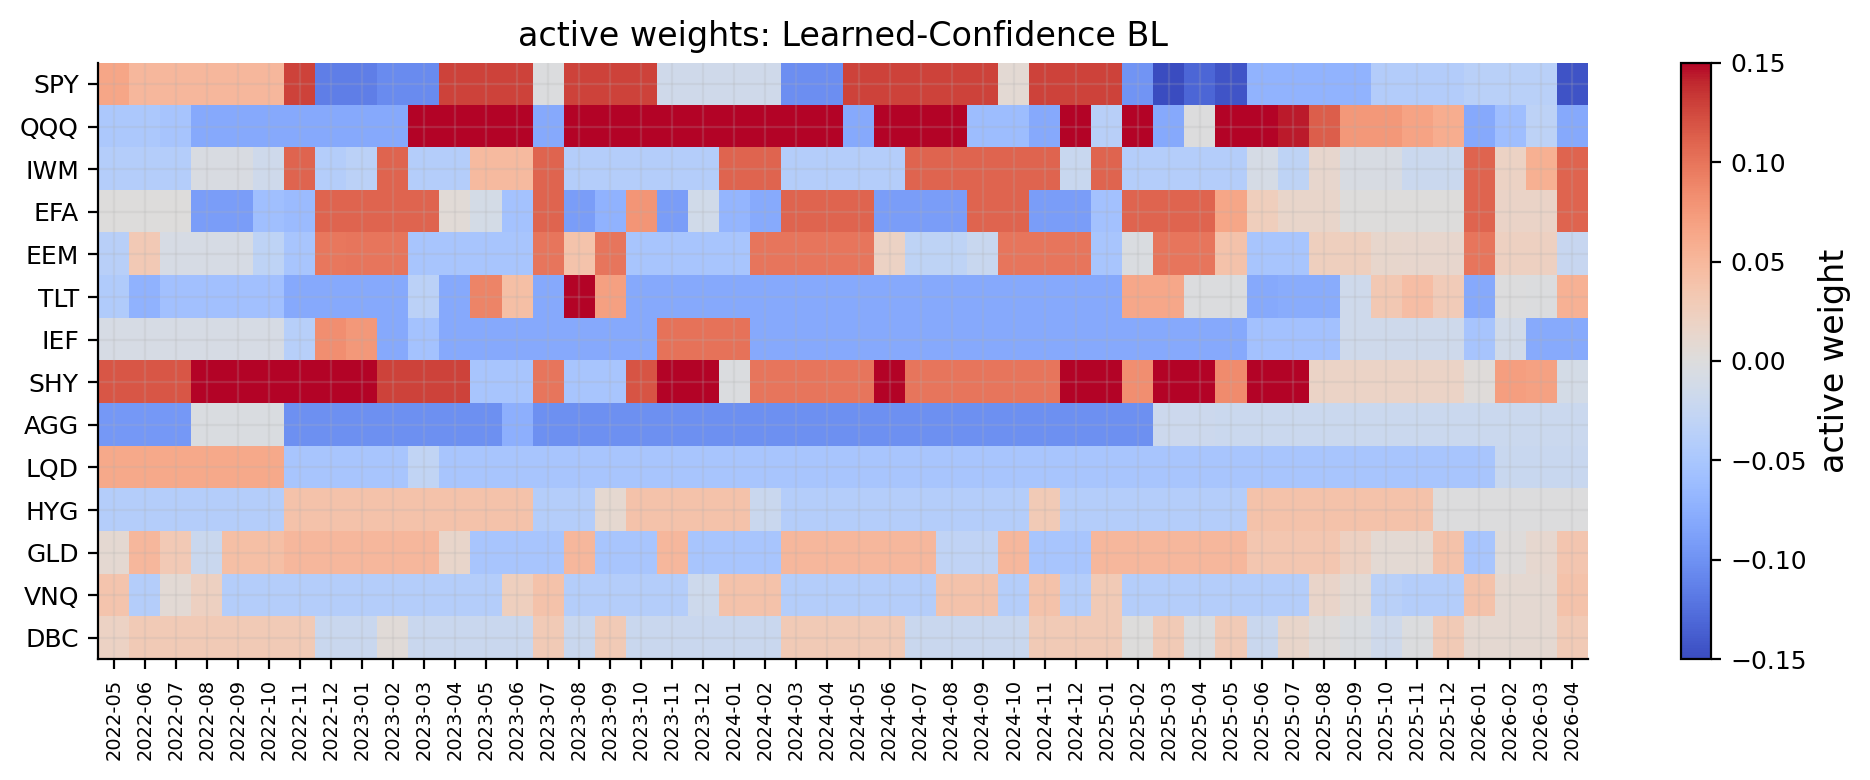

In [35]:
learned_confidence_weights = combined_results["Learned-Confidence BL"]["weights"].reindex(columns=assets)
benchmark_aligned = benchmark_w.reindex(assets).fillna(0.0)
active_w_learned_confidence = learned_confidence_weights.subtract(benchmark_aligned, axis=1)
latest_active_w = active_w_learned_confidence.iloc[-1].sort_values()
display(pd.DataFrame({"asset": latest_active_w.index, "active_weight_learned_confidence_bl": latest_active_w.values}).round(4))

frame = active_w_learned_confidence.iloc[-48:].T
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(frame, aspect="auto", cmap="coolwarm", vmin=-0.15, vmax=0.15)
ax.set_title("active weights: Learned-Confidence BL")
ax.set_yticks(range(len(frame.index)), frame.index)
ax.set_xticks(range(len(frame.columns)), [d.strftime("%Y-%m") for d in frame.columns], rotation=90, fontsize=7)
fig.colorbar(im, ax=ax, label="active weight")
plt.tight_layout(); plt.show()

In [36]:
def active_risk_series(weights):
    rows = []
    for dt, row in weights.iterrows():
        dt = pd.Timestamp(dt)
        if dt not in cov_by_date:
            continue
        diff = row.reindex(assets).fillna(0.0).values - benchmark_aligned.values
        cov_ann = cov_by_date[dt].loc[assets, assets].values
        rows.append((dt, float(np.sqrt(max(diff @ cov_ann @ diff, 0.0)))))
    return pd.Series(dict(rows)).sort_index()

active_diagnostics = pd.DataFrame({
    "avg_active_risk": {
        "Learned-Confidence BL": active_risk_series(combined_results["Learned-Confidence BL"]["weights"].reindex(columns=assets)).mean(),
    },
    "avg_turnover": {
        "Learned-Confidence BL": combined_results["Learned-Confidence BL"]["turnover"].mean(),
    },
})
display(active_diagnostics.round(4))

,avg_active_risk,avg_turnover
Learned-Confidence BL,0.0249,0.1761


## Sector ETF transfer with QuantFinLab

The primary Learned-Confidence Black-Litterman model above was developed on the cross-asset ETF universe and is left intact as the accepted result. This final section uses the reusable QuantFinLab components on a secondary sector ETF universe.

Data selection and cleaning remain visible here. The BL engine, view objects, learned confidence, table helpers, plotting helpers, walk-forward baselines, and common backtest timing/cost handling are delegated to the library. The goal is transferability of the engine, not a claim that sector rotation is the same problem as the cross-asset allocation above.

data file: ..\data\ETF_data.csv
close panel: (4107, 56) 2010-01-04 to 2026-05-01


,ticker,role,first_date,last_date,observations,missing_pct_after_first_valid,included
0,XLK,tradable,2018-07-02,2026-05-01,1969,0.0,True
1,XLC,tradable,2018-07-02,2026-05-01,1969,0.0,True
2,XLY,tradable,2018-07-02,2026-05-01,1969,0.0,True
3,XLF,tradable,2018-07-02,2026-05-01,1969,0.0,True
4,XLI,tradable,2018-07-02,2026-05-01,1969,0.0,True
5,XLE,tradable,2018-07-02,2026-05-01,1969,0.0,True
6,XLB,tradable,2018-07-02,2026-05-01,1969,0.0,True
7,XLV,tradable,2018-07-02,2026-05-01,1969,0.0,True
8,XLP,tradable,2018-07-02,2026-05-01,1969,0.0,True
9,XLU,tradable,2018-07-02,2026-05-01,1969,0.0,True


sector assets: ['XLK', 'XLC', 'XLY', 'XLF', 'XLI', 'XLE', 'XLB', 'XLV', 'XLP', 'XLU', 'XLRE']
sector signal assets: ['SPY', 'QQQ', 'IWM', 'TLT', 'IEF', 'SHY', 'LQD', 'HYG', 'GLD', 'DBC', 'UUP']
sector return panel: (1968, 11) 2018-07-03 to 2026-05-01
sector rebalance dates: 71 2020-07-31 to 2026-05-01


,benchmark_weight
XLK,0.0909
XLC,0.0909
XLY,0.0909
XLF,0.0909
XLI,0.0909
XLE,0.0909
XLB,0.0909
XLV,0.0909
XLP,0.0909
XLU,0.0909


,family,display_name,cap,function,economic_idea,typical_long,typical_short,main_signal
0,sector_momentum,Sector momentum,0.012,sector_momentum,Cross-sectional relative sector strength.,Top 3 sectors by momentum/vol score,Bottom 3 sectors by momentum/vol score,63d/126d sector momentum minus volatility
1,growth_leadership,Growth leadership,0.030,growth_leadership,Growth sectors lead when QQQ and growth basket...,"XLK, XLC, XLY","XLP, XLU, XLV",QQQ/SPY and growth/defensive relative momentum
2,defensive_rotation,Defensive rotation,0.006,defensive_rotation,Defensive sectors outperform in equity stress.,"XLP, XLU, XLV",Growth sectors and weak cyclicals,"SPY drawdown, SPY momentum, defensive relative..."
3,cyclical_breadth,Cyclical breadth,0.020,cyclical_breadth,Cyclicals lead when participation broadens.,"XLI, XLF, XLB, XLE","XLP, XLU, XLV",Cyclical breadth and cyclical/defensive relati...
4,credit_beta,Credit beta,0.012,credit_beta,Credit-sensitive sectors benefit when high-yie...,"XLF, XLY, XLI","XLV, XLP, XLU","HYG/LQD, HYG/SHY, HYG momentum"
5,inflation_beneficiaries,Inflation beneficiaries,0.008,inflation_beneficiaries,Energy and materials benefit from commodity/in...,"XLE, XLB","XLK, XLY",DBC/GLD momentum and inflation basket leadership
6,duration_sensitive,Duration sensitive,0.014,duration_sensitive,Rate-sensitive sectors respond to duration reg...,"XLU, XLV, XLRE","XLF, XLE","TLT/SHY, IEF/SHY, rate-sensitive relative stre..."
7,small_cap_risk_on,Small-cap risk-on,0.010,small_cap_risk_on,IWM/SPY leadership supports domestic cyclicals.,"XLI, XLF, XLY","XLP, XLU, XLV",IWM/SPY and small-cap-sensitive leadership
8,quality_defensive,Quality defensive,0.004,quality_defensive,Quality defensive sectors lead under volatilit...,"XLV, XLP","XLE, XLF, XLY",SPY volatility z-score and sector correlation
9,sector_reversal,Sector reversal,0.004,sector_reversal,Short-term sector extremes mean-revert after h...,Short-term laggards with acceptable 126d trend,Overextended 21d winners,21d sector dispersion and 126d trend filter


...

,Active return,Tracking error,Information ratio,Hit rate vs benchmark,Correlation to benchmark,Beta to benchmark,Active max drawdown,Avg active weight distance,Benchmark
Strategy,,,,,,,,,
Sector Learned-Confidence BL,0.0051,0.0358,0.1426,0.5097,0.9713,0.982,-0.0744,0.5977,Sector Benchmark


,display_name,candidate_count,selected_count,selected_share,hit_rate,avg_payoff,payoff_vol,payoff_ir,avg_q,avg_abs_q,avg_confidence
view_family,,,,,,,,,,,
small_cap_risk_on,Small-cap risk-on,50,39,0.7800,0.5200,-0.0057,0.5093,-0.0113,0.0068,0.0068,0.5563
duration_sensitive,Duration sensitive,45,38,0.8444,0.4889,0.0181,0.7521,0.0241,0.0094,0.0094,0.5063
cyclical_breadth,Cyclical breadth,43,38,0.8837,0.4524,0.0298,0.4621,0.0645,0.0086,0.0086,0.5071
growth_leadership,Growth leadership,37,34,0.9189,0.6389,0.0947,0.5370,0.1763,0.0213,0.0213,0.5630
inflation_beneficiaries,Inflation beneficiaries,30,28,0.9333,0.3793,-0.0200,0.9717,-0.0206,0.0023,0.0023,0.4090
credit_beta,Credit beta,38,18,0.4737,0.5526,0.0081,0.5104,0.0158,0.0059,0.0059,0.5491
sector_momentum,Sector momentum,18,18,1.0000,0.4444,-0.0522,0.7376,-0.0707,0.0080,0.0080,0.5068
defensive_rotation,Defensive rotation,16,15,0.9375,0.5625,-0.1214,0.5831,-0.2082,0.0024,0.0024,0.4925
quality_defensive,Quality defensive,18,13,0.7222,0.2778,-0.3002,0.6932,-0.4330,0.0010,0.0010,0.3349


,count,share
kept,251.0000,0.8176
redundancy gate: exposure cosine similarity,30.0000,0.0977
direction crowding gate,15.0000,0.0489
below top selected views,11.0000,0.0358
average selected views,3.5857,0.0000
average candidate views,4.3857,0.0000


,benchmark_weight,bl_weight,active_weight,abs_active_weight
XLC,0.0909,0.1537,0.0628,0.0628
XLI,0.0909,0.0452,-0.0457,0.0457
XLK,0.0909,0.1164,0.0255,0.0255
XLV,0.0909,0.0654,-0.0255,0.0255
XLE,0.0909,0.1077,0.0168,0.0168
XLRE,0.0909,0.0774,-0.0135,0.0135
XLP,0.0909,0.0822,-0.0087,0.0087
XLU,0.0909,0.0838,-0.0071,0.0071
XLF,0.0909,0.0839,-0.0070,0.0070
XLB,0.0909,0.0968,0.0059,0.0059


,window,strategy,return,active_return
0,2022 rates/inflation,Sector Benchmark,-0.1820,0.0000
1,2022 rates/inflation,Sector MinVar (best grid),-0.1861,-0.0041
2,2022 rates/inflation,Sector MV (best grid),-0.0770,0.1050
3,2022 rates/inflation,Sector Learned-Confidence BL,-0.1547,0.0273
4,2023 growth rebound,Sector Benchmark,0.1379,0.0000
5,2023 growth rebound,Sector MinVar (best grid),0.0748,-0.0631
6,2023 growth rebound,Sector MV (best grid),0.0322,-0.1057
7,2023 growth rebound,Sector Learned-Confidence BL,0.2016,0.0637
8,2024-2025 cycle,Sector Benchmark,0.3182,0.0000
9,2024-2025 cycle,Sector MinVar (best grid),0.2312,-0.0870


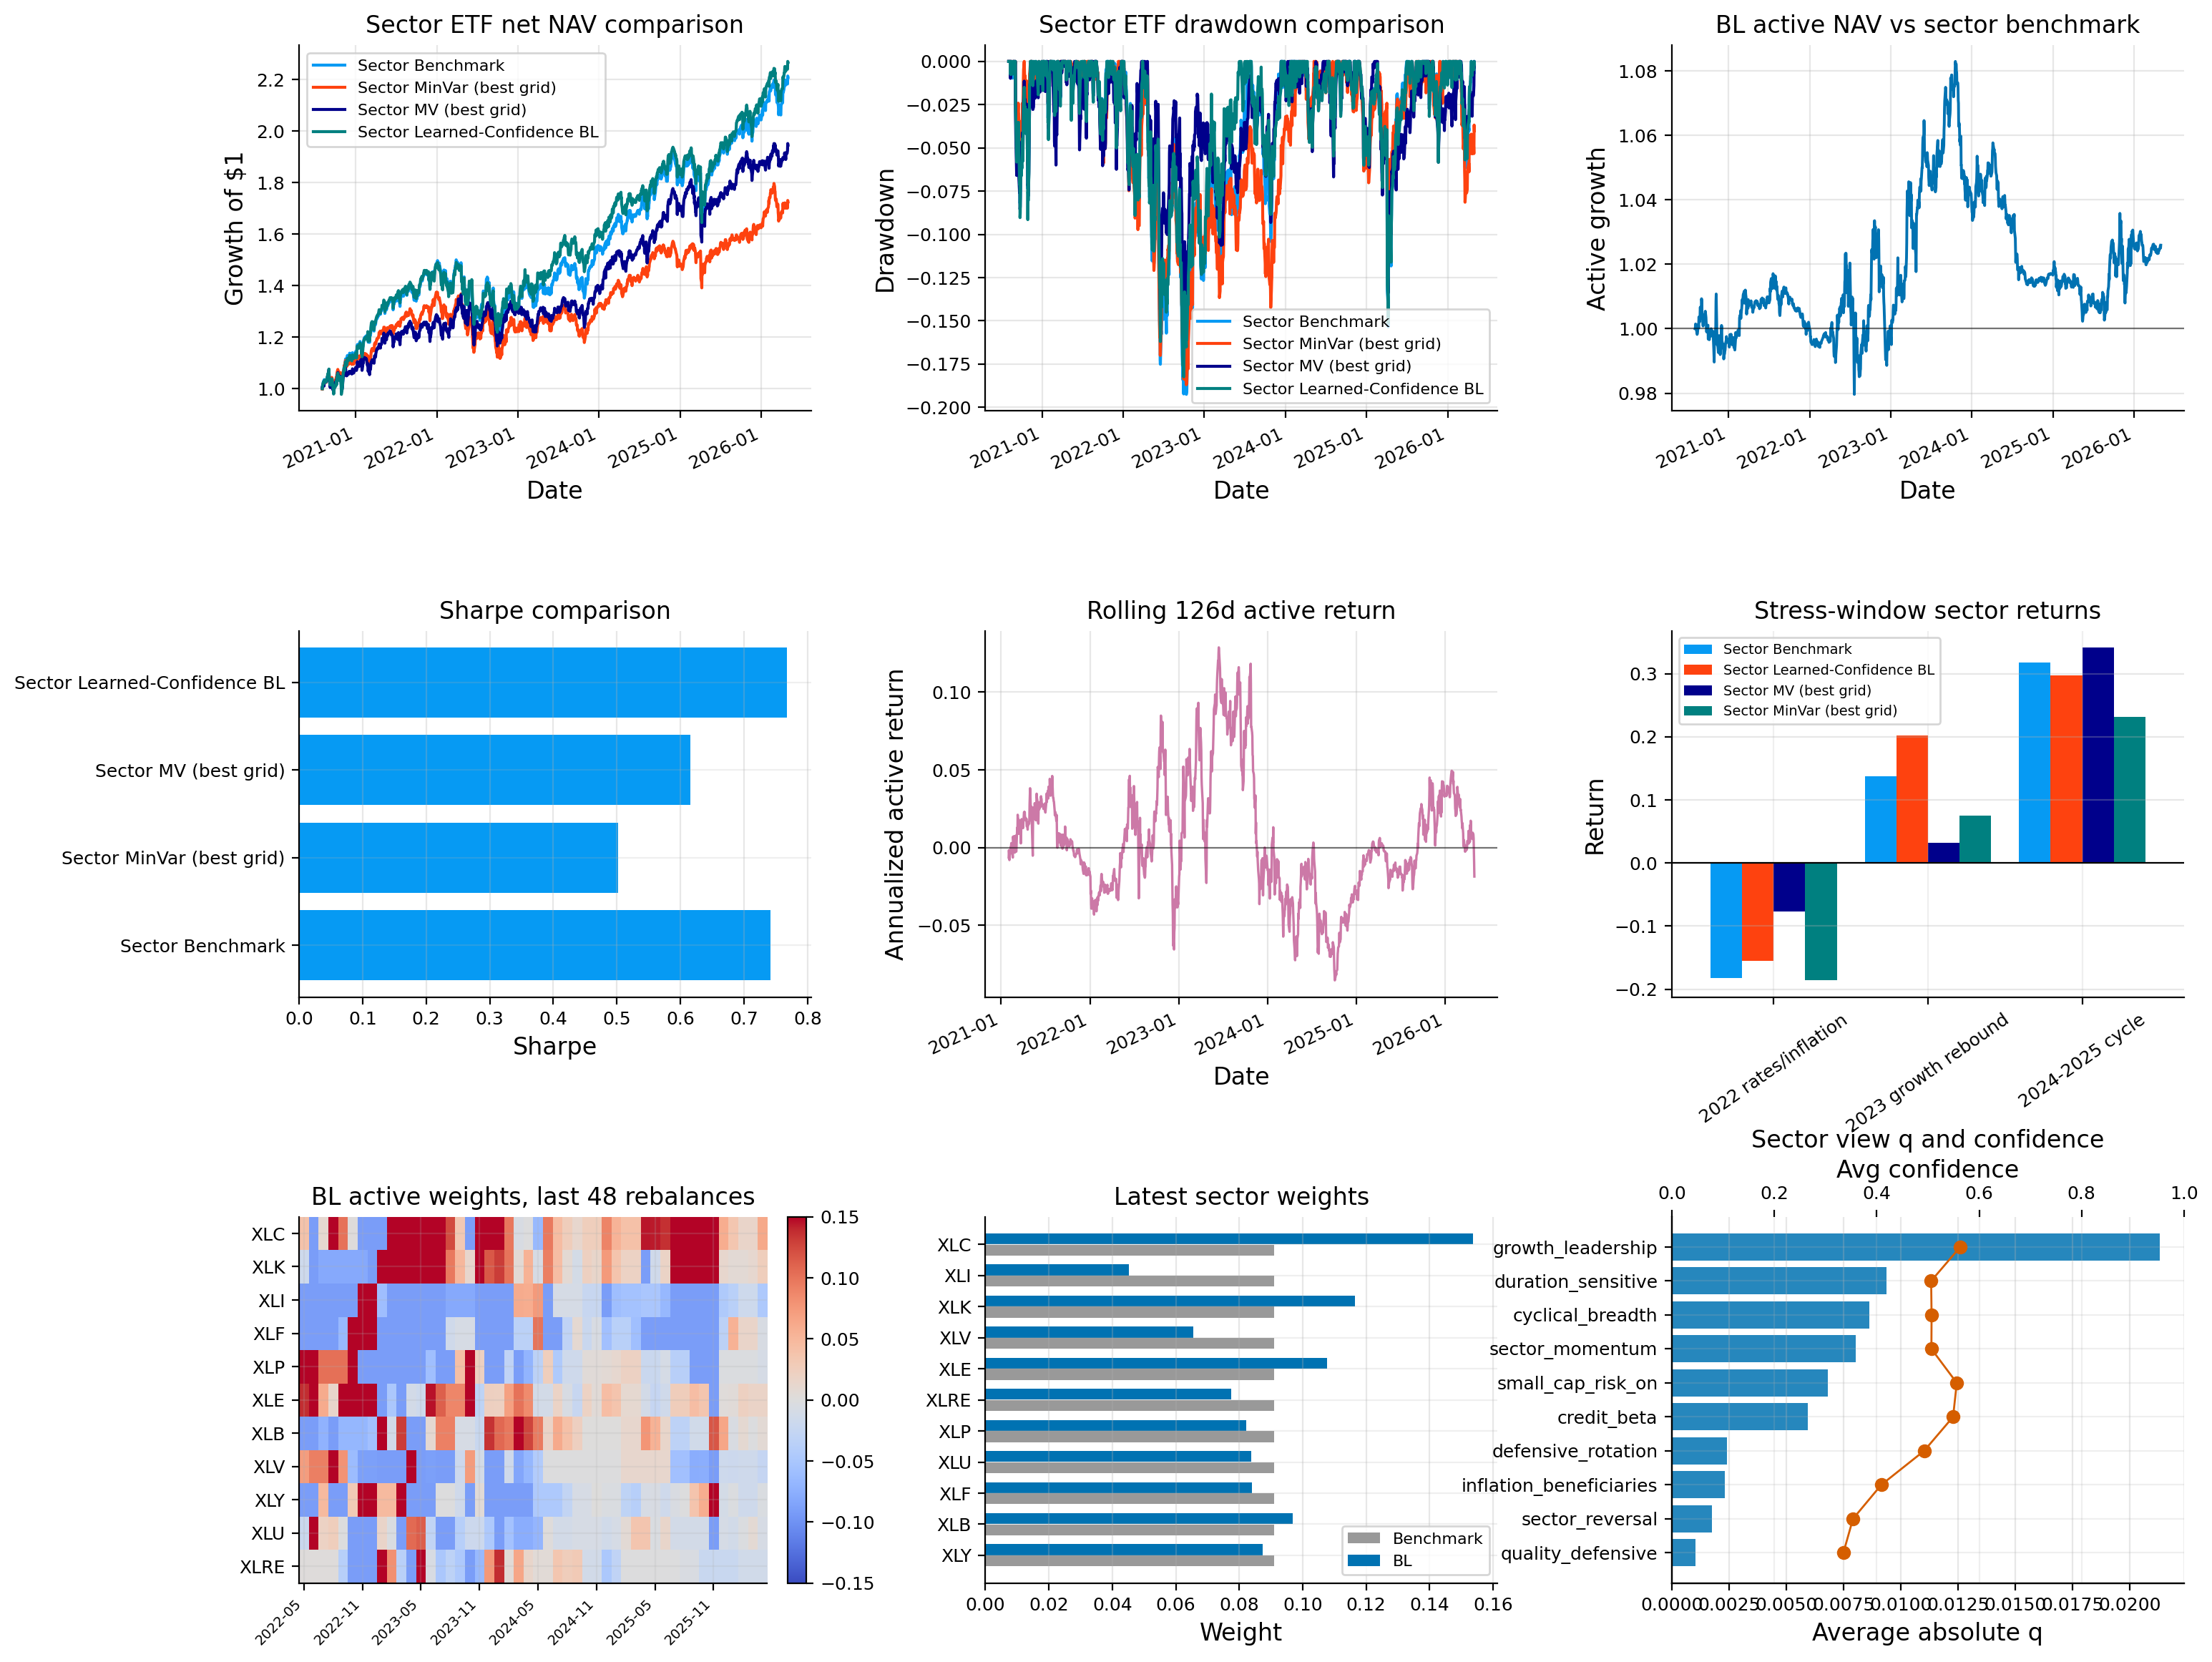

In [37]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display

from quantfinlab.portfolio import black_litterman as bl
from quantfinlab.portfolio import views as bl_views
from quantfinlab.plotting import portfolio as port_plots
from quantfinlab.backtest.portfolio import run_many_weights_backtests
from quantfinlab.portfolio.walkforward import run_walkforward_grid
from quantfinlab.portfolio import prices_to_returns, make_rebalance_dates

sector_annualization = 252.0
bl_mv_lambda = 6.0

data_path = Path("../data/ETF_data.csv")

raw = pd.read_csv(data_path)
raw["date"] = pd.to_datetime(raw["date"], errors="coerce")
raw = raw.dropna(subset=["date"]).sort_values("date").set_index("date")

close_cols = [col for col in raw.columns if col.endswith("__close")]

close_all = raw[close_cols].copy()
close_all.columns = [col.rsplit("__", 1)[0] for col in close_cols]
close_all = close_all.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
close_all = close_all.dropna(axis=1, how="all").reindex(columns=sorted(close_all.columns))

print("data file:", data_path)
print("close panel:", close_all.shape, close_all.index.min().date(), "to", close_all.index.max().date())

sector_start = "2018-07-01"

requested_sector_assets = [
    "XLK", "XLC", "XLY", "XLF", "XLI",
    "XLE", "XLB", "XLV", "XLP", "XLU", "XLRE"]

requested_signal_assets = [
    "SPY", "QQQ", "IWM",
    "TLT", "IEF", "SHY",
    "LQD", "HYG",
    "GLD", "DBC", "UUP"]

sector_assets = [ticker for ticker in requested_sector_assets if ticker in close_all.columns]
sector_signal_assets = [ticker for ticker in requested_signal_assets if ticker in close_all.columns]
if len(sector_assets) < 8:
    raise ValueError(f"not enough sector ETFs are available: {sector_assets}")

sector_coverage = bl.data_coverage_table(
    close_all,
    tradable_assets=sector_assets,
    signal_assets=sector_signal_assets,
    start=sector_start)
display(sector_coverage.round(4))

sector_close_raw = close_all.loc[pd.Timestamp(sector_start):, sector_assets].copy()
sector_close = sector_close_raw.ffill(limit=3).dropna(how="any")
sector_returns = prices_to_returns(sector_close, kind="simple").replace([np.inf, -np.inf], np.nan).dropna(how="all").fillna(0.0)
sector_close = sector_close.reindex(sector_returns.index).ffill(limit=3)

sector_signal_tickers = list(dict.fromkeys(sector_assets + sector_signal_assets))
sector_signal_close = (
    close_all.loc[sector_returns.index.min():, sector_signal_tickers]
    .ffill(limit=3)
    .reindex(sector_returns.index)
    .ffill(limit=3))
sector_signal_returns = (
    prices_to_returns(sector_signal_close, kind="simple")
    .replace([np.inf, -np.inf], np.nan)
    .reindex(sector_returns.index)
    .fillna(0.0))

sector_rebalance_dates = make_rebalance_dates(sector_returns.index, freq="ME", min_history_days=504)
print("sector assets:", sector_assets)
print("sector signal assets:", sector_signal_assets)
print("sector return panel:", sector_returns.shape, sector_returns.index.min().date(), "to", sector_returns.index.max().date())
if len(sector_rebalance_dates) < 2:
    raise ValueError("Sector backtest needs at least two rebalance dates after the 504-day history window.")
print("sector rebalance dates:", len(sector_rebalance_dates), sector_rebalance_dates[0].date(), "to", sector_rebalance_dates[-1].date())

sector_benchmark_w = pd.Series(1.0 / len(sector_assets), index=sector_assets, dtype=float)

sector_roles_raw = {
    "assets": sector_assets,
    "growth": ["XLK", "XLC", "XLY"],
    "defensive": ["XLP", "XLU", "XLV"],
    "cyclical": ["XLI", "XLF", "XLB", "XLE"],
    "inflation_beneficiaries": ["XLE", "XLB"],
    "rate_sensitive": ["XLU", "XLV", "XLRE"],
    "credit_sensitive": ["XLF", "XLY", "XLI"],
    "quality_defensive": ["XLV", "XLP"],
    "small_cap_sensitive": ["XLI", "XLF", "XLY"],
    "risky": sector_assets,
    "sleeve_map": {ticker: "Sector" for ticker in sector_assets}}
sector_roles = {
    key: ([ticker for ticker in value if ticker in sector_assets] if isinstance(value, list) else value)
    for key, value in sector_roles_raw.items()}

sector_family_caps = {
    "sector_momentum": 0.012,
    "growth_leadership": 0.030,
    "defensive_rotation": 0.006,
    "cyclical_breadth": 0.020,
    "credit_beta": 0.012,
    "inflation_beneficiaries": 0.008,
    "duration_sensitive": 0.014,
    "small_cap_risk_on": 0.010,
    "quality_defensive": 0.004,
    "sector_reversal": 0.004}

sector_view_settings = bl_views.ViewSettings(
    family_q_caps=sector_family_caps,
    family_display_names=bl_views.DEFAULT_SECTOR_DISPLAY_NAMES,
    assets=sector_assets,
    entry_z=0.50,
    q_strength_scale=1.25,
    annualization=sector_annualization,
    view_horizon_days=21)

sector_bl_settings = bl.BLSettings(
    cov_lookback=504,
    mu_lookback=252,
    risk_free_rate_annual=0.04,
    transaction_cost_bps=10.0,
    tau=0.05,
    ewma_lambda=0.97,
    max_weight=0.35,
    active_weight_limit=0.15,
    active_weight_relaxed=0.22,
    max_selected_views=5,
    redundancy_similarity=0.85,
    max_same_direction=3)
sector_rf_daily = bl.risk_free_daily(sector_bl_settings.risk_free_rate_annual, sector_bl_settings.annualization)
sector_asset_caps = pd.Series(sector_bl_settings.max_weight, index=sector_assets, dtype=float)

display(pd.DataFrame({"benchmark_weight": sector_benchmark_w}).round(4))
display(bl.view_spec_table(bl_views.SECTOR_VIEW_SPECS, sector_family_caps, bl_views.DEFAULT_SECTOR_DISPLAY_NAMES).round(4))

latest_sector_rebalance_date = sector_rebalance_dates[-1]
sector_latest_state = bl.market_state(
    returns=sector_returns,
    signal_returns=sector_signal_returns,
    date=latest_sector_rebalance_date,
    roles=sector_roles,
    settings=sector_bl_settings,
    view_settings=sector_view_settings)

sector_momentum_view = bl_views.sector_momentum(sector_latest_state, sector_roles, sector_view_settings)
growth_leadership_view = bl_views.growth_leadership(sector_latest_state, sector_roles, sector_view_settings)
defensive_rotation_view = bl_views.defensive_rotation(sector_latest_state, sector_roles, sector_view_settings)
cyclical_breadth_view = bl_views.cyclical_breadth(sector_latest_state, sector_roles, sector_view_settings)
credit_beta_view = bl_views.credit_beta(sector_latest_state, sector_roles, sector_view_settings)
inflation_beneficiaries_view = bl_views.inflation_beneficiaries(sector_latest_state, sector_roles, sector_view_settings)
duration_sensitive_view = bl_views.duration_sensitive(sector_latest_state, sector_roles, sector_view_settings)
small_cap_risk_on_view = bl_views.small_cap_risk_on(sector_latest_state, sector_roles, sector_view_settings)
quality_defensive_view = bl_views.quality_defensive(sector_latest_state, sector_roles, sector_view_settings)
sector_reversal_view = bl_views.sector_reversal(sector_latest_state, sector_roles, sector_view_settings)

latest_sector_views = bl_views.view_rows([
    sector_momentum_view,
    growth_leadership_view,
    defensive_rotation_view,
    cyclical_breadth_view,
    credit_beta_view,
    inflation_beneficiaries_view,
    duration_sensitive_view,
    small_cap_risk_on_view,
    quality_defensive_view,
    sector_reversal_view])

display(sector_latest_state.signal_table[["sleeve", "mom_3_0", "mom_6_1", "trend_200", "vol_63", "dd_252", "score"]].round(4))
display(bl.latest_view_table(latest_sector_views).round(4))

sector_fixed_universe_by_date = {
    pd.Timestamp(dt): {"tickers": list(sector_assets), "avg_dollar_volume": pd.Series(1.0, index=sector_assets)}
    for dt in sector_rebalance_dates}

sector_walkforward_grid = run_walkforward_grid(
    returns=sector_returns,
    close=sector_close,
    rebalance_dates=sector_rebalance_dates,
    universe_by_date=sector_fixed_universe_by_date,
    cov_lookback=sector_bl_settings.cov_lookback,
    mu_lookback=sector_bl_settings.mu_lookback,
    min_cov_observations=sector_bl_settings.cov_lookback - 1,
    min_mu_observations=sector_bl_settings.mu_lookback - 1,
    max_weight=sector_bl_settings.max_weight,
    min_weight=sector_bl_settings.min_weight,
    long_only=True,
    trading_cost_bps=sector_bl_settings.transaction_cost_bps,
    turnover_penalty_bps=sector_bl_settings.transaction_cost_bps,
    fallback="equal", rf_daily=sector_rf_daily,
    annualization=sector_bl_settings.annualization,
    optimizer_params={
        "MV": {"mv_lambda": bl_mv_lambda},
        "RidgeMV": {"mv_lambda": bl_mv_lambda},
        "FrontierGrid": {"grid_n": 15},
    },
)

sector_minvar_candidates = sector_walkforward_grid.results[sector_walkforward_grid.results["Optimizer"].eq("MinVar")].replace([np.inf, -np.inf], np.nan).dropna(subset=["Sharpe"])
sector_mv_candidates = sector_walkforward_grid.results[sector_walkforward_grid.results["Optimizer"].eq("MV")].replace([np.inf, -np.inf], np.nan).dropna(subset=["Sharpe"])
sector_best_minvar_name = str(sector_minvar_candidates.sort_values(["Sharpe", "Max Drawdown", "Turnover"], ascending=[False, False, True]).index[0])
sector_best_mv_name = str(sector_mv_candidates.sort_values(["Sharpe", "Max Drawdown", "Turnover"], ascending=[False, False, True]).index[0])

sector_baseline_summary = sector_walkforward_grid.results.loc[[sector_best_minvar_name, sector_best_mv_name]].copy()
sector_baseline_summary.index = ["Sector MinVar (best grid)", "Sector MV (best grid)"]
print("sector grid strategies:", len(sector_walkforward_grid.results))
print("selected sector baselines:", sector_best_minvar_name, "and", sector_best_mv_name)
display(sector_baseline_summary.round(4))

sector_view_functions = (
    bl_views.sector_momentum,
    bl_views.growth_leadership,
    bl_views.defensive_rotation,
    bl_views.cyclical_breadth,
    bl_views.credit_beta,
    bl_views.inflation_beneficiaries,
    bl_views.duration_sensitive,
    bl_views.small_cap_risk_on,
    bl_views.quality_defensive,
    bl_views.sector_reversal)

sector_bl_run = bl.learned_confidence_bl(
    returns=sector_returns,
    signal_returns=sector_signal_returns,
    rebalance_dates=sector_rebalance_dates,
    benchmark_weights=sector_benchmark_w,
    roles=sector_roles,
    view_functions=sector_view_functions,
    view_settings=sector_view_settings,
    settings=sector_bl_settings,
    constraints={"asset_caps": sector_asset_caps})

print("sector BL weights:", sector_bl_run.weights.shape)
print("candidate views:", len(sector_bl_run.candidate_view_log), "selected views:", len(sector_bl_run.selected_view_log))
display(sector_bl_run.weights.tail().round(4))

sector_benchmark_weights = pd.DataFrame([
    sector_benchmark_w.rename(pd.Timestamp(dt))
    for dt in sector_rebalance_dates[:-1]])

sector_weights_by_strategy = {
    "Sector Benchmark": sector_benchmark_weights,
    "Sector MinVar (best grid)": sector_walkforward_grid.weights[sector_best_minvar_name],
    "Sector MV (best grid)": sector_walkforward_grid.weights[sector_best_mv_name],
    "Sector Learned-Confidence BL": sector_bl_run.weights}

sector_backtests = run_many_weights_backtests(
    sector_weights_by_strategy,
    returns=sector_returns,
    cost_bps=sector_bl_settings.transaction_cost_bps,
    w_min=sector_bl_settings.min_weight,
    w_max=sector_bl_settings.max_weight,
    long_only=True, normalize=True, weight_timing="next_close")

sector_strategy_names = [
    "Sector Benchmark",
    "Sector MinVar (best grid)",
    "Sector MV (best grid)",
    "Sector Learned-Confidence BL"]
sector_nav = pd.concat({name: sector_backtests[name].net_values for name in sector_strategy_names}, axis=1)
sector_returns_by_strategy = pd.concat({name: sector_backtests[name].net_returns for name in sector_strategy_names}, axis=1)
print("sector backtests use the same run_many_weights_backtests engine:", list(sector_backtests))

sector_model_comparison = bl.model_comparison_table(
    sector_backtests,
    benchmark_name="Sector Benchmark",
    rf_daily=sector_rf_daily,
    annualization=sector_bl_settings.annualization)

display(sector_model_comparison.round(4))

sector_active_summary = bl.active_summary_table(
    sector_backtests["Sector Learned-Confidence BL"],
    sector_backtests["Sector Benchmark"],
    strategy_name="Sector Learned-Confidence BL",
    benchmark_name="Sector Benchmark",
    annualization=sector_bl_settings.annualization)

display(sector_active_summary.round(4))

sector_view_reliability = bl.view_reliability_table(sector_bl_run)
display(sector_view_reliability.round(4))

sector_selection_summary = bl.selection_summary_table(sector_bl_run.selection_log)
display(sector_selection_summary.round(4))

sector_latest_weight_table = bl.latest_weight_table(sector_bl_run.weights, sector_benchmark_w)
display(sector_latest_weight_table.round(4))

sector_stress_summary = bl.stress_summary_table(
    sector_backtests,
    benchmark_name="Sector Benchmark")

display(sector_stress_summary.round(4))

fig, axes = plt.subplots(3, 3, figsize=(17, 12.5))
axes = axes.ravel()

port_plots.plot_strategy_nav(
    sector_nav,
    sector_strategy_names,
    ax=axes[0],
    title="Sector ETF net NAV comparison",
    labels=sector_strategy_names)

port_plots.plot_strategy_drawdowns(
    sector_nav,
    sector_strategy_names,
    ax=axes[1],
    title="Sector ETF drawdown comparison",
    labels=sector_strategy_names)

port_plots.plot_active_nav(
    sector_returns_by_strategy,
    "Sector Learned-Confidence BL",
    "Sector Benchmark",
    ax=axes[2],
    title="BL active NAV vs sector benchmark")

port_plots.plot_metric_bar(
    sector_model_comparison,
    sector_strategy_names,
    metric="Sharpe",
    ax=axes[3],
    title="Sharpe comparison",
    labels=sector_strategy_names)

port_plots.plot_rolling_active_metrics(
    sector_returns_by_strategy,
    "Sector Learned-Confidence BL",
    "Sector Benchmark",
    window=126,
    metric="active_return",
    annualization=sector_bl_settings.annualization,
    ax=axes[4],
    title="Rolling 126d active return")

port_plots.plot_stress_summary(
    sector_stress_summary,
    value_col="return",
    ax=axes[5],
    title="Stress-window sector returns")

port_plots.plot_active_weights_heatmap(
    sector_bl_run.weights,
    sector_benchmark_w,
    last_n=48,
    ax=axes[6],
    title="BL active weights, last 48 rebalances")

port_plots.plot_latest_weights(
    sector_bl_run.weights,
    sector_benchmark_w,
    ax=axes[7],
    title="Latest sector weights")

port_plots.plot_view_q_and_confidence(
    sector_bl_run.selected_view_log,
    sector_bl_run.confidence_log,
    ax=axes[8],
    title="Sector view q and confidence")

port_plots.apply_portfolio_subplot_layout(fig, axes, hspace=0.60, wspace=0.34, bottom=0.08, top=0.94)
plt.show()
